# Statistics for Michel electron candidate (PDHD MC production New202508)

### Created by Shu, 202508---

<br />
<br />
<br />
<br />
<br />
<br />

## WVF Coincidence Explore:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


coinNum = [] # wvf coin num--
coinTrueE = [] # energy of candidates---
coinPDG = []

file_list = [
    "./pdsStat_2025New/print_wvfCoin_count20250828.txt",
    "./pdsStat_2025New/print_wvfCoin_count20250916.txt",
    "./pdsStat_2025New/print_wvfCoin_count20250917.txt"
]
for fname in file_list:
    try:
        with open(fname, "r") as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(":")
                if len(parts) >= 2:
                    try:
                        number = int(parts[1].strip())
                        coinNum.append(number)
                    except ValueError:
                        print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")
                # If the format isn't "<filepath>: <number>", silently skip
    except FileNotFoundError:
        print(f"File not found: {fname}")


coinTrueE_file_paths = [
    './pdsStat_2025New/print_trueE20250828.txt',
    './pdsStat_2025New/print_trueE20250916.txt',
    './pdsStat_2025New/print_trueE20250917.txt'
]
for file_path in coinTrueE_file_paths:
    with open(file_path, 'r') as filehandle:
        for line in filehandle:
            value = line.strip()
            if value:  # Skip empty lines safely
                coinTrueE.append(float(value))


coinPDG_file_paths = [
    './pdsStat_2025New/print_truePDG20250828.txt',
    './pdsStat_2025New/print_truePDG20250916.txt',
    './pdsStat_2025New/print_truePDG20250917.txt'
]
for file_path in coinPDG_file_paths:
    with open(file_path, 'r') as filehandle:
        for line in filehandle:
            value = line.strip()
            if value:  # Skip empty lines safely
                coinPDG.append(float(value))




print("Track candidates (TPC cut)  : 8189 (2706 + 2674 + 2809)")
print("Track candidates with NO wvf: 1219 (406 + 376 + 437)")
print("Number of track candidates  :", len(coinNum))

#coinNum.extend([0] * (88+95))



print("\nLength of track coinTrueE: ", len(coinTrueE))
print("Length of track coinPDG  : ", len(coinPDG))


Track candidates (TPC cut)  : 8189 (2706 + 2674 + 2809)
Track candidates with NO wvf: 1219 (406 + 376 + 437)
Number of track candidates  : 6992

Length of track coinTrueE:  6992
Length of track coinPDG  :  6992


Purity of coinNum:  6261 / 6992 (89.55%)
Michel e:  1106 / 6261 (17.66%)
Michel p:  5155 / 6261 (82.34%)

Candidates with #opWvf>=4:  5997 / 6992 (85.77%)
Purity:  5347 / 5997 (89.16%)


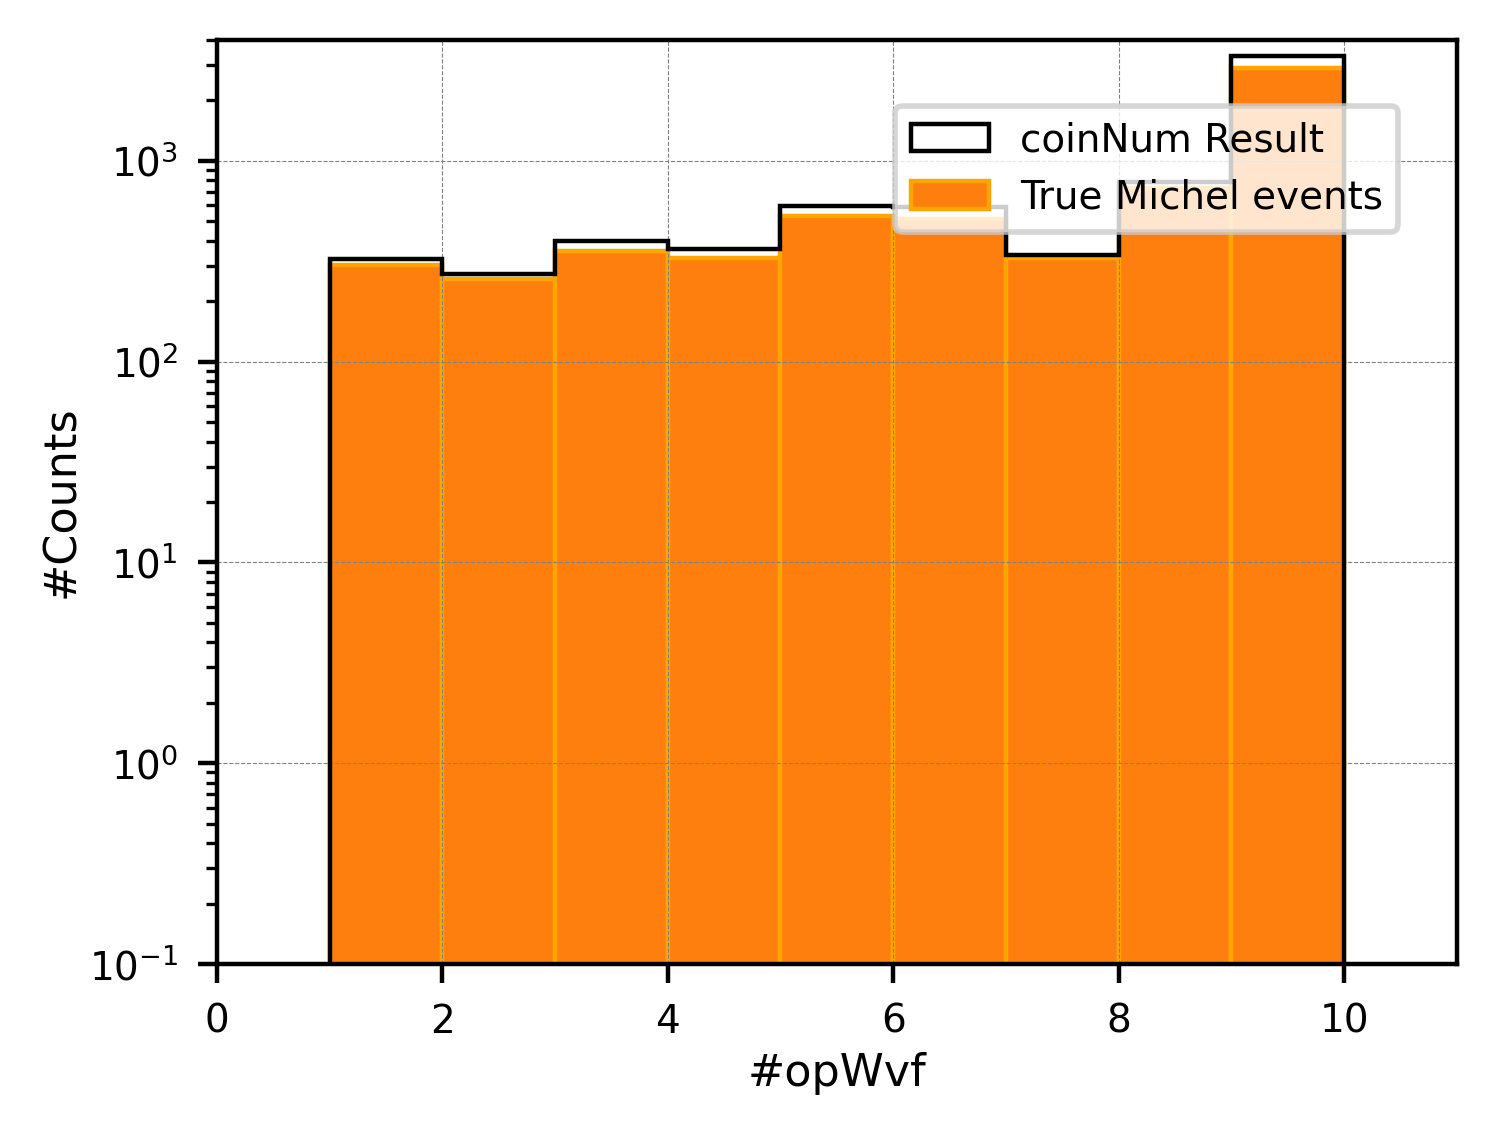

<Figure size 1600x1200 with 0 Axes>

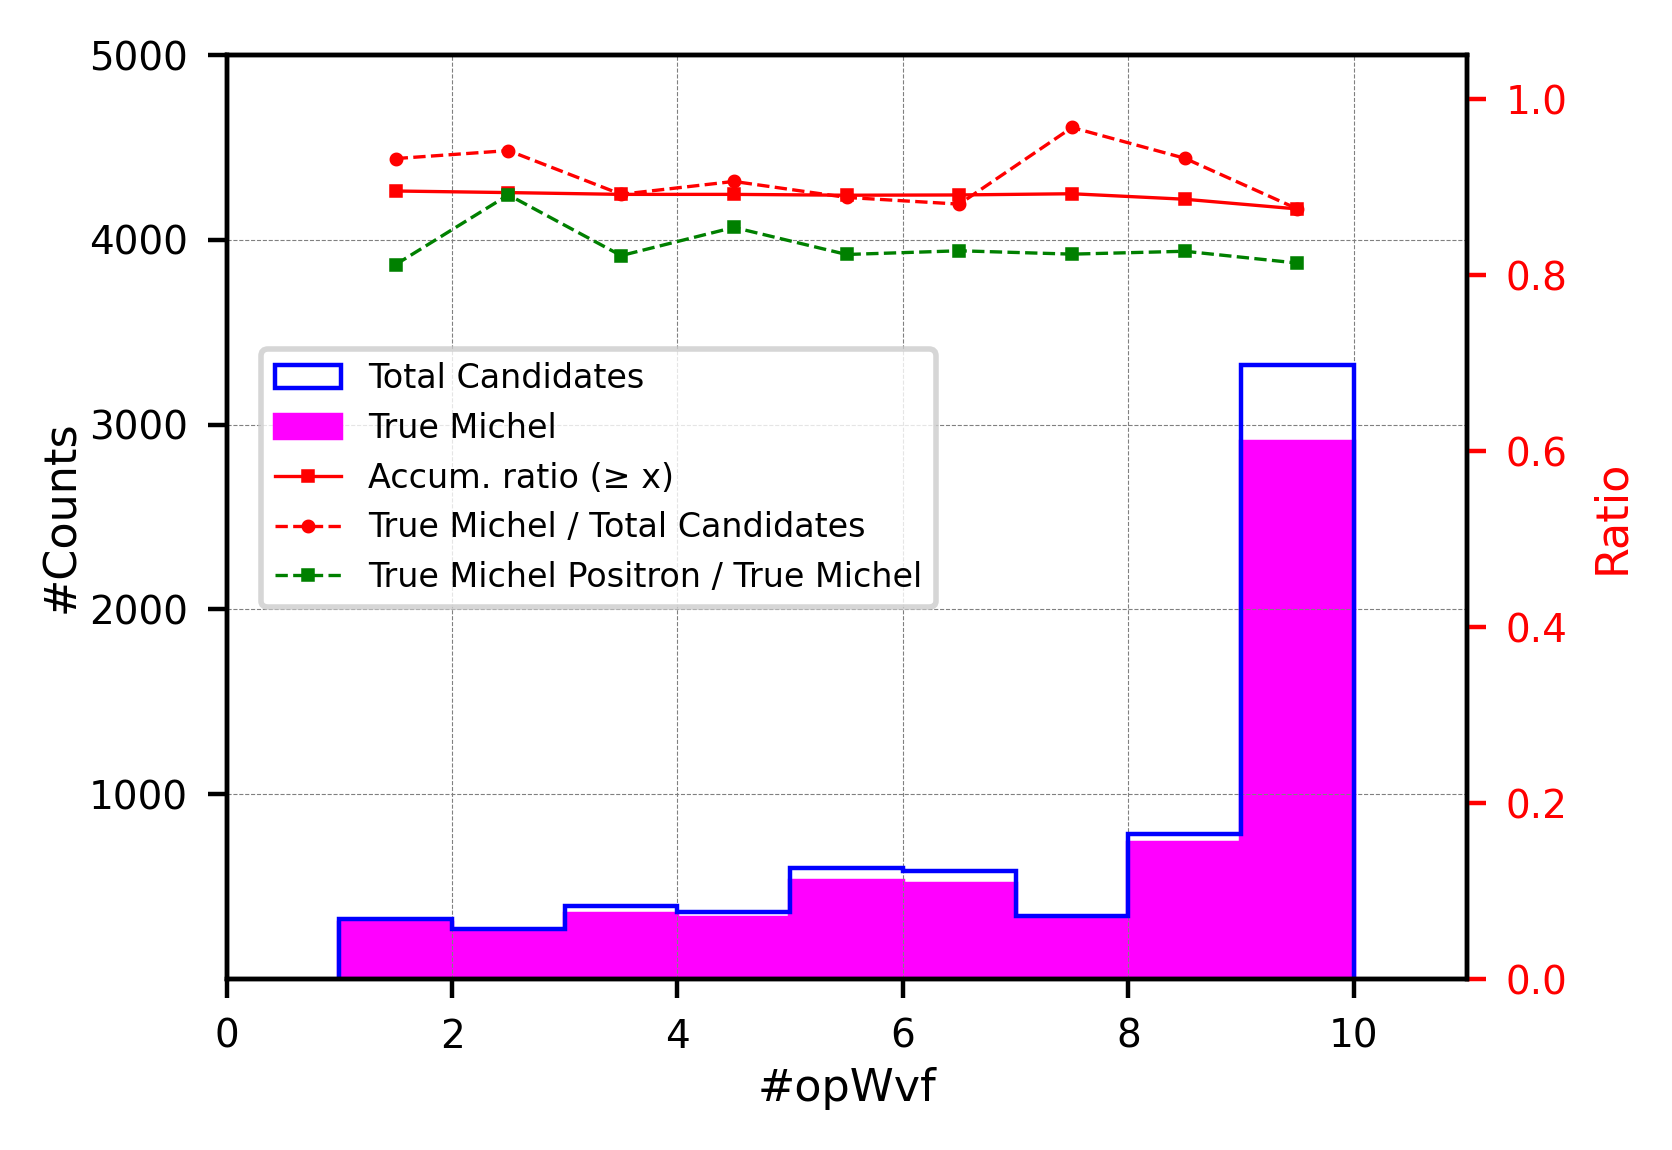

In [2]:

#Extract coinNum with trueE:===========================
coinNum_trueE = []
coinNum_trueE_e = [] #Michel electron
coinNum_trueE_p = [] #Michel positron
for i in range(0, len(coinTrueE)):
    count = coinNum[i]
    e = coinTrueE[i]
    pdg = coinPDG[i]

    if e > 0:
        coinNum_trueE.append(count)
        if pdg == 11:
            coinNum_trueE_e.append(count)
        if pdg == -11:
            coinNum_trueE_p.append(count)

print("Purity of coinNum: ", len(coinNum_trueE), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_trueE)/len(coinNum)*100))
print("Michel e: ", len(coinNum_trueE_e), "/", len(coinNum_trueE), "({:.2f}%)".format(len(coinNum_trueE_e)/len(coinNum_trueE)*100))
print("Michel p: ", len(coinNum_trueE_p), "/", len(coinNum_trueE), "({:.2f}%)".format(len(coinNum_trueE_p)/len(coinNum_trueE)*100))





#Apply preliminary cut #opWvf >=4:=====================
coinNum_cut5 = []
coinNum_trueE_cut5 = []
for i in range(0, len(coinNum)):
    coin = coinNum[i]
    trueE = coinTrueE[i]

    if coin >=4:
        coinNum_cut5.append(coin)
    
        if trueE > 0:
            coinNum_trueE_cut5.append(trueE)

print("\nCandidates with #opWvf>=4: ", len(coinNum_cut5), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_cut5)/len(coinNum)*100))
print("Purity: ", len(coinNum_trueE_cut5), "/", len(coinNum_cut5), "({:.2f}%)".format(len(coinNum_trueE_cut5)/len(coinNum_cut5)*100))




# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

#plt.plot([5, 5], [0, 1200], color="black", linewidth=1.5, linestyle='--')

plt.hist(coinNum, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label='coinNum Result')
plt.hist(coinNum_trueE, bins=bins, range=(range_min, range_max), edgecolor='orange', 
         histtype='bar', linewidth=0.8, label="True Michel events")



plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.xlim(0, 11)
#plt.ylim(0, 50)
plt.xlabel('#opWvf', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 4000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 








#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 1
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(coinNum, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(coinNum_trueE, bins=bins, range=(range_min, range_max))
hist_trueP, _ = np.histogram(coinNum_trueE_p, bins=bins, range=(range_min, range_max))#True positron

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', color='magenta', histtype='bar', 
         linewidth=0.8, label="True Michel")
#ax1.hist(bin_centers, bins=bins, weights=hist_trueP, edgecolor='green', color='green', histtype='bar', 
#         linewidth=0.8, label="True Michel Positron")


#ax1.plot([4, 4], [0, 1400], color="blue", linewidth=0.8, linestyle='-')


ax1.set_xlim(0, 11)
ax1.set_xlabel('#opWvf', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.set_ylim(0.1, 5000)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero

ratio2 = np.divide(hist_trueP, hist_true, out=np.zeros_like(hist_trueP, dtype=float), where=hist_total!=0)  # Avoid division by zero

# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')


ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', 
         linewidth=0.6, label="True Michel / Total Candidates")

ax2.plot(bin_centers, ratio2, color='green', marker='s', markersize=1.5, linestyle='--', 
         linewidth=0.6, label="True Michel Positron / True Michel")



ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.set_ylim(0.0, 1.05)

ax2.tick_params(axis='y', labelsize=7, colors='red')



# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.3, 0.7),
           fontsize=9, ncol=1, prop={'size': 6})



plt.show()



<br />
<br />
<br />
<br />
<br />
<br />

## Process WVF:
### After TPC cuts & (#opWvf >= 4)

In [3]:
from dataclasses import dataclass
from typing import Optional
import matplotlib.pyplot as plt
import numpy as np
import re
from mpl_toolkits.mplot3d import Axes3D



# ------------------- Dataclass -------------------
@dataclass
class PdsEvent:
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    energy: Optional[float] = None
    lifetime: Optional[float] = None
    pdg: Optional[int] = None
    eventID: Optional[int] = None   # NEW
    trackID: Optional[int] = None   # NEW
    date: Optional[int] = None      # NEW
    mu_leftTurn: Optional[int] = None
    mu_rightTurn: Optional[int] = None
    mu_leftHeight: Optional[float] = None
    mu_rightHeight: Optional[float] = None
    mi_leftTurn: Optional[int] = None
    mi_rightTurn: Optional[int] = None
    mi_leftHeight: Optional[float] = None
    mi_rightHeight: Optional[float] = None


# ------------------- Helpers -------------------
def parse_event_track(path_str: str):
    """Extract eventID and trackID from a file path string."""
    m = re.search(r"event(\d+)_trackID(\d+)", path_str)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None


def read_total_files(files, dates, is_muon=True):
    """
    Read muon_total_xxx.txt or michel_total_xxx.txt files.
    Each line: path: t, I, leftTurn, leftHeight, rightTurn, rightHeight
    """
    records = []
    for fname, date in zip(files, dates):
        try:
            with open(fname, "r") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split(":")
                    if len(parts) < 2:
                        continue

                    path_part = parts[0].strip()
                    values = [v.strip() for v in parts[1].split(",")]
                    if len(values) < 6:
                        print(f"[WARN] Malformed line in {fname}: {line}")
                        continue

                    # parse numbers
                    try:
                        time_val = int(values[0])
                        inten_val = float(values[1])
                        left_turn = int(values[2])
                        left_h = float(values[3])
                        right_turn = int(values[4])
                        right_h = float(values[5])
                    except ValueError:
                        print(f"[WARN] Could not parse numbers in {line}")
                        continue

                    # event/track/date
                    evID, trID = parse_event_track(path_part)
                    rec = {
                        "eventID": evID,
                        "trackID": trID,
                        "date": int(date)
                    }
                    if is_muon:
                        rec.update({
                            "muon_time": time_val,
                            "muon_intensity": inten_val,
                            "mu_leftTurn": left_turn,
                            "mu_leftHeight": left_h,
                            "mu_rightTurn": right_turn,
                            "mu_rightHeight": right_h
                        })
                    else:
                        rec.update({
                            "michel_time": time_val,
                            "michel_intensity": inten_val,
                            "mi_leftTurn": left_turn,
                            "mi_leftHeight": left_h,
                            "mi_rightTurn": right_turn,
                            "mi_rightHeight": right_h
                        })

                    records.append(rec)
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return records



def read_plain_files(files, cast_type=float):
    """Read one or more plain text files with one number per line and return concatenated values."""
    values = []
    for fname in files:
        try:
            with open(fname, "r") as file:
                for line in file:
                    value = line.strip()
                    if value:
                        try:
                            values.append(cast_type(value))
                        except ValueError:
                            print(f"Could not convert {value} in {fname}")
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return values

# ------------------- Load data -------------------
dates = ["20250828", "20250916", "20250917"]

muon_files   = [f"./pdsStat_2025New/muon_total_{d}.txt" for d in dates]
michel_files = [f"./pdsStat_2025New/michel_total_{d}.txt" for d in dates]

muon_records   = read_total_files(muon_files, dates, is_muon=True)
michel_records = read_total_files(michel_files, dates, is_muon=False)

# pos, energy, lifetime, pdg are still separate files
posX     = read_plain_files([f"./pdsStat_2025New/posX_extract_{d}.txt" for d in dates])
posY     = read_plain_files([f"./pdsStat_2025New/posY_extract_{d}.txt" for d in dates])
posZ     = read_plain_files([f"./pdsStat_2025New/posZ_extract_{d}.txt" for d in dates])
energy   = read_plain_files([f"./pdsStat_2025New/energy_extract_{d}.txt" for d in dates])
lifetime = read_plain_files([f"./pdsStat_2025New/lifetime_extract_{d}.txt" for d in dates])
pdg      = read_plain_files([f"./pdsStat_2025New/pdg_extract_{d}.txt" for d in dates], cast_type=int)


# ------------------- Build dataset -------------------
events_veryInitial = []
n_events = min(len(muon_records), len(michel_records),
               len(posX), len(posY), len(posZ),
               len(energy), len(lifetime), len(pdg))

for i in range(n_events):
    rec_mu = muon_records[i]
    rec_mi = michel_records[i]

    ev = PdsEvent(
        eventID=rec_mu.get("eventID", rec_mi.get("eventID")),
        trackID=rec_mu.get("trackID", rec_mi.get("trackID")),
        date=rec_mu.get("date", rec_mi.get("date")),

        muon_time=rec_mu.get("muon_time"),
        muon_intensity=rec_mu.get("muon_intensity"),
        mu_leftTurn=rec_mu.get("mu_leftTurn"),
        mu_leftHeight=rec_mu.get("mu_leftHeight"),
        mu_rightTurn=rec_mu.get("mu_rightTurn"),
        mu_rightHeight=rec_mu.get("mu_rightHeight"),

        michel_time=rec_mi.get("michel_time"),
        michel_intensity=rec_mi.get("michel_intensity"),
        mi_leftTurn=rec_mi.get("mi_leftTurn"),
        mi_leftHeight=rec_mi.get("mi_leftHeight"),
        mi_rightTurn=rec_mi.get("mi_rightTurn"),
        mi_rightHeight=rec_mi.get("mi_rightHeight"),

        posX=posX[i], posY=posY[i], posZ=posZ[i],
        energy=energy[i], lifetime=lifetime[i], pdg=pdg[i]
    )
    events_veryInitial.append(ev)

print("\nVery initial dataset:", len(events_veryInitial))
print("Example:", events_veryInitial[0])






#Apply cuts on peak intensities-----------------------------
events_reco_initial = []
events_true_initial = []

for ev in events_veryInitial:
    muIntensity = ev.muon_intensity
    miIntensity = ev.michel_intensity
    e = ev.energy

    if muIntensity > 0.9  and miIntensity > 0.9:
        events_reco_initial.append(ev)

        if e > 0:
            events_true_initial.append(ev)

print("\nDataset after initial intensity-cut----------------------")
print("Michel initial dataset   : ", len(events_reco_initial))
print("Michel purity (true/reco): ", len(events_true_initial), "/ ", len(events_reco_initial), 
      "({:.2f}%)".format(len(events_true_initial)/len(events_reco_initial)*100)) 








Very initial dataset: 5997
Example: PdsEvent(muon_time=127, michel_time=311, muon_intensity=27.0635, michel_intensity=4.77318, posX=153.063, posY=267.21, posZ=136.833, energy=35.7537, lifetime=2.96745, pdg=11, eventID=10001, trackID=11, date=20250828, mu_leftTurn=99, mu_rightTurn=156, mu_leftHeight=33.286, mu_rightHeight=27.0635, mi_leftTurn=292, mi_rightTurn=325, mi_leftHeight=4.83821, mi_rightHeight=4.77318)

Dataset after initial intensity-cut----------------------
Michel initial dataset   :  3964
Michel purity (true/reco):  3478 /  3964 (87.74%)


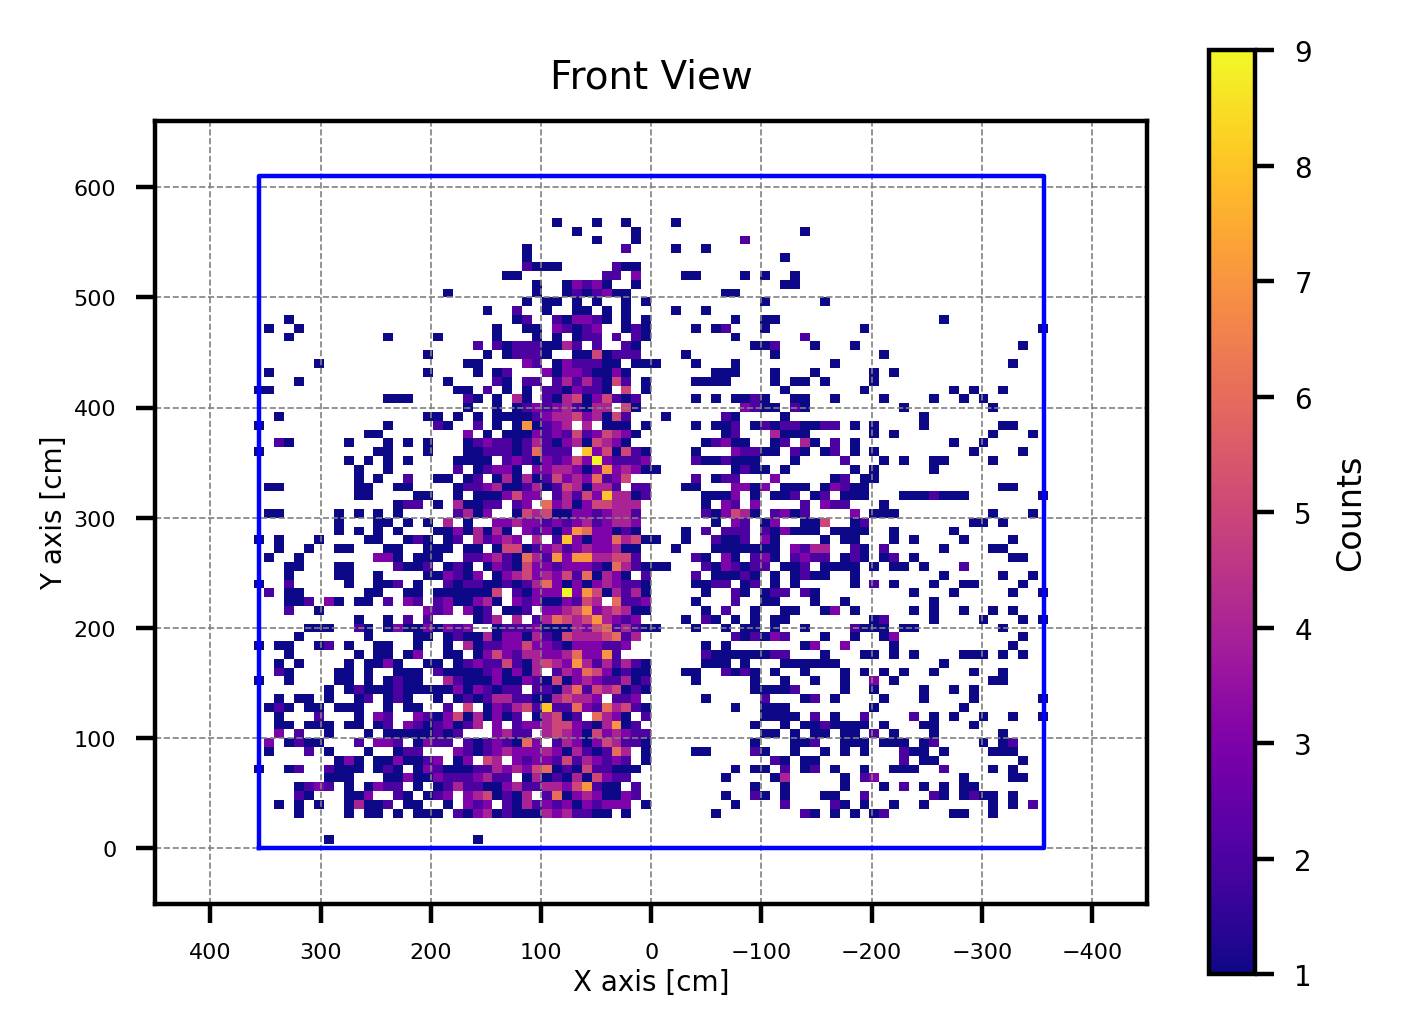

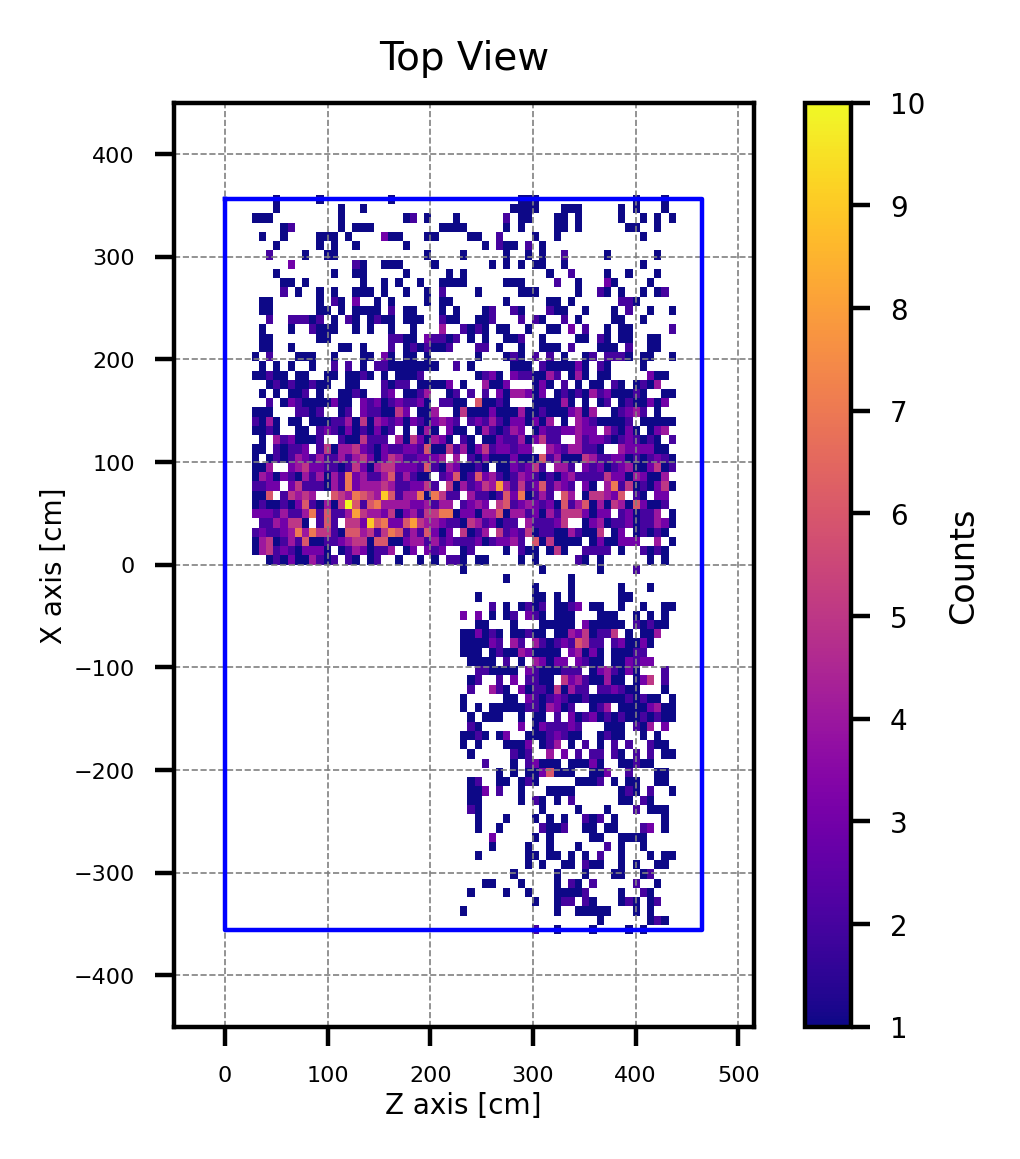


Decay points distribution (TPC & #opWvf cuts): 
# of X < 0 :  878 (22.15%)
# of X >= 0:  3086 (77.85%)

Michel purity:  3478 /  3964 (87.74%)

Bin Center | Final / Initial Ratio
-------------------------------
   -355.0 | 0.000
   -345.0 | 0.750
   -335.0 | 0.833
   -325.0 | 0.611
   -315.0 | 0.667
   -305.0 | 0.833
   -295.0 | 0.933
   -285.0 | 0.923
   -275.0 | 0.889
   -265.0 | 0.727
   -255.0 | 0.895
   -245.0 | 0.714
   -235.0 | 1.000
   -225.0 | 0.882
   -215.0 | 0.895
   -205.0 | 0.903
   -195.0 | 0.833
   -185.0 | 0.906
   -175.0 | 0.875
   -165.0 | 0.935
   -155.0 | 0.921
   -145.0 | 0.902
   -135.0 | 0.949
   -125.0 | 0.918
   -115.0 | 0.766
   -105.0 | 0.851
    -95.0 | 0.909
    -85.0 | 0.833
    -75.0 | 0.873
    -65.0 | 0.791
    -55.0 | 0.800
    -45.0 | 0.667
    -35.0 | 0.929
    -25.0 | 1.000
    -15.0 | 1.000
     -5.0 | 0.800
      5.0 | 0.891
     15.0 | 0.939
     25.0 | 0.936
     35.0 | 0.934
     45.0 | 0.879
     55.0 | 0.853
     65.0 | 0.873
     75.0 | 0.9

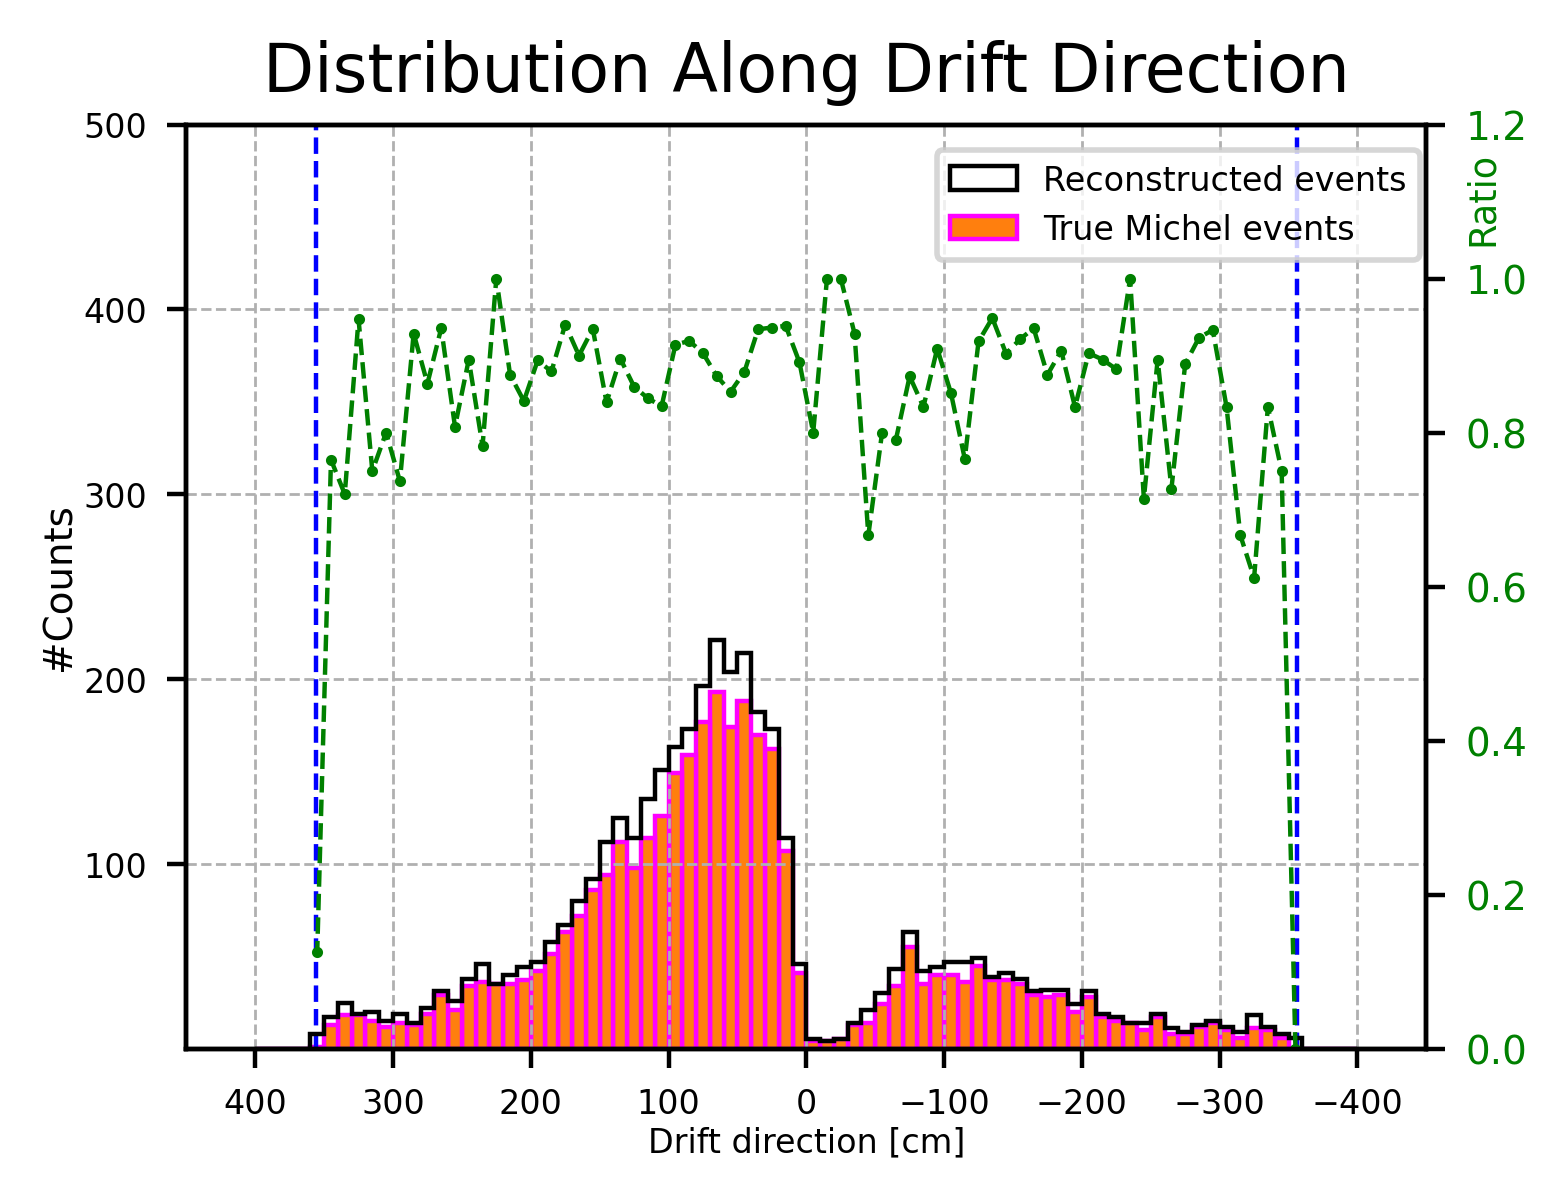

In [4]:
posX = [ev.posX for ev in events_reco_initial]
posY = [ev.posY for ev in events_reco_initial]
posZ = [ev.posZ for ev in events_reco_initial]

posX_true = [ev.posX for ev in events_true_initial]




#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posX, posY, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posZ, posX, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()








#Decay points distribution:==================================================================
print("\nDecay points distribution (TPC & #opWvf cuts): ")

posX = np.array(posX)
neg_X = np.sum(posX < 0)
pos_X = np.sum(posX >= 0)
print("# of X < 0 : ", neg_X, "({:.2f}%)".format(neg_X/len(posX)*100))
print("# of X >= 0: ", pos_X, "({:.2f}%)".format(pos_X/len(posX)*100))

print("\nMichel purity: ", len(events_true_initial), "/ ", len(events_reco_initial), 
      "({:.2f}%)".format(len(events_true_initial)/len(events_reco_initial)*100))         



# Plotting the histogram (X distribution)---------------
fig, ax1 = plt.subplots(figsize=(4, 3), dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- Histogram counts ---
n_initial, _ = np.histogram(posX, bins=bins)
n_final, _ = np.histogram(posX_true, bins=bins)

# --- Ratio Calculation (only for [-360, 360]) ---
ratio = []
ratio_centers = []

print("\nBin Center | Final / Initial Ratio")
print("-------------------------------")
for center, ni, nf in zip(bin_centers, n_initial, n_final):
    if -360 <= center <= 360:
        r = nf / ni if ni > 0 else np.nan
        ratio.append(r)
        ratio_centers.append(center)
        if ni > 0:
            print(f"{center:9.1f} | {r:.3f}")
        else:
            print(f"{center:9.1f} |   NaN")


# Filter out NaN values for min/max calculation
valid_ratios = [r for r in ratio if not np.isnan(r)]

if valid_ratios:
    print("\nMaximum ratio: {:.3f}".format(np.max(valid_ratios)))
    print("Minimum ratio: {:.3f}".format(np.min(valid_ratios)))
else:
    print("\nNo valid ratios to compute min/max.")

#APA planes---
plt.plot([-356, -356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')

# Plot histograms
ax1.hist(bins[:-1], bins=bins, weights=n_initial, edgecolor='black',
         histtype='step', linewidth=0.8, label='Reconstructed events')
ax1.hist(bins[:-1], bins=bins, weights=n_final, edgecolor='magenta',
         histtype='bar', linewidth=0.8, label='True Michel events')

ax1.set_ylabel('Counts')
ax1.grid(True, linestyle='--', linewidth=0.5)
ax1.legend(loc='upper center', bbox_to_anchor=(0.8, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})
ax1.set_xlim(-450, 450)
ax1.set_ylim(0.1, 500)
ax1.set_xlabel('Drift direction [cm]', labelpad=1, fontsize=6)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=7)
ax1.invert_xaxis()
#ax1.set_yscale('log')
ax1.tick_params(labelsize=6)

# Secondary y-axis for ratio
ax2 = ax1.twinx()

ax2.plot(ratio_centers, ratio, 'o--', color='green', markersize=1, linewidth=0.8, label='Final / Initial Ratio')

ax2.set_ylabel('Ratio', labelpad=1, fontsize=6.6, color='green', rotation=90)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_label_coords(1.03, 0.92)  # (x, y) in axis coordinates

ax2.tick_params(labelsize=7, axis='y', labelcolor='green')
ax2.set_ylim(0, np.nanmax(ratio) * 1.2)

# Final layout
#plt.tight_layout()

plt.title('Distribution Along Drift Direction', fontsize=12)

plt.show()



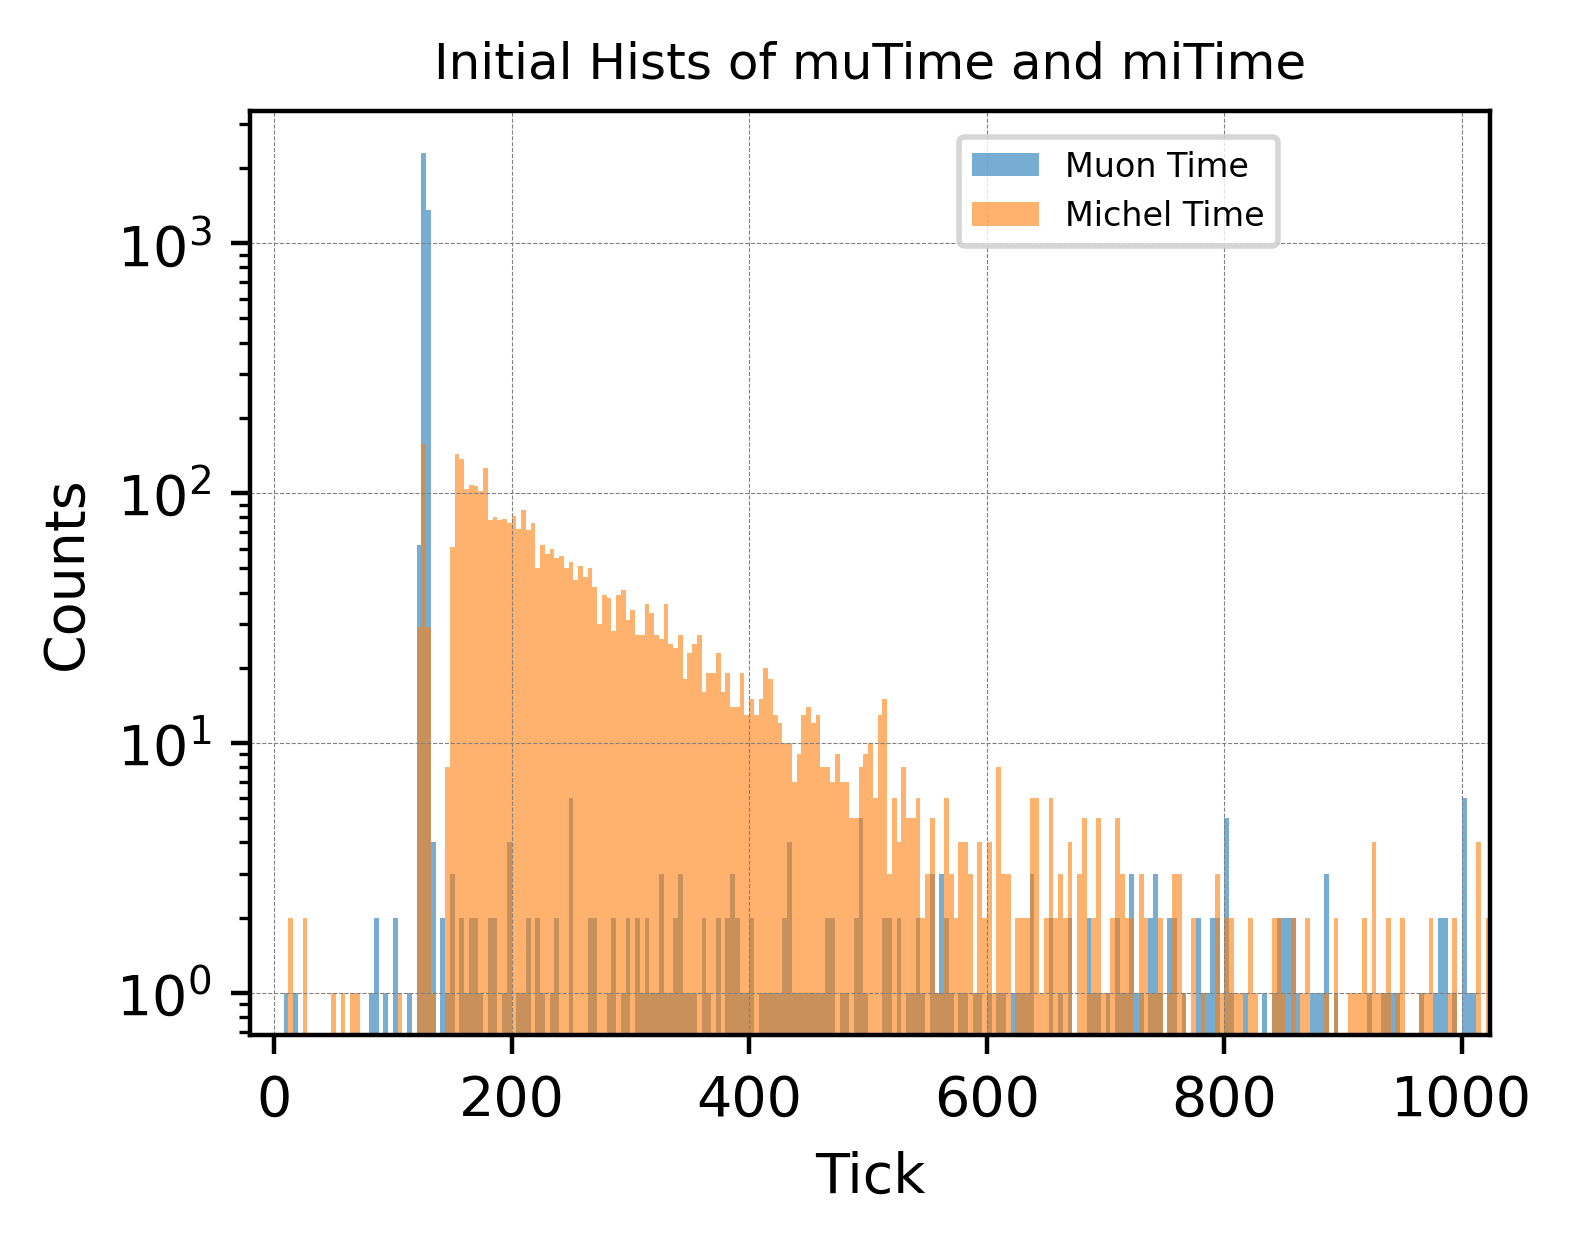

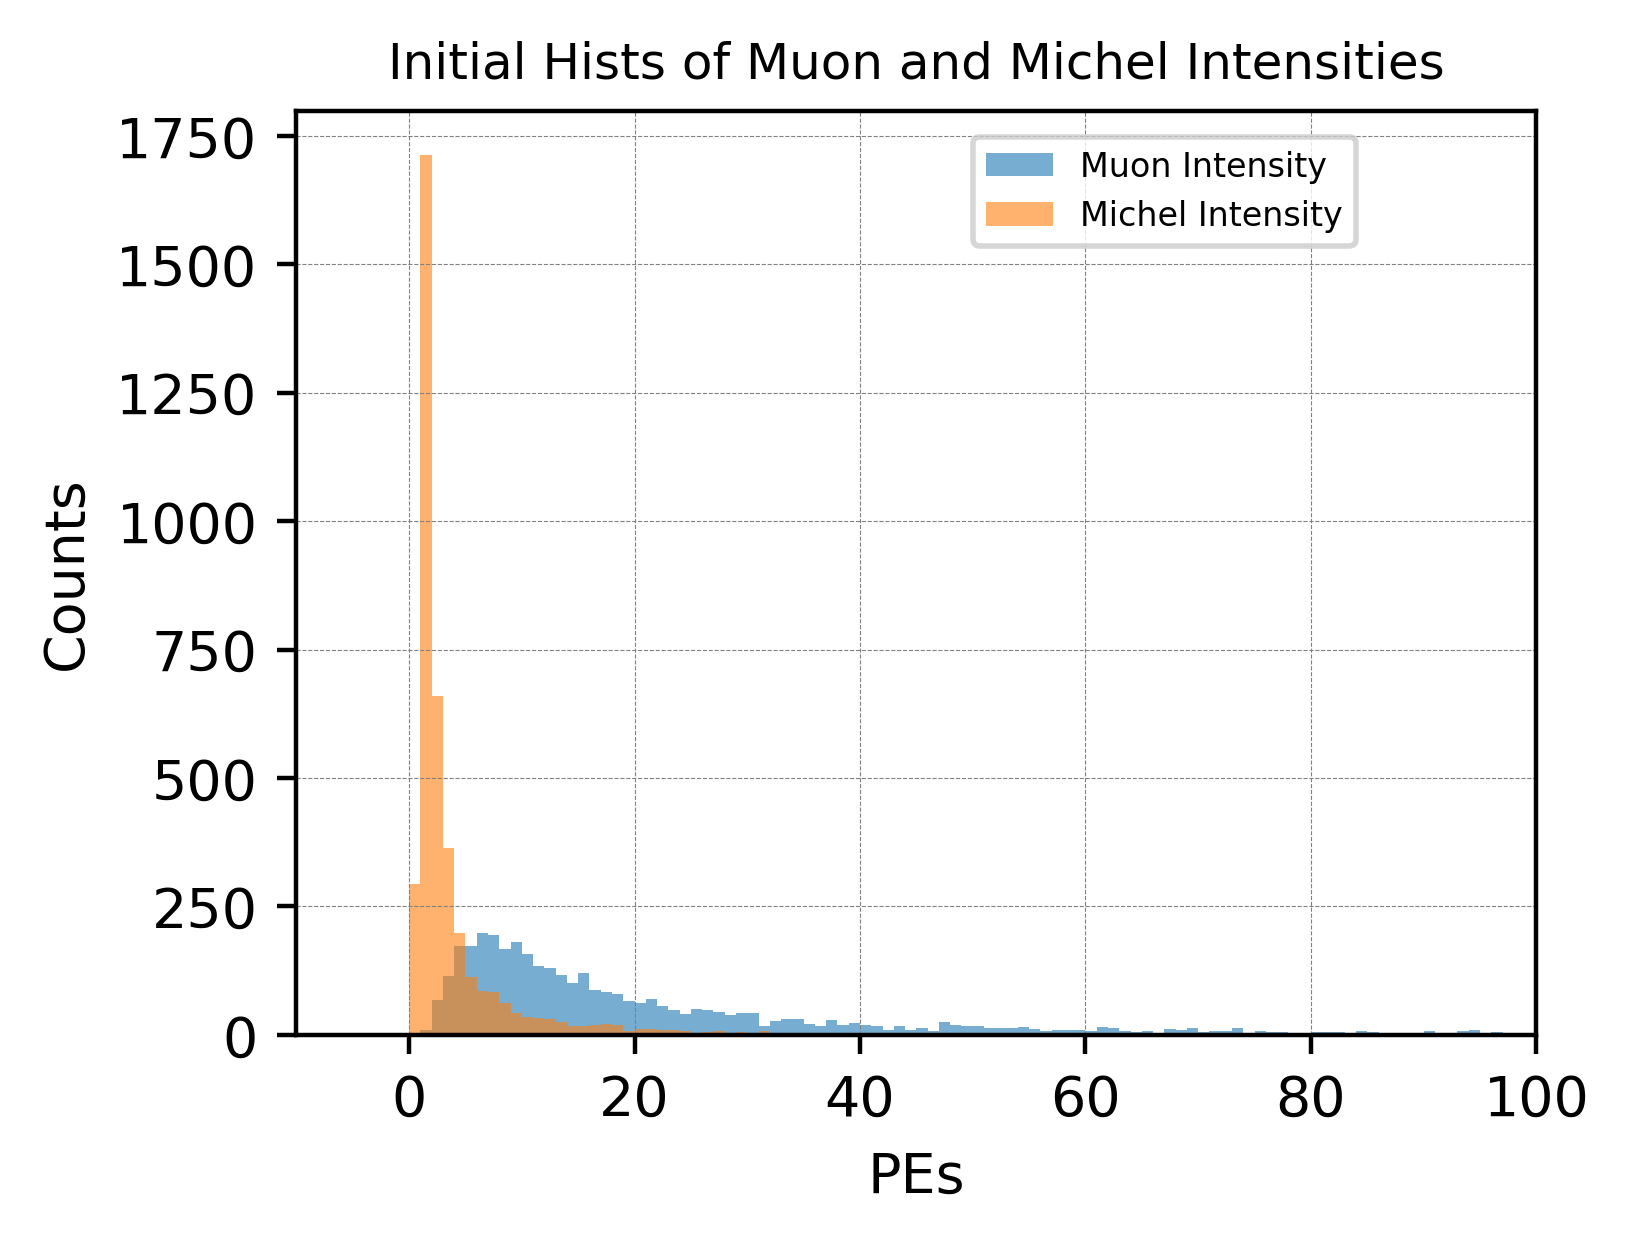

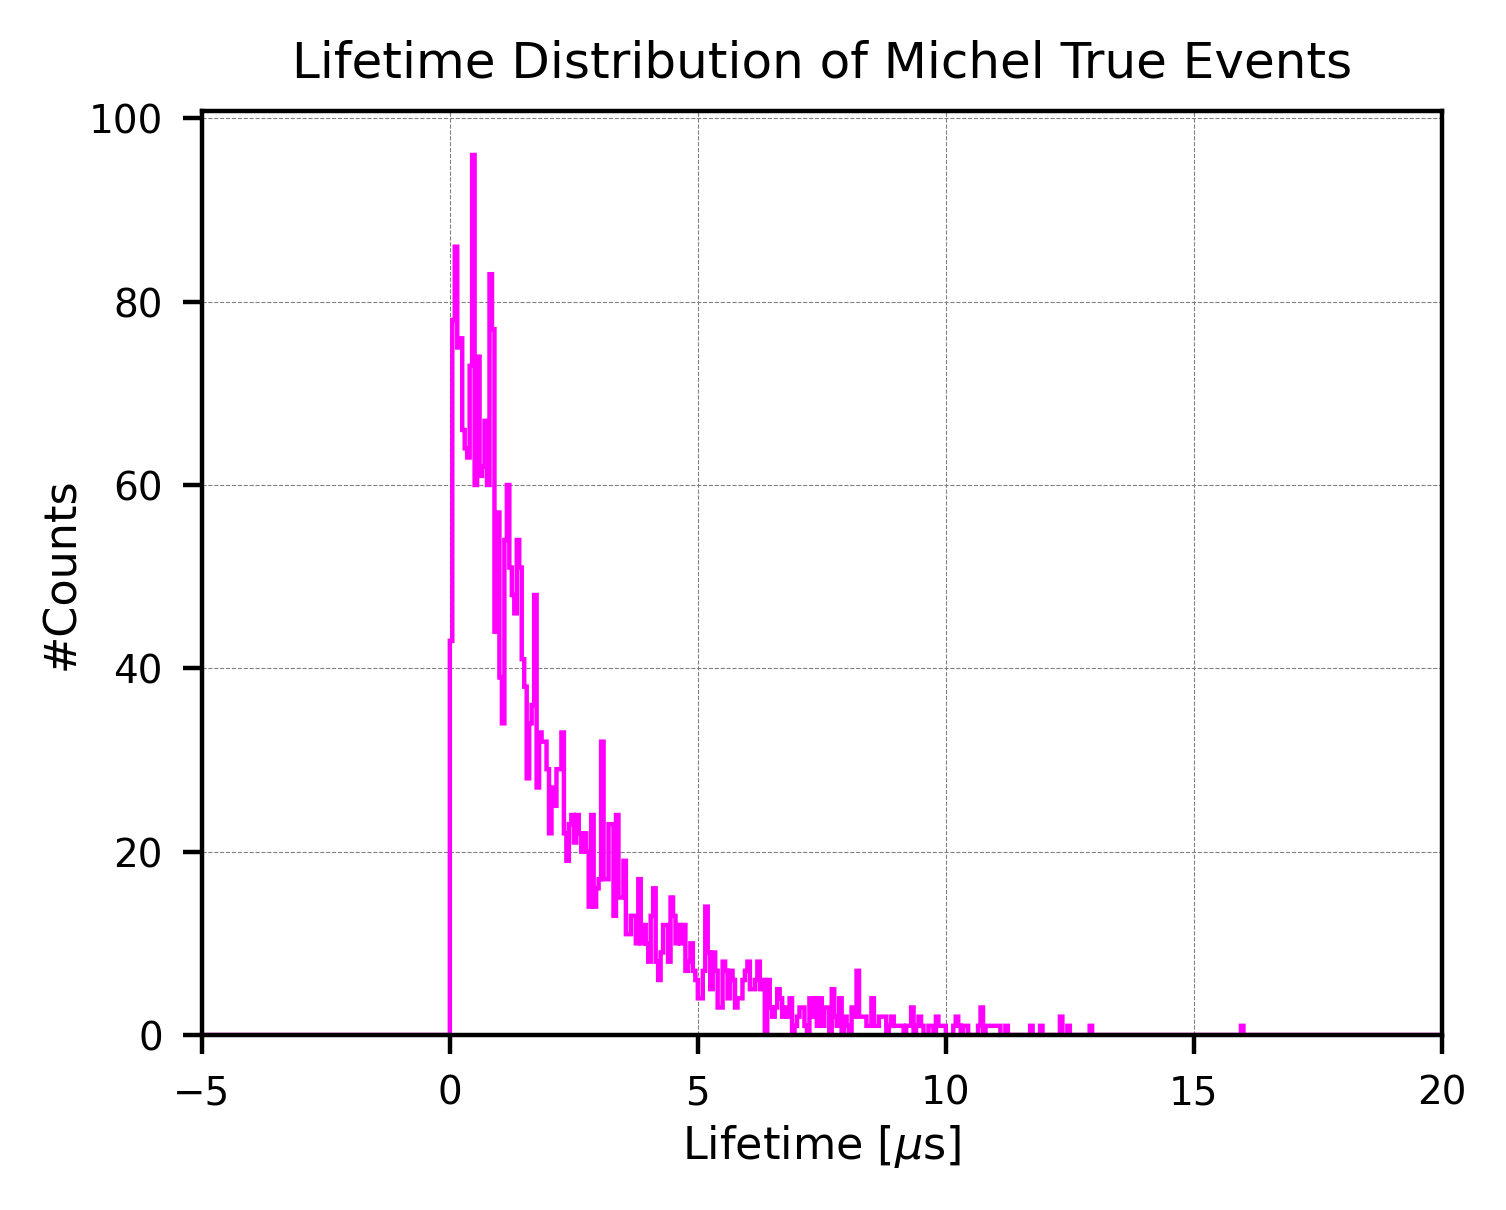

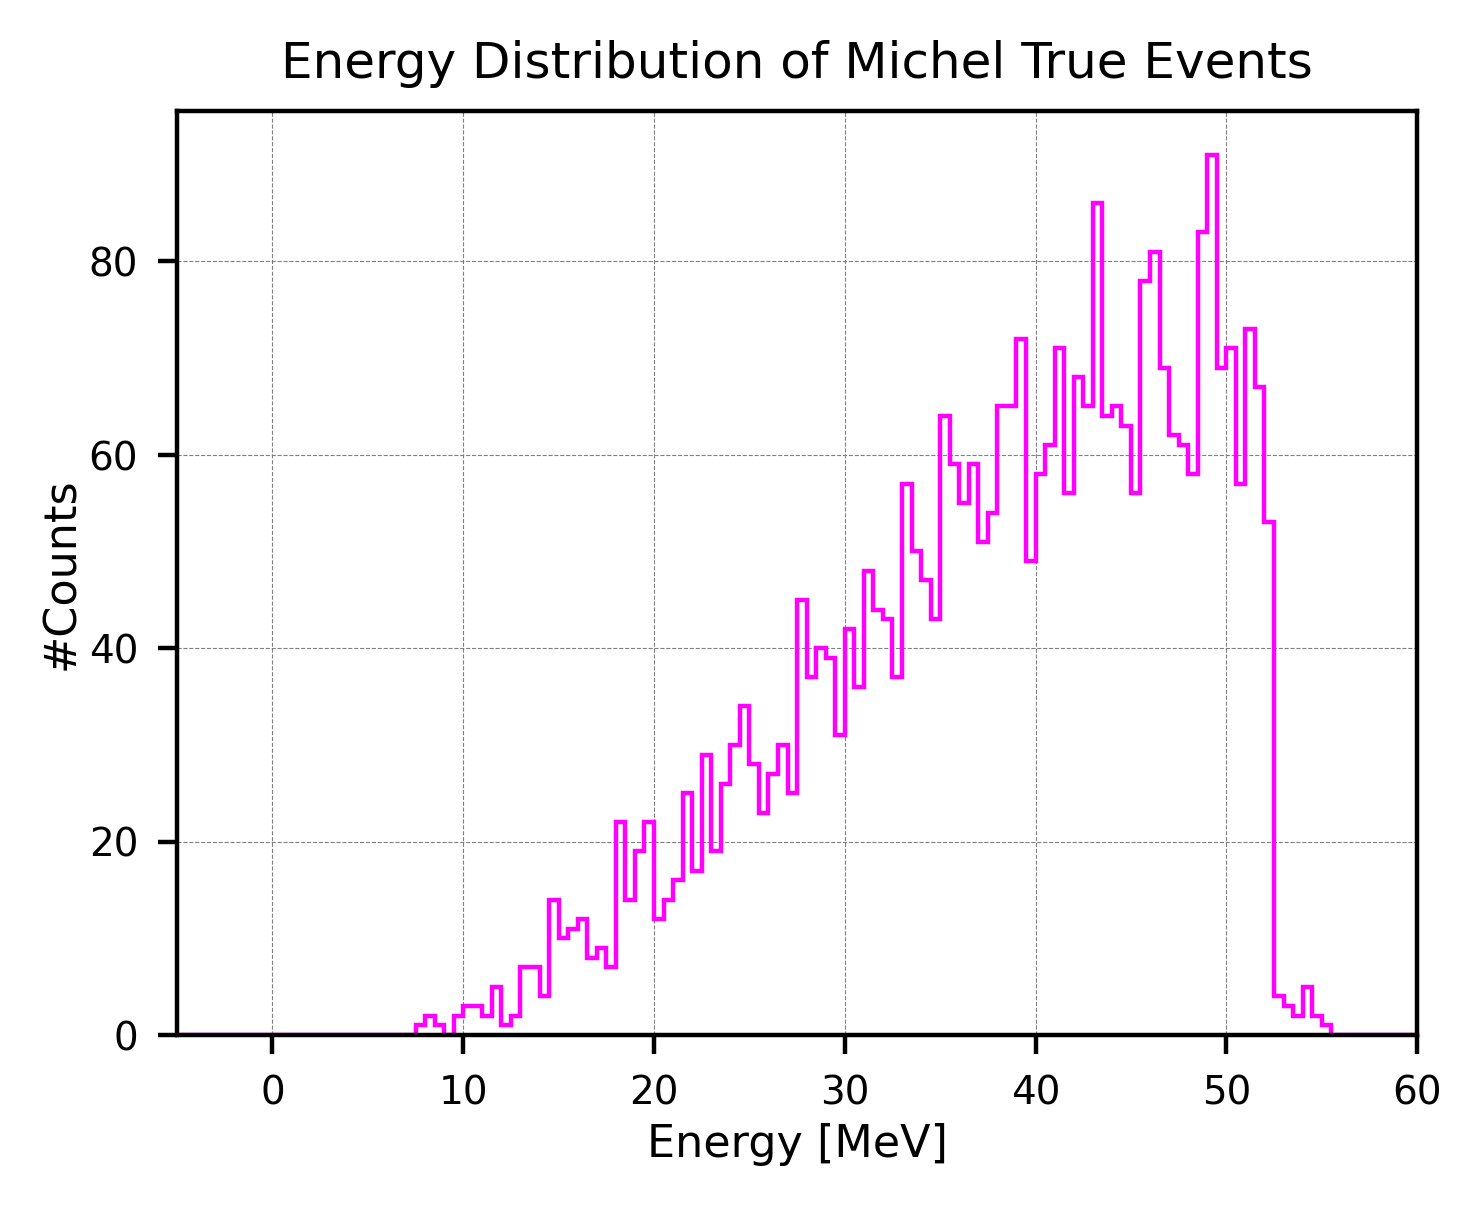

In [5]:
muon_time = [ev.muon_time for ev in events_reco_initial]
michel_time = [ev.michel_time for ev in events_reco_initial]

muon_intensity = [ev.muon_intensity for ev in events_reco_initial]
michel_intensity = [ev.michel_intensity for ev in events_reco_initial]

lifetime = [ev.lifetime for ev in events_true_initial] #true lifetime---
energy = [ev.energy for ev in events_true_initial] 


#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_time, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(michel_time, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()




#Initial Mu and Michel intensity distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 100
bin_width_initial = 1  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_intensity, bins=bins, alpha=0.6, label='Muon Intensity')
plt.hist(michel_intensity, bins=bins, alpha=0.6, label='Michel Intensity')

plt.xlabel('PEs')
plt.ylabel('Counts')
#plt.yscale('log')
plt.xlim(-10, 100)
plt.title('Initial Hists of Muon and Michel Intensities', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()







#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(lifetime, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 20)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()  





#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(energy, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  





<br />
<br />
<br />
<br />


### Purification 1: remove abnormal muon signals (constrain muTime to [120, 130])

Muon events selection (mu peak constrained to [120, 130]):
Updated Muon events:  3716 (93.74%)
Length of time_difference (Updated):  3716

Michel purity:  3261 /  3716 (87.76%)


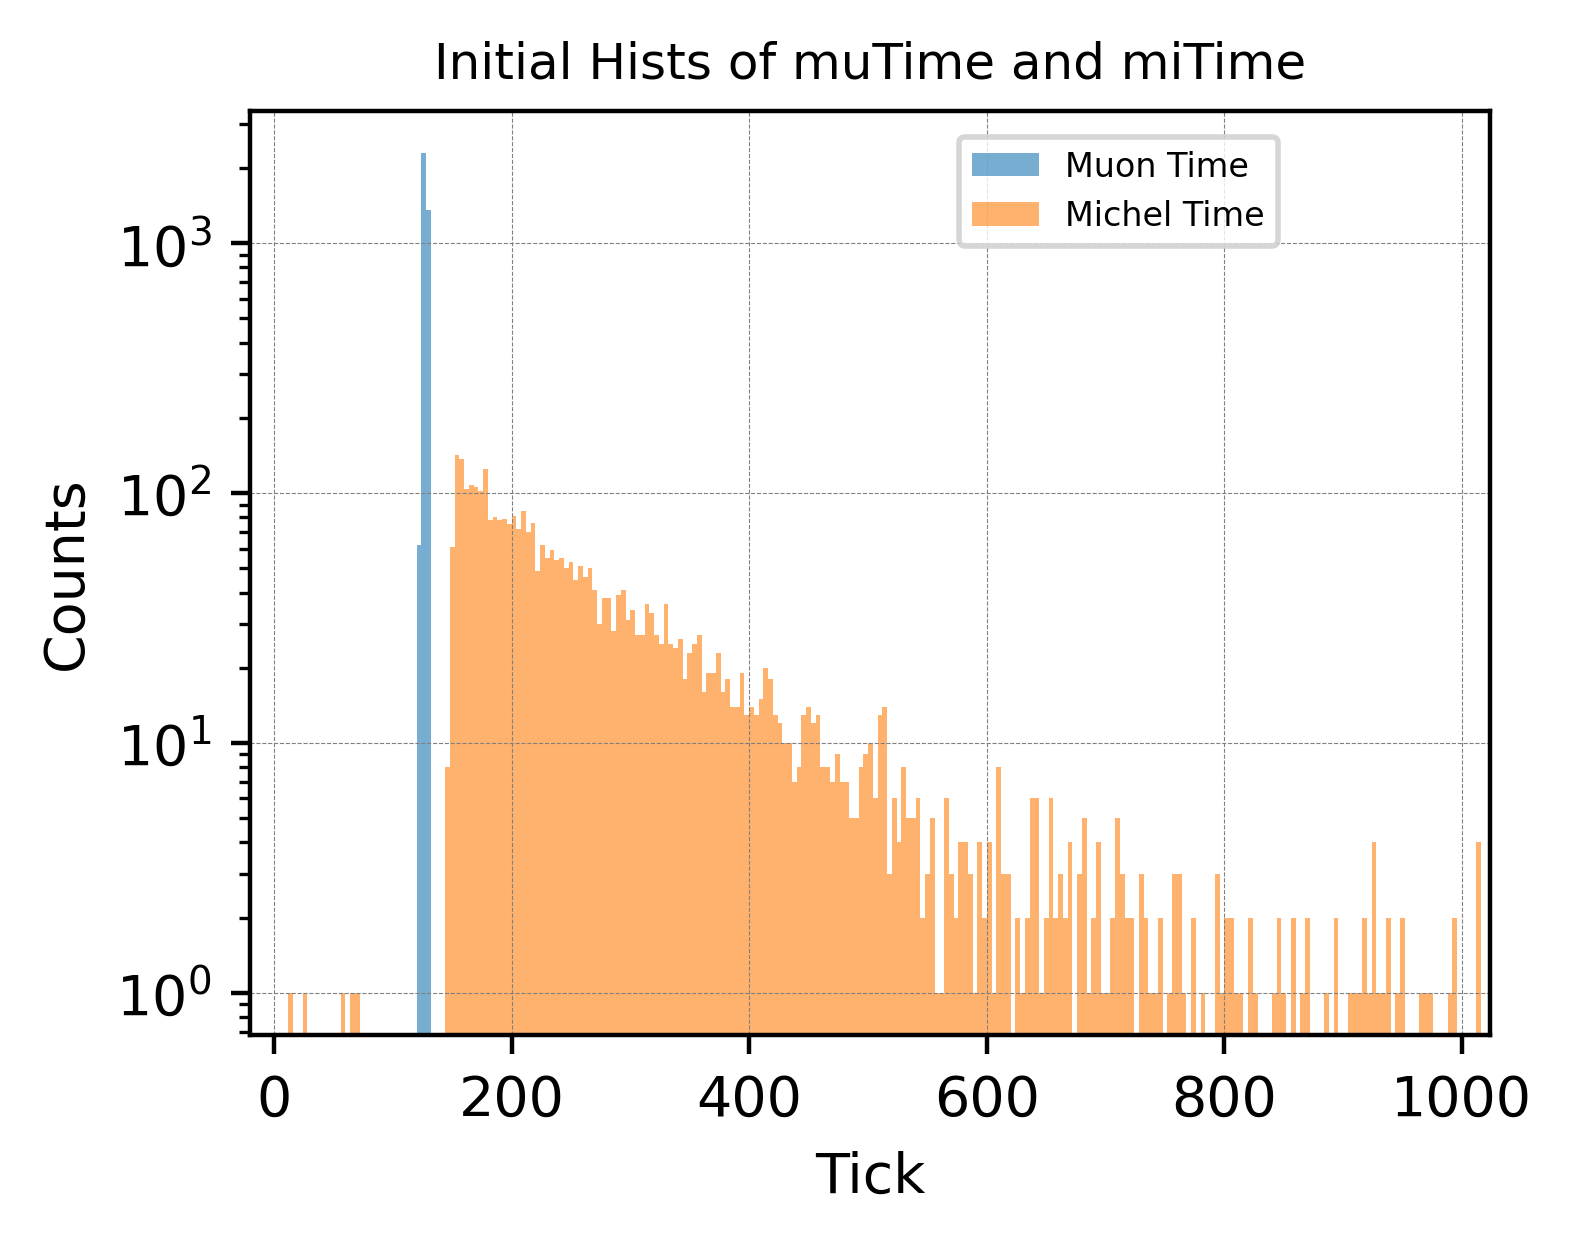




Lifetime distribution (Updated):
# Initial Candidates [-16000, 16000]:  3716


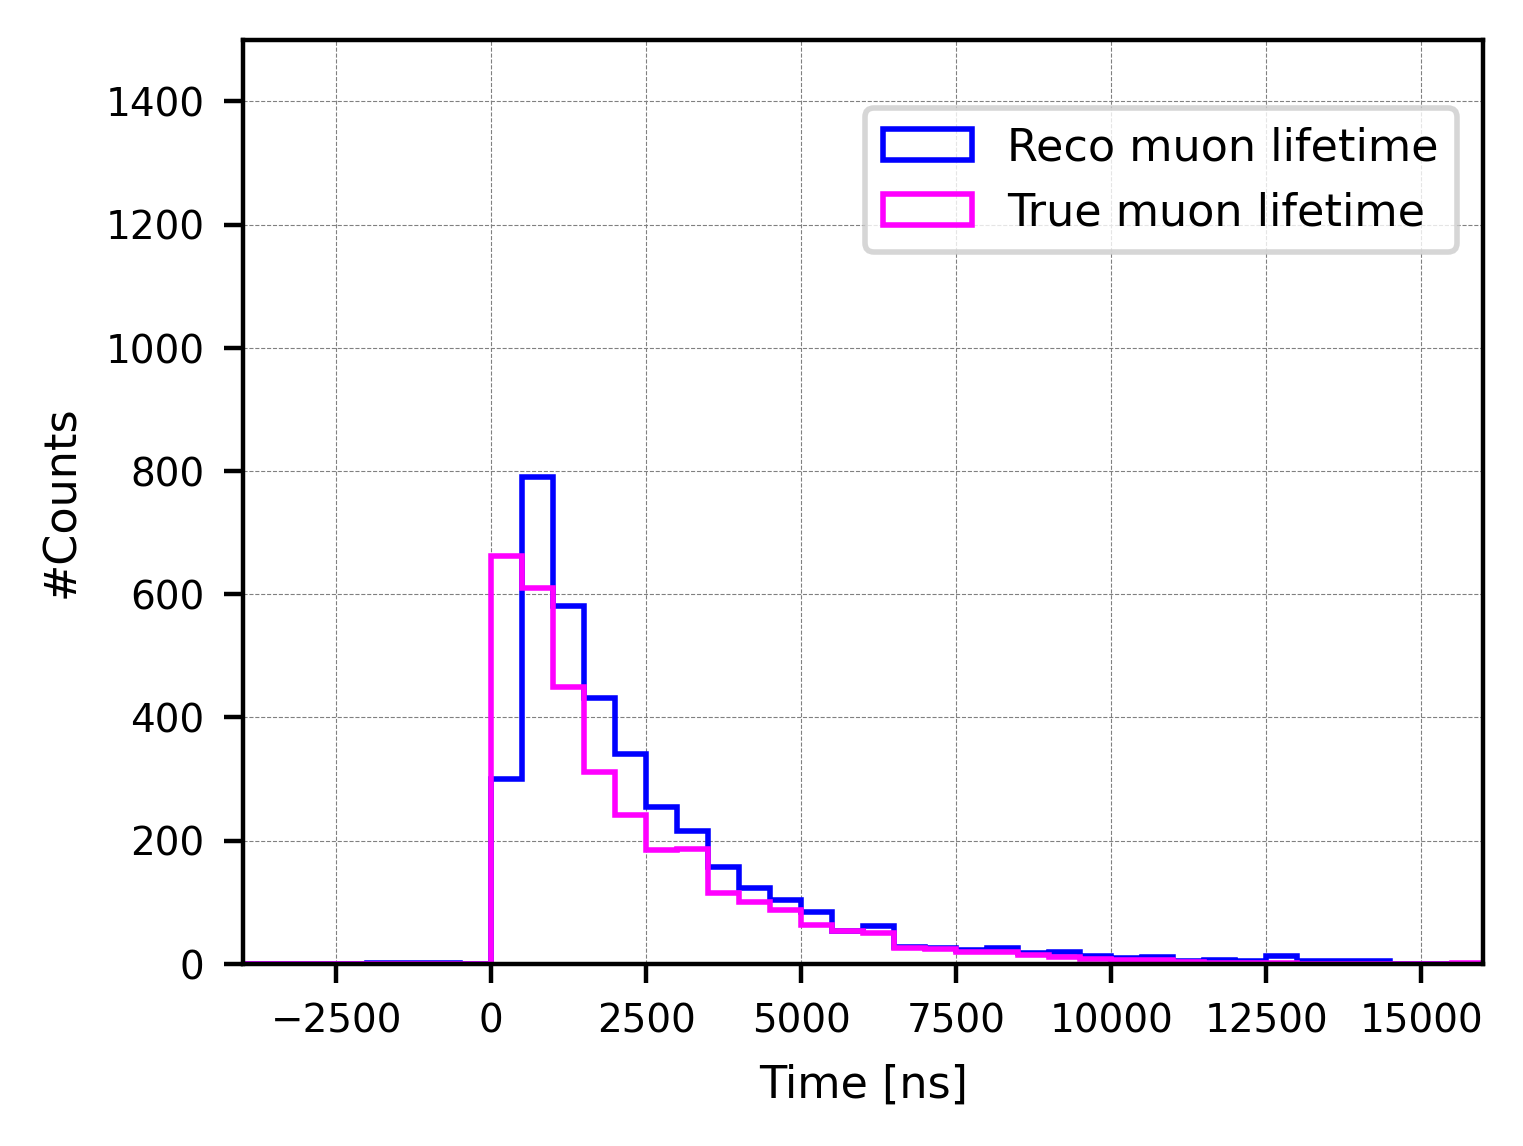

In [6]:
events_reco_update1 = []
events_true_update1 = []

lifetime_reco_update1 = []

for ev in events_reco_initial:
    muTime = ev.muon_time
    miTime = ev.michel_time
    energy = ev.energy

    if 120 <= muTime <= 130:
        events_reco_update1.append(ev)
        t = miTime-muTime
        lifetime_reco_update1.append(t)

        if energy > 0:
            events_true_update1.append(ev)


print("Muon events selection (mu peak constrained to [120, 130]):")
print("Updated Muon events: ", len(events_reco_update1),
       "({:.2f}%)".format(len(events_reco_update1)/len(events_reco_initial)*100))

# Element-wise subtraction: (mi - mu) for each corresponding element
print("Length of time_difference (Updated): ", len(lifetime_reco_update1))

print("\nMichel purity: ", len(events_true_update1), "/ ", len(events_reco_update1), 
      "({:.2f}%)".format(len(events_true_update1)/len(events_reco_update1)*100)) 









#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

muTime_update = [ev.muon_time for ev in events_reco_update1]
miTime_update = [ev.michel_time for ev in events_reco_update1]


# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()









# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
timdeDiff_update_ns = [value * 16 for value in lifetime_reco_update1]#reco lifetime---

lifetime_true_update1 = [ev.lifetime for ev in events_true_update1]
lifetime_update_ns = [value * 1000 for value in lifetime_true_update1]#True lifetime---


print("\n\n\nLifetime distribution (Updated):")
print("# Initial Candidates [-16000, 16000]: ", len(timdeDiff_update_ns))

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(timdeDiff_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')

plt.hist(lifetime_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=1.0,
         label='True muon lifetime')


plt.xlim(-4000, 16000)
plt.ylim(0, 1500)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






<br />
<br />
<br />
<br />


### Purification 2: remove events with unphysical lifetime (constrain lifetime to [500, inf))




Lifetime distribution (Updated):
# Updated Candidates [500, 16000]:  3411

#Purity:  3003 / 3411 (88.04%)


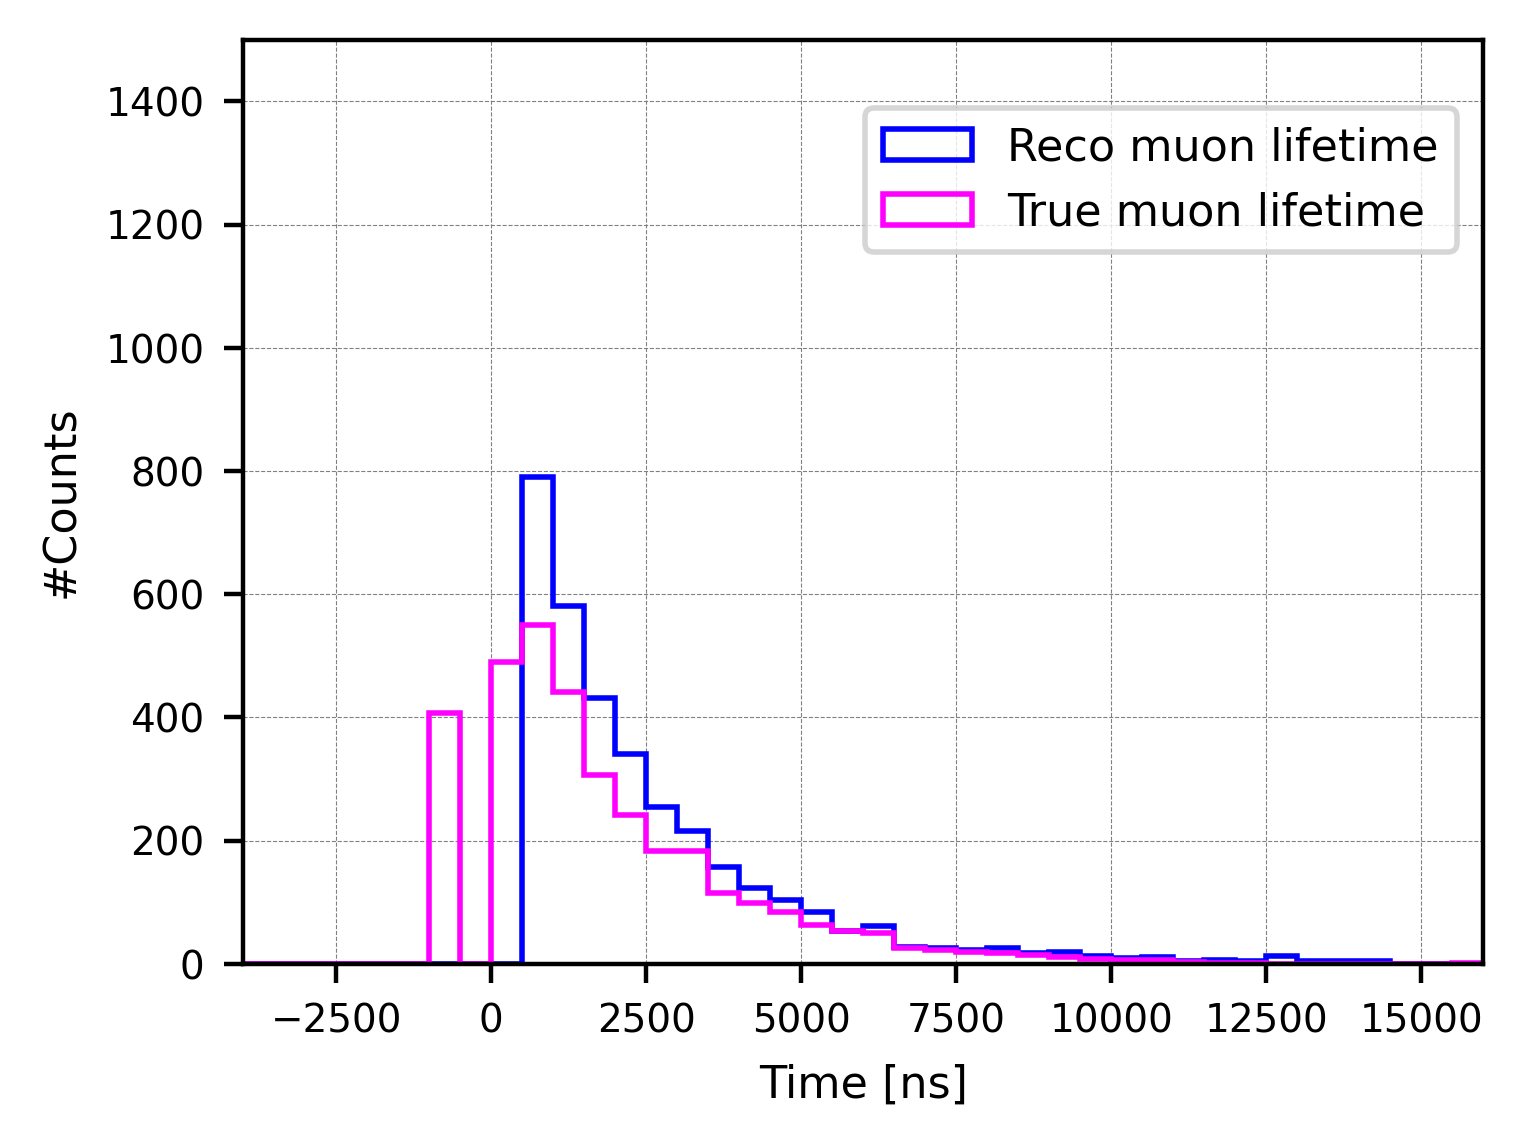


--------------------------------------
[-500, 500]:  2223 / 3411 (65.17%)


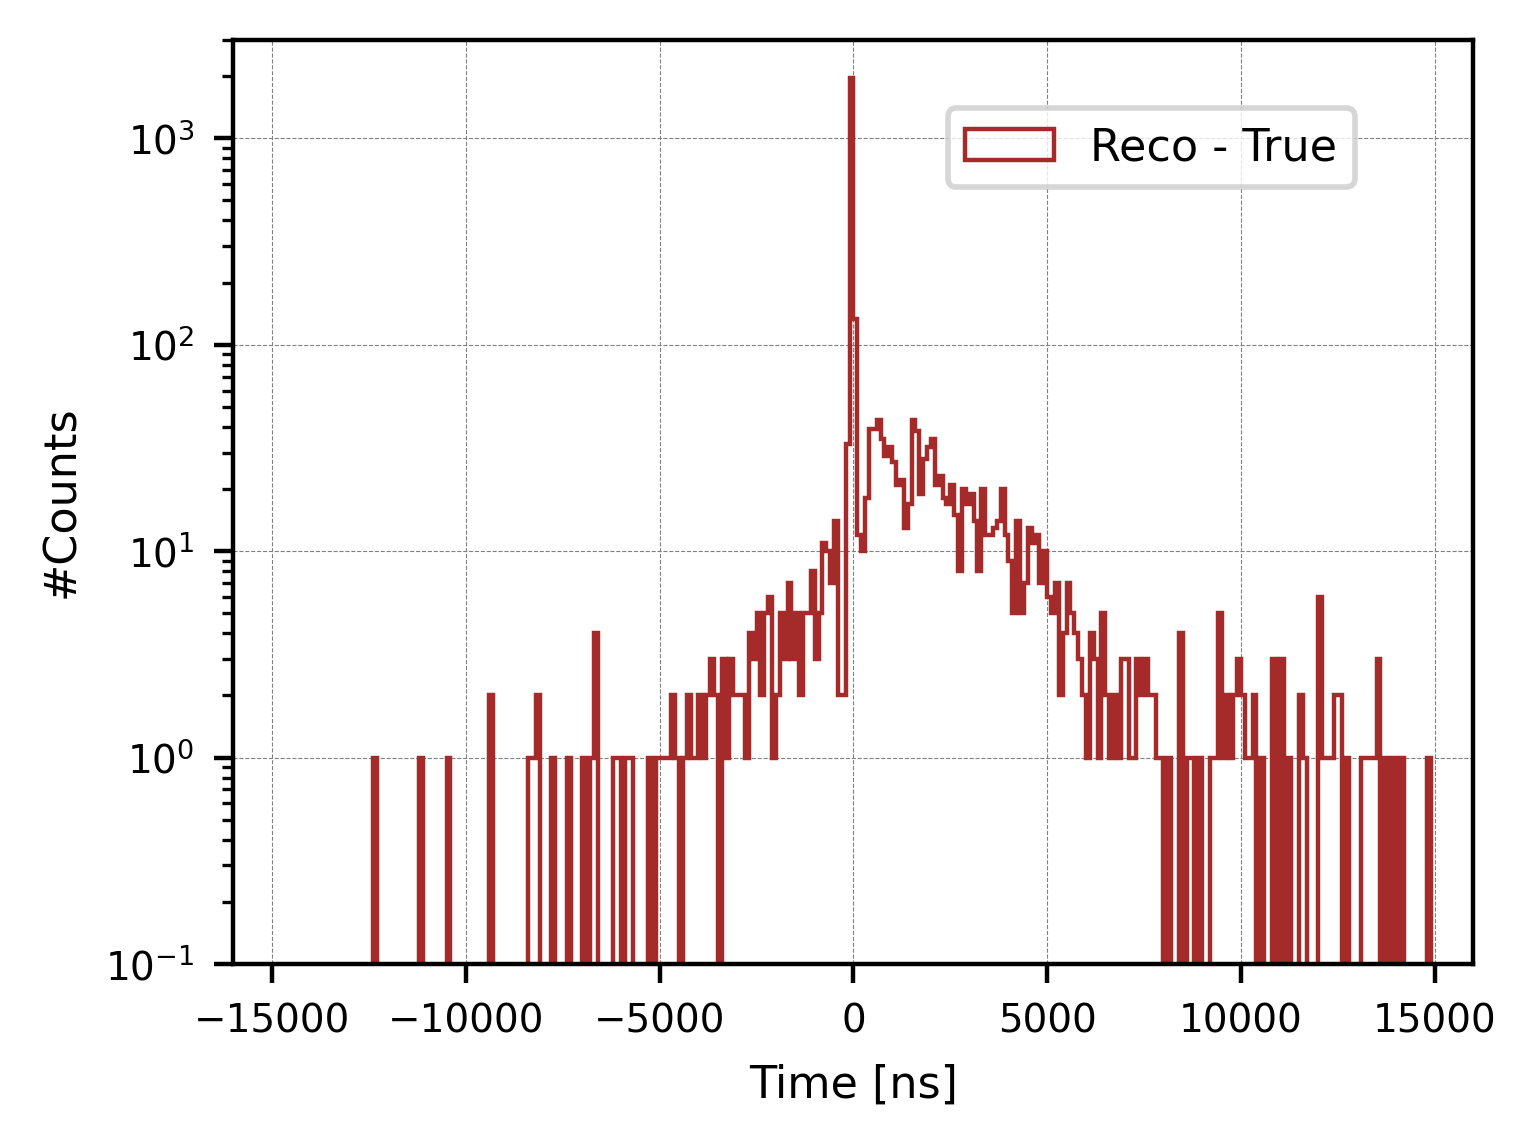

In [7]:
events_reco_update2 = []#Dataset after Purification 2---
events_true_update2 = []
lifetime_reco_update2 = []

for ev in events_reco_update1:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---
    e = ev.energy

    if 500 <= timeDiff:
        events_reco_update2.append(ev)
        lifetime_reco_update2.append(timeDiff)

        if e > 0:
            events_true_update2.append(ev)


print("\n\n\nLifetime distribution (Updated):")
print("# Updated Candidates [500, 16000]: ", len(events_reco_update2))

        
print("\n#Purity: ", len(events_true_update2), "/", len(events_reco_update2), 
     "({:.2f}%)".format(len(events_true_update2)/len(events_reco_update2)*100))







# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_reco_update2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')


lifetime_update_ns2 = [ev.lifetime * 1000 for ev in events_reco_update2]#True lifetime (contain false)---
plt.hist(lifetime_update_ns2, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=1.0,
         label='True muon lifetime')


plt.xlim(-4000, 16000)
plt.ylim(0, 1500)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()







#---------------------------------------------------------------
#Reco True difference-------------------------------------------

diff_reco_true = []
for ev in events_reco_update2:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---
    lifetime = ev.lifetime * 1000 #convert to ns---

    diff_reco_true.append(timeDiff-lifetime)


reco_true_count_500 = sum(-500 <= x <= 500 for x in diff_reco_true)
print("\n--------------------------------------")
print("[-500, 500]: ", reco_true_count_500, "/", len(diff_reco_true), 
     "({:.2f}%)".format(reco_true_count_500/len(diff_reco_true)*100))


#------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(diff_reco_true, bins=bins, range=(range_min, range_max),
         edgecolor='brown', histtype='step', linewidth=0.8,
         label='Reco - True')


plt.xlim(-16000, 16000)
plt.ylim(0.1, 3000)
plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






### Event-by-event Inspection:

Reco with 500ns < True.   :  2513 / 3411 (73.67%)
Reco with 0 < True < 500ns:  490 / 3411 (14.37%)
Reco with True < 0 (False):  408 / 3411 (11.96%)


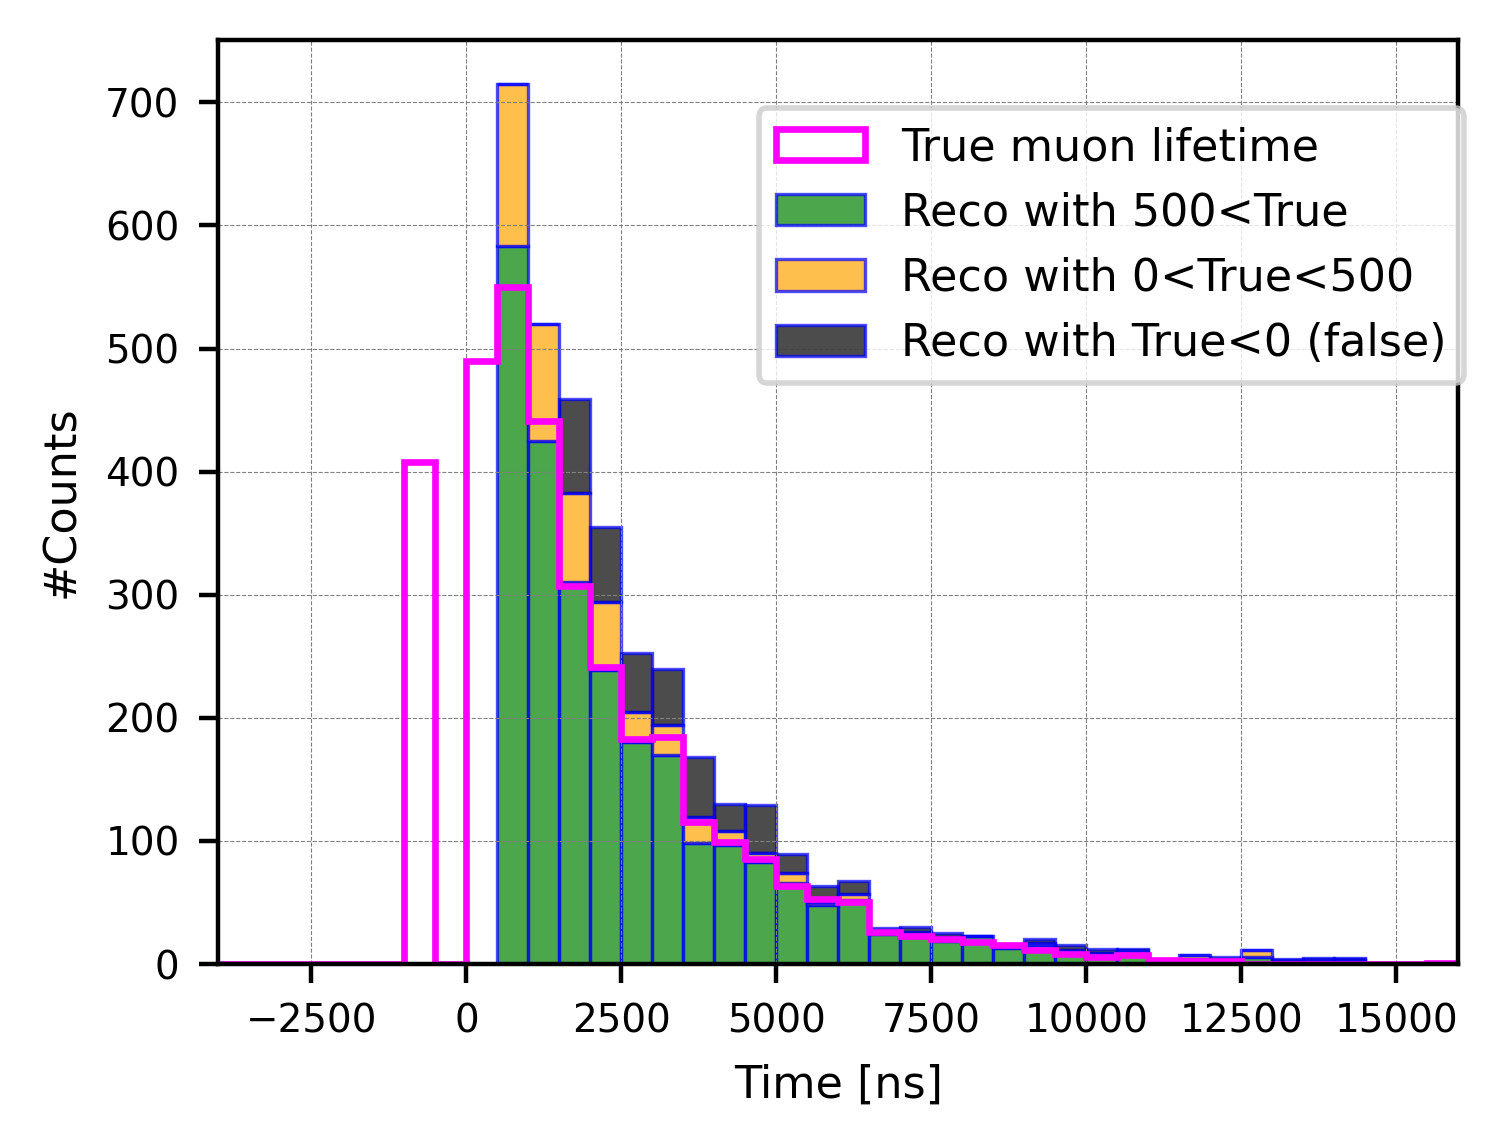


Total Events (diff)-----------------
|diff| <= 500   :  2223 / 3411 (65.17%)
diff_true500 Events (diff)----------
|diff| <= 500   :  2168 / 2513 (86.27%)


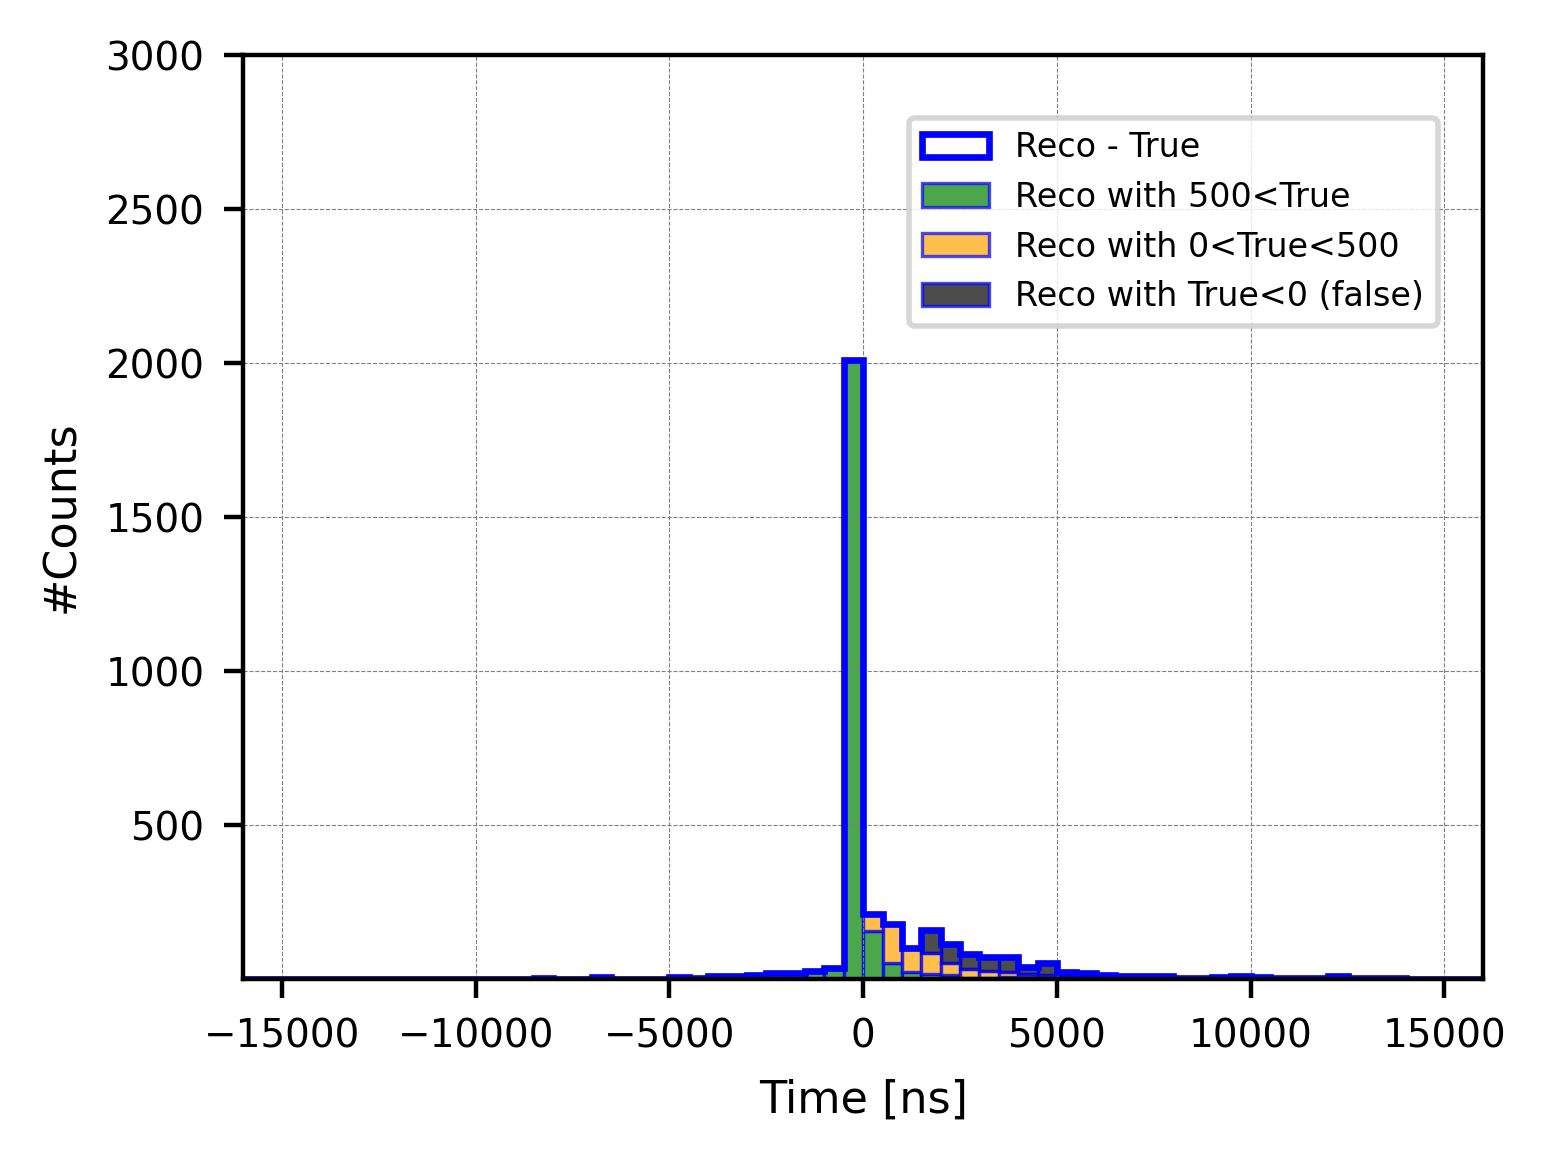

In [8]:
#lifetime_reco_update2 and lifetime_update_ns2 are the final dataset!!!

reco_true500 = [] #reco with 500 < true
reco_true0 = [] #reco with 0 < true < 500
reco_false = [] #reco with true < 0

diff_total = [] #reco - true
diff_true500 = [] #(reco-true) with 500 < true
diff_true0 = [] # 0 < true < 500
diff_false = [] # true < 0

for i in range(0, len(lifetime_update_ns2)):
    reco = lifetime_reco_update2[i]
    true = lifetime_update_ns2[i]

    diff_total.append(reco-true)

    if 500 < true:
        reco_true500.append(reco)
        diff_true500.append(reco-true)
    elif 0 < true < 500:
        reco_true0.append(reco)
        diff_true0.append(reco-true)
    elif true < 0:
        reco_false.append(reco)
        diff_false.append(reco-true)


print("Reco with 500ns < True.   : ", len(reco_true500), "/", len(lifetime_reco_update2), 
     "({:.2f}%)".format(len(reco_true500)/len(lifetime_reco_update2)*100))
print("Reco with 0 < True < 500ns: ", len(reco_true0), "/", len(lifetime_reco_update2), 
     "({:.2f}%)".format(len(reco_true0)/len(lifetime_reco_update2)*100))
print("Reco with True < 0 (False): ", len(reco_false), "/", len(lifetime_reco_update2), 
     "({:.2f}%)".format(len(reco_false)/len(lifetime_reco_update2)*100))




# Muon Lifetime distribution====================================================
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram----------------------
plt.hist(lifetime_update_ns2, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=1.2,
         label='True muon lifetime')


# Stacked reco Michel histogram
plt.hist([reco_true500, reco_true0, diff_false], bins=bins, range=(range_min, range_max),
         color=['green', 'orange', 'black'], alpha=0.7,
         edgecolor='blue', histtype='bar', linewidth=0.6,
         label=['Reco with 500<True', 'Reco with 0<True<500', 'Reco with True<0 (false)'],
         stacked=True)


plt.xlim(-4000, 16000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.72, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()








# Diff distribution====================================================
plt.figure(figsize=(4, 3), dpi=400)


#Calculate the num of diff value within [-500, 500]---
count_500_total = sum(1 for x in diff_total if -500 <= x <= 500)
print("\nTotal Events (diff)-----------------")
print("|diff| <= 500   : ", count_500_total, "/", len(diff_total), 
     "({:.2f}%)".format(count_500_total/len(diff_total)*100))

count_500_true500 = sum(1 for x in diff_true500 if -500 <= x <= 500)
print("diff_true500 Events (diff)----------")
print("|diff| <= 500   : ", count_500_true500, "/", len(diff_true500), 
     "({:.2f}%)".format(count_500_true500/len(diff_true500)*100))



# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram----------------------
plt.hist(diff_total, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.2,
         label='Reco - True')


# Stacked reco Michel histogram
plt.hist([diff_true500, diff_true0, diff_false], bins=bins, range=(range_min, range_max),
         color=['green', 'orange', 'black'], alpha=0.7,
         edgecolor='blue', histtype='bar', linewidth=0.6,
         label=['Reco with 500<True', 'Reco with 0<True<500', 'Reco with True<0 (false)'],
         stacked=True)


plt.xlim(-16000, 16000)
plt.ylim(0.9, 3000)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=8, markerscale=5, ncol=1, prop={'size':6})
plt.show()




### Lifetime fittings:

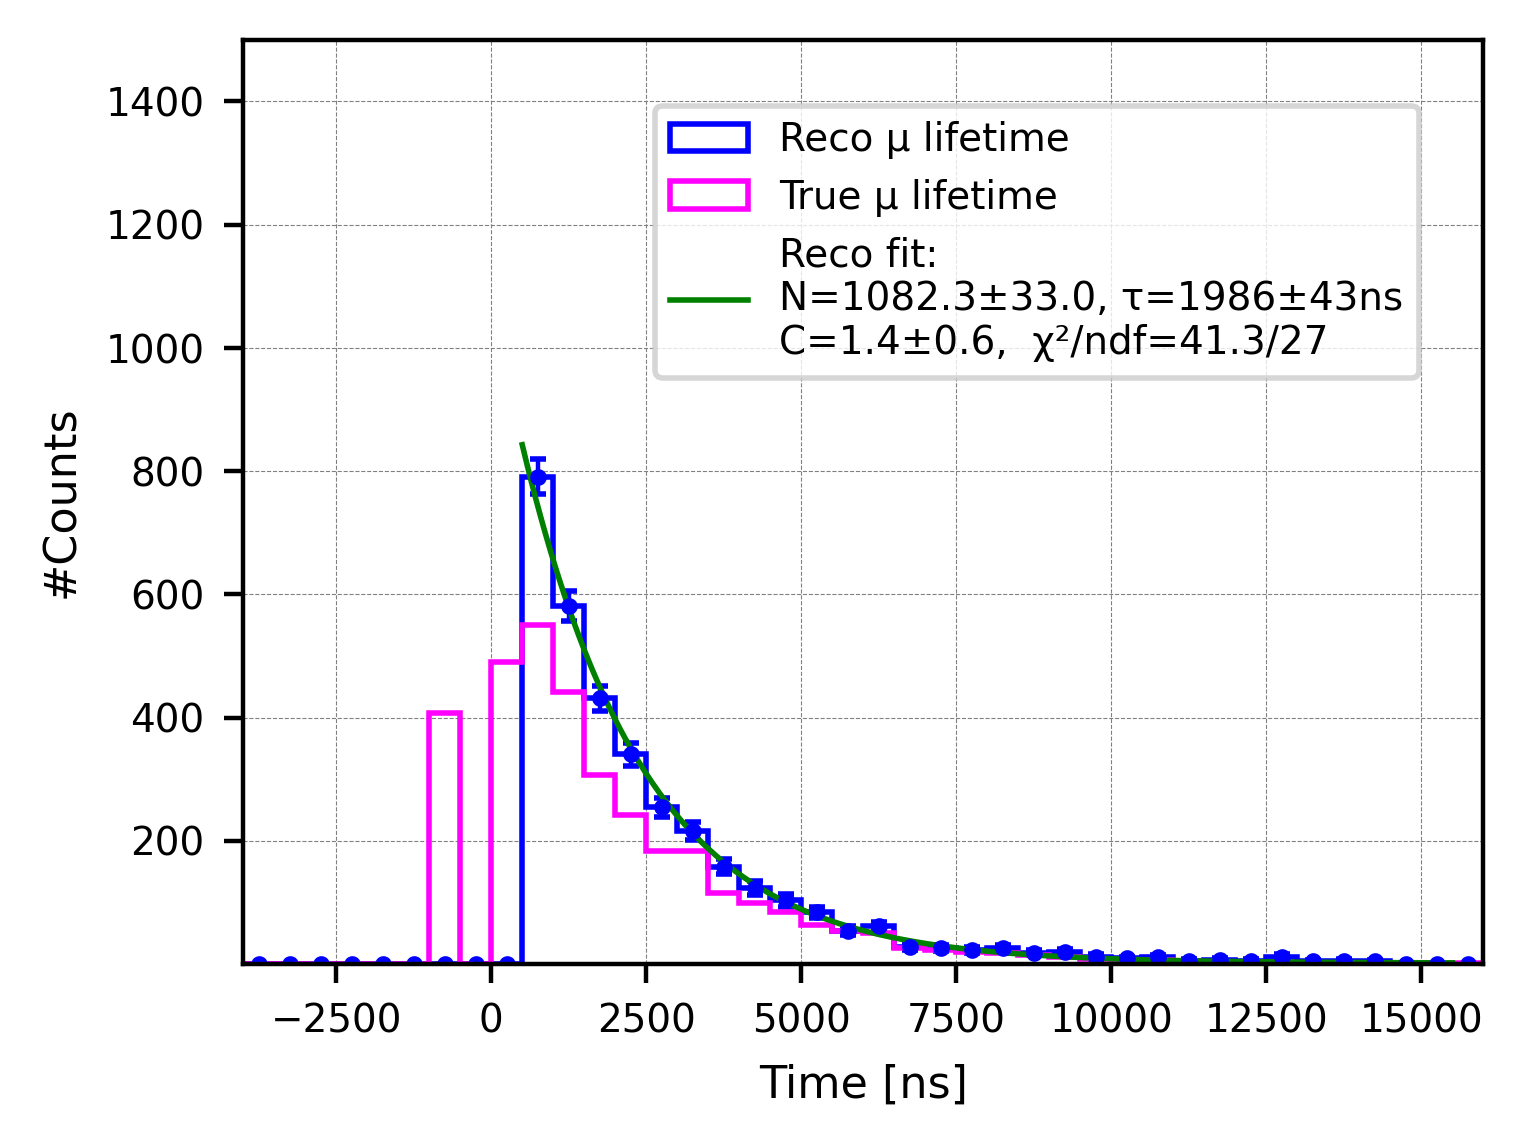

In [9]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt



#======Single Fitting==================================================
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histograms (Reco + True, but error bars only for Reco)
counts_reco, bin_edges_reco, _ = plt.hist(
    lifetime_reco_update2, bins=bins, range=(range_min, range_max),
    edgecolor='blue', histtype='step', linewidth=1.0,
    label='Reco μ lifetime'
)

# Add error bars for Reco
bin_centers_reco = 0.5 * (bin_edges_reco[:-1] + bin_edges_reco[1:])
errors_reco = np.sqrt(np.clip(counts_reco, 0, None))
plt.errorbar(
    bin_centers_reco, counts_reco, yerr=errors_reco,
    fmt='o', color='blue', markersize=2.0, elinewidth=0.8, capsize=1.5,
    label=None  # don’t duplicate legend entry
)

# True μ histogram
plt.hist(
    lifetime_update_ns2, bins=bins, range=(range_min, range_max),
    edgecolor='magenta', histtype='step', linewidth=1.0,
    label='True μ lifetime'
)

# ---------- add χ² fits with constant background ----------
def exp1C(t, N, tau, C):
    return N * np.exp(-t / tau) + C

def fit_and_overlay(sample, label, fit_min, fit_max, color=None, line_style='-'):
    # Use the SAME binning
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Select fit window
    m = (centers >= fit_min) & (centers <= fit_max)
    x = centers[m]
    y = counts[m].astype(float)

    if len(x) < 3 or y.sum() <= 0:
        print(f"[WARN] Not enough stats to fit {label}")
        return

    # Uncertainty per bin
    sigma = np.sqrt(np.clip(y, 1.0, None))

    # Initial guesses
    N0 = float(y.max())
    tau0 = max(100.0, (np.sum(y * (x - fit_min)) / max(np.sum(y), 1.0)))  # ns
    C0 = min(y)  # background level ~ lowest bin

    # Weighted least squares (χ²)
    popt, pcov = curve_fit(exp1C, x, y, p0=[N0, tau0, C0],
                           sigma=sigma, absolute_sigma=True, maxfev=20000)
    N_fit, tau_fit, C_fit = popt
    N_err, tau_err, C_err = np.sqrt(np.diag(pcov))

    # χ²/ndf
    yfit = exp1C(x, *popt)
    chi2 = np.sum(((y - yfit) / sigma) ** 2)
    ndf = max(len(x) - len(popt), 1)

    # Overlay smooth curve
    t_smooth = np.linspace(fit_min, fit_max, 400)
    plt.plot(
        t_smooth,
        exp1C(t_smooth, *popt),
        line_style,
        linewidth=1.0,
        color=color,
        label=(
            f"{label} fit:\n"
            f"N={N_fit:.1f}±{N_err:.1f}, τ={tau_fit:.0f}±{tau_err:.0f}ns\n"
            f"C={C_fit:.1f}±{C_err:.1f},  χ²/ndf={chi2:.1f}/{ndf}"
        ),
    )


# Fit windows
fit_and_overlay(lifetime_reco_update2, "Reco",  500, 15500, color="green", line_style='-')
#fit_and_overlay(lifetime_update_ns2, "True",     0, 15500, color="magenta")
# ---------- end fits ----------

plt.xlim(-4000, 16000)
plt.ylim(0.1, 1500)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.64, 0.95), fontsize=9,
           markerscale=5, ncol=1, prop={'size':7})
plt.show()


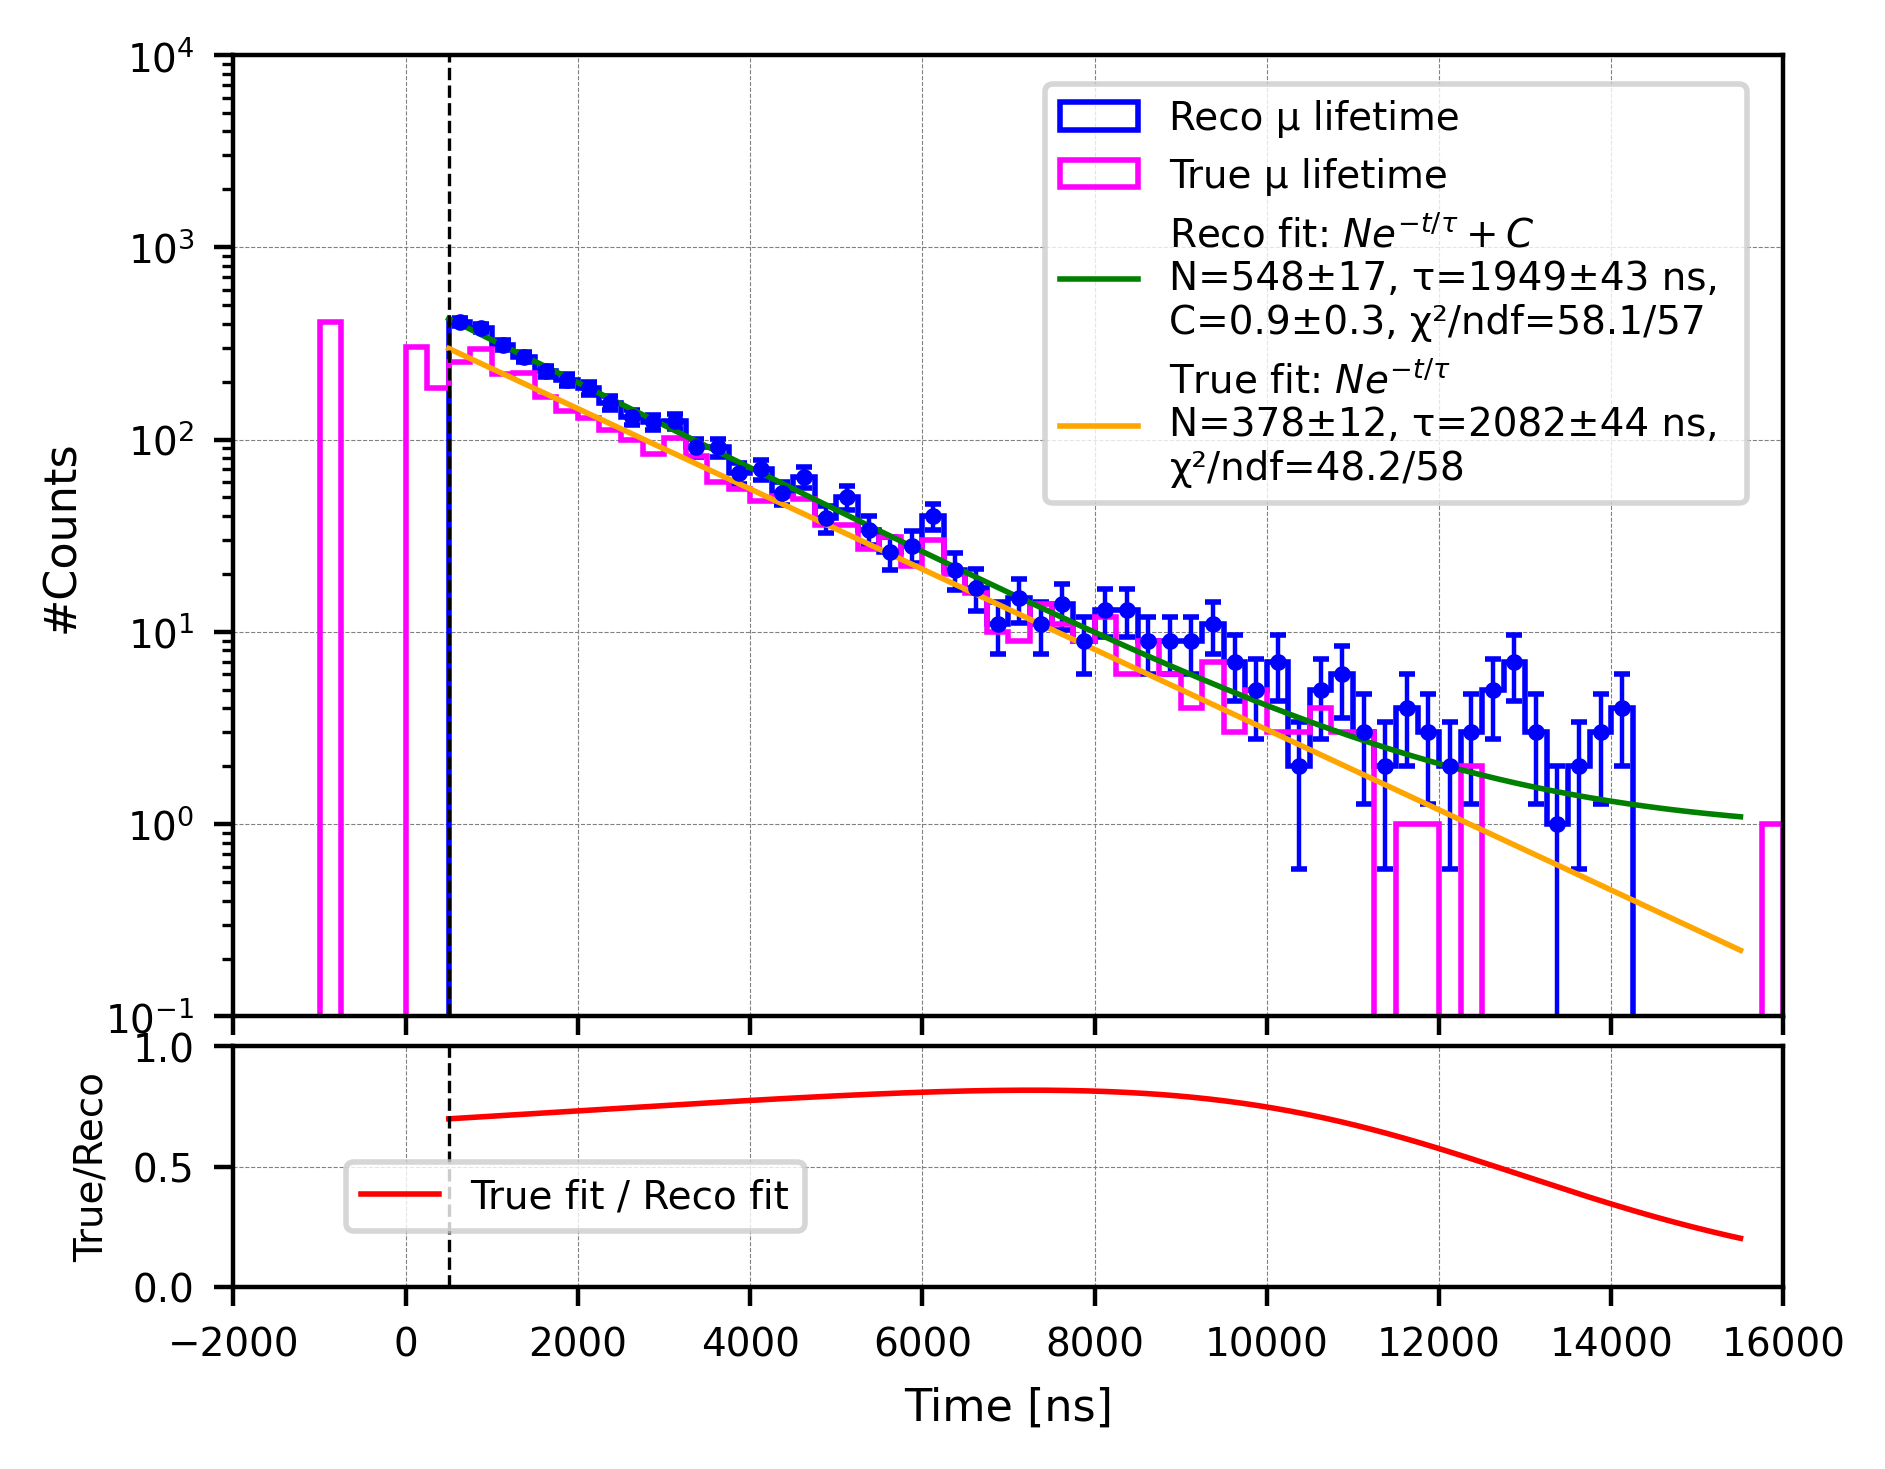

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec

#======Double Fitting with Ratio Panel==================================================
fig = plt.figure(figsize=(5, 4), dpi=400)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

# Histogram binning
bin_width = 250
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Models
def exp1C(t, N, tau, C):
    return N * np.exp(-t / tau) + C

def exp1(t, N, tau):
    return N * np.exp(-t / tau)

# --- Generic helpers ---
def _safe_sigma(y):
    return np.sqrt(np.clip(y, 1.0, None))

def _tau_guess(x, y, fit_min):
    return max(100.0, (np.sum(y * (x - fit_min)) / max(np.sum(y), 1.0)))

# --- Reco fit: N*exp(-t/tau) + C ---
def fit_and_overlay_exp1C(ax, sample, label, fit_min, fit_max, color=None, line_style='-'):
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    m = (centers >= fit_min) & (centers <= fit_max)
    x = centers[m]
    y = counts[m].astype(float)

    if len(x) < 3 or y.sum() <= 0:
        print(f"[WARN] Not enough stats to fit {label} (exp1C)")
        return None, None, None

    sigma = _safe_sigma(y)
    N0   = float(y.max())
    tau0 = _tau_guess(x, y, fit_min)
    C0   = float(np.min(y))
    p0   = [N0, tau0, C0]

    popt, pcov = curve_fit(exp1C, x, y, p0=p0, sigma=sigma, absolute_sigma=True, maxfev=20000)
    perr = np.sqrt(np.diag(pcov))

    yfit = exp1C(x, *popt)
    chi2 = np.sum(((y - yfit) / sigma) ** 2)
    ndf  = max(len(x) - len(popt), 1)

    t_smooth = np.linspace(fit_min, fit_max, 400)
    ax.plot(
        t_smooth, exp1C(t_smooth, *popt),
        line_style, linewidth=1.0, color=color,
        # function printed on SAME line as 'Reco fit'
        label=(rf"{label} fit: $N e^{{-t/\tau}} + C$"
               f"\nN={popt[0]:.0f}±{perr[0]:.0f}, "
               f"τ={popt[1]:.0f}±{perr[1]:.0f} ns, "
               f"\nC={popt[2]:.1f}±{perr[2]:.1f}, "
               f"χ²/ndf={chi2:.1f}/{ndf}")
    )
    return t_smooth, exp1C(t_smooth, *popt), popt

# --- True fit: N*exp(-t/tau) (NO constant) ---
def fit_and_overlay_exp1(ax, sample, label, fit_min, fit_max, color=None, line_style='-'):
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    m = (centers >= fit_min) & (centers <= fit_max)
    x = centers[m]
    y = counts[m].astype(float)

    if len(x) < 3 or y.sum() <= 0:
        print(f"[WARN] Not enough stats to fit {label} (exp1)")
        return None, None, None

    sigma = _safe_sigma(y)
    N0   = float(y.max())
    tau0 = _tau_guess(x, y, fit_min)
    p0   = [N0, tau0]

    popt, pcov = curve_fit(exp1, x, y, p0=p0, sigma=sigma, absolute_sigma=True, maxfev=20000)
    perr = np.sqrt(np.diag(pcov))

    yfit = exp1(x, *popt)
    chi2 = np.sum(((y - yfit) / sigma) ** 2)
    ndf  = max(len(x) - len(popt), 1)

    t_smooth = np.linspace(fit_min, fit_max, 400)
    ax.plot(
        t_smooth, exp1(t_smooth, *popt),
        line_style, linewidth=1.0, color=color,
        # function printed on SAME line as 'True fit'
        label=(rf"{label} fit: $N e^{{-t/\tau}}$"
               f"\nN={popt[0]:.0f}±{perr[0]:.0f}, "
               f"τ={popt[1]:.0f}±{perr[1]:.0f} ns, "
               f"\nχ²/ndf={chi2:.1f}/{ndf}")
    )
    return t_smooth, exp1(t_smooth, *popt), popt

# -------- Top panel (histograms + fits) --------
ax1 = fig.add_subplot(gs[0])

# Reco histogram + error bars
counts_reco, bin_edges_reco, _ = ax1.hist(
    lifetime_reco_update2, bins=bins, range=(range_min, range_max),
    edgecolor='blue', histtype='step', linewidth=1.0, label='Reco μ lifetime'
)
bin_centers_reco = 0.5 * (bin_edges_reco[:-1] + bin_edges_reco[1:])
errors_reco = np.sqrt(np.clip(counts_reco, 0, None))
ax1.errorbar(bin_centers_reco, counts_reco, yerr=errors_reco,
             fmt='o', color='blue', markersize=2.0, elinewidth=0.8, capsize=1.5)

# True histogram (step only)
ax1.hist(
    lifetime_update_ns2, bins=bins, range=(range_min, range_max),
    edgecolor='magenta', histtype='step', linewidth=1.0, label='True μ lifetime'
)

# Fits: Reco -> exp1C, True -> exp1
t_reco, fit_reco, popt_reco = fit_and_overlay_exp1C(ax1, lifetime_reco_update2, "Reco",  
                                                    500, 15500, color="green")
t_true, fit_true, popt_true = fit_and_overlay_exp1 (ax1, lifetime_update_ns2,  "True", 
                                                     500, 15500, color="orange")

# Top panel styling
ax1.set_xlim(-2000, 16000)
ax1.tick_params(labelbottom=False)
ax1.set_ylim(0.1, 10000)
ax1.set_yscale('log')
ax1.axvline(x=500, color='black', linestyle='--', linewidth=0.6)
ax1.set_ylabel('#Counts', fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax1.legend(loc='upper center', bbox_to_anchor=(0.75, 0.99),
           fontsize=9, markerscale=5, ncol=1, prop={'size':7})

# -------- Bottom panel (ratio True/Reco) --------
ax2 = fig.add_subplot(gs[1], sharex=ax1)

if popt_reco is not None and popt_true is not None:
    t_common = np.linspace(500, 15500, 400)
    fit_reco_common = exp1C(t_common, *popt_reco)
    fit_true_common = exp1(t_common, *popt_true)

    ratio = np.divide(fit_true_common, fit_reco_common,
                      out=np.zeros_like(fit_true_common),
                      where=(fit_reco_common > 0))

    ax2.plot(t_common, ratio, color='red', linewidth=1.0, label='True fit / Reco fit')

ax2.axvline(x=500, color='black', linestyle='--', linewidth=0.6)
ax2.set_xlim(-2000, 16000)
ax2.set_ylim(0.0, 1.0)
ax2.set_xlabel('Time [ns]', fontsize=8)
ax2.set_ylabel('True/Reco', fontsize=7)
ax2.tick_params(labelsize=7)
ax2.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax2.legend(loc='upper left', bbox_to_anchor=(0.06, 0.6), fontsize=7)

plt.show()




#### Bin-integrated Fitting (best)

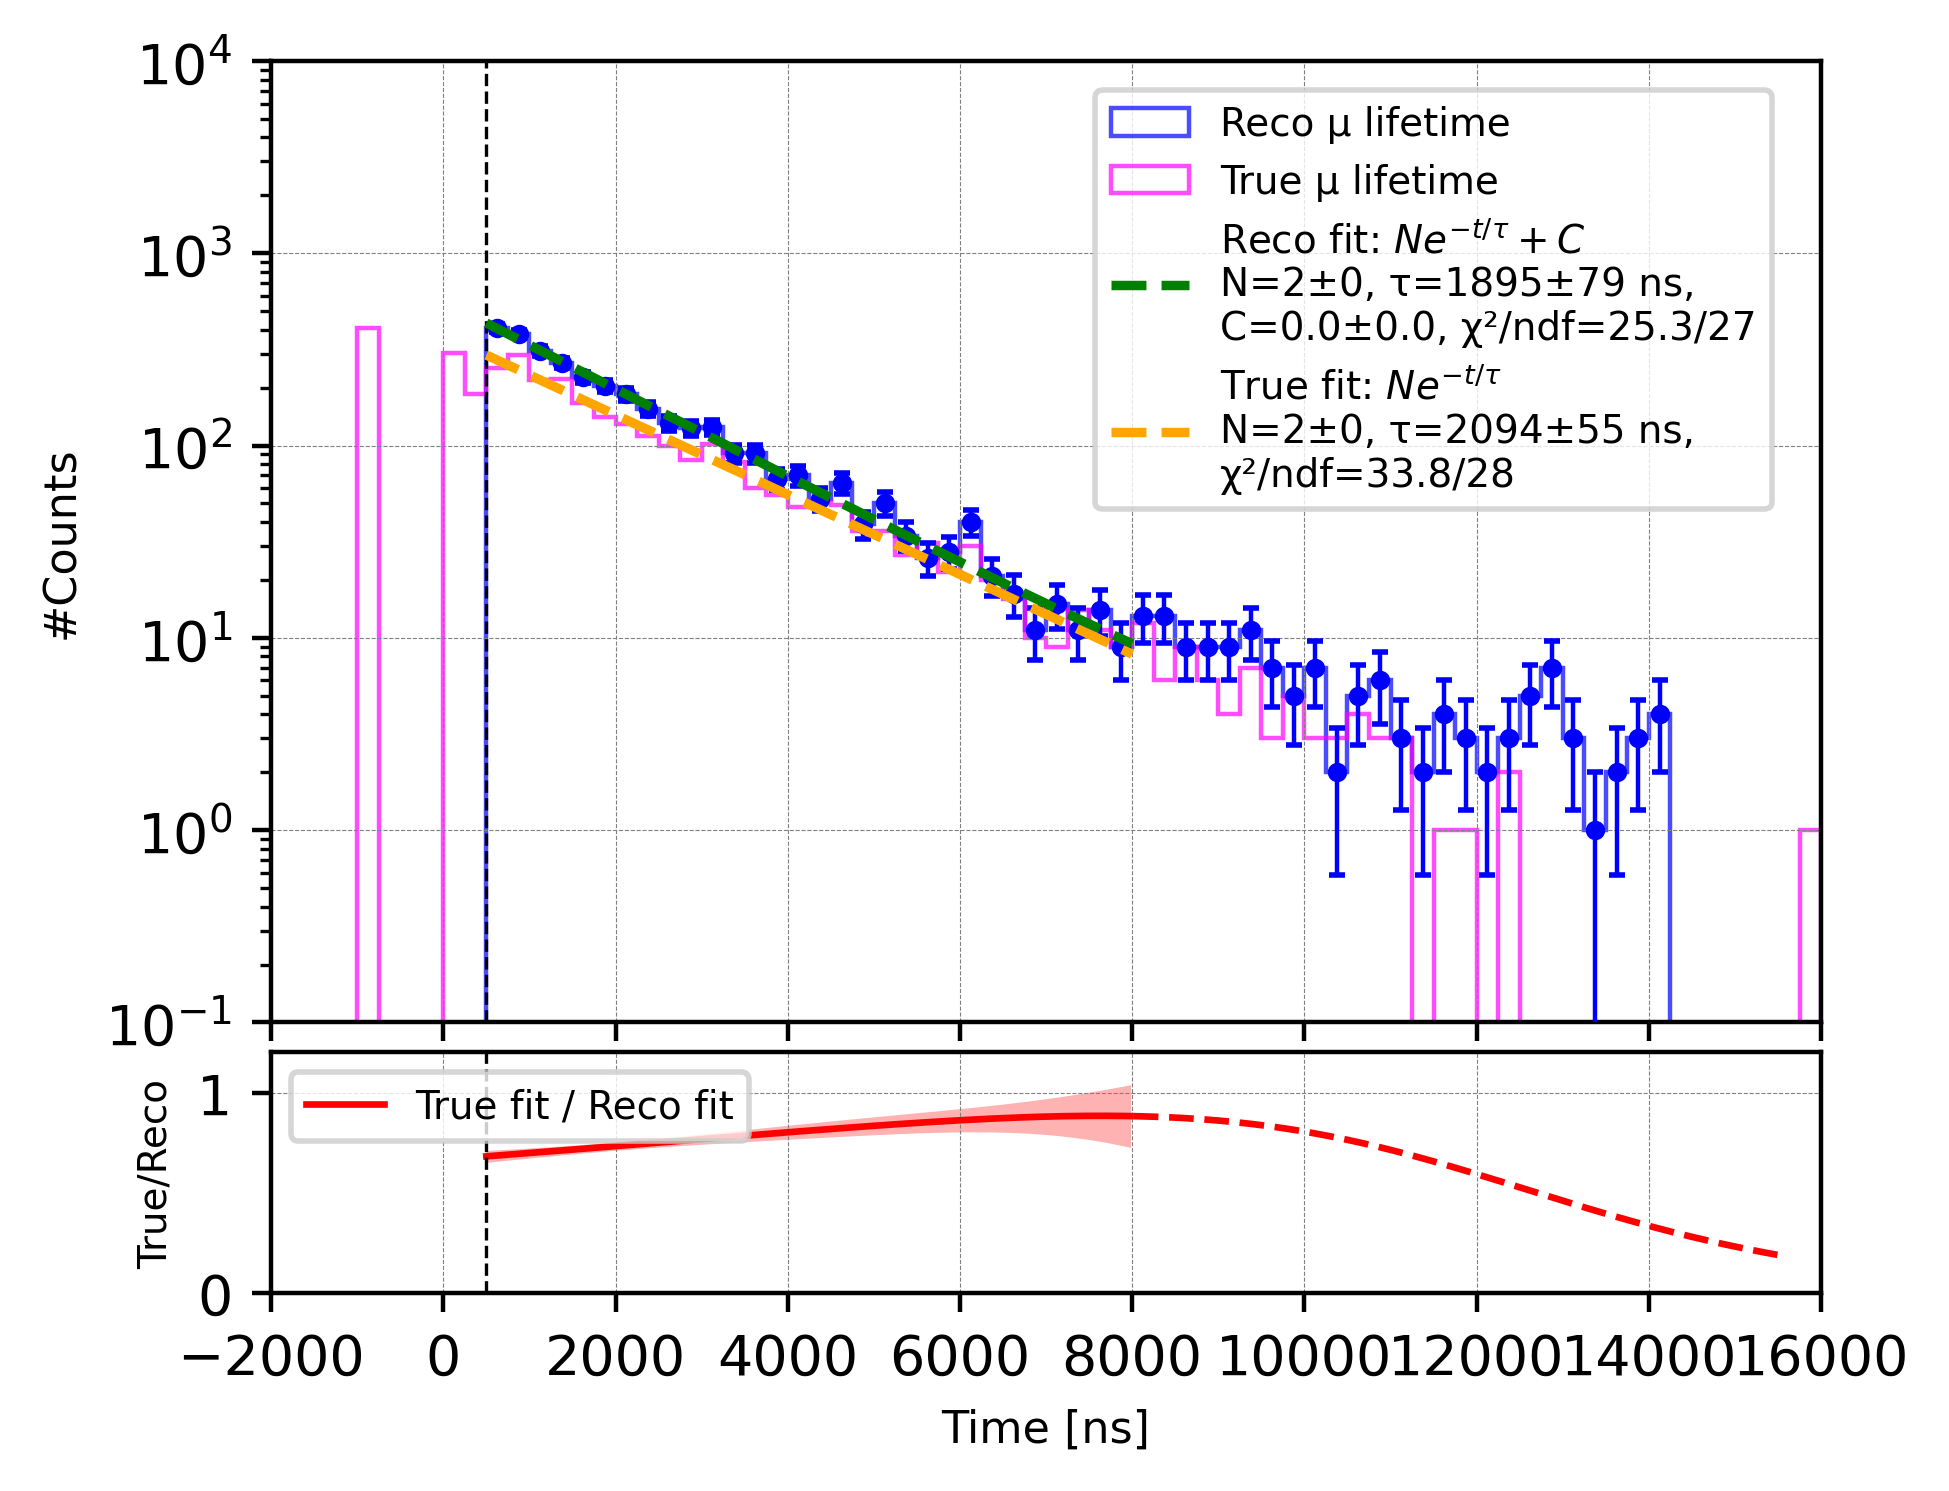

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec

#======Double Fitting with Ratio Panel==================================================
fig = plt.figure(figsize=(5, 4), dpi=400)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

# Histogram binning
bin_width = 250
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# --- Bin-integrated models ---
def exp1_integrated(edges, N, tau):
    a, b = edges[:-1], edges[1:]
    return N * tau * (np.exp(-a/tau) - np.exp(-b/tau))

def exp1C_integrated(edges, N, tau, C):
    a, b = edges[:-1], edges[1:]
    return N * tau * (np.exp(-a/tau) - np.exp(-b/tau)) + C * (b - a)

# --- Helpers ---
def _safe_sigma(y):
    return np.sqrt(np.clip(y, 1.0, None))

def numerical_grad(func, params, cov, x, h=1e-6):
    """Compute propagated uncertainty for func(x,*params) given parameter covariance."""
    f0 = func(x, *params)
    nparams = len(params)
    grads = np.zeros((nparams, len(x)))

    # finite difference for each parameter
    for i in range(nparams):
        dp = np.zeros_like(params, dtype=float)
        dp[i] = h * (abs(params[i]) + 1.0)
        f1 = func(x, *(params+dp))
        f2 = func(x, *(params-dp))
        grads[i] = (f1 - f2) / (2*dp[i])

    # propagate covariance: per point variance
    var = np.zeros(len(x))
    for k in range(len(x)):
        gk = grads[:, k]               # gradient at point k
        var[k] = gk @ cov @ gk         # g^T Cov g
    return np.sqrt(var)


# --- Reco fit: N*exp(-t/tau) + C ---
def fit_and_overlay_exp1C(ax, sample, label, fit_min, fit_max, color=None, line_style='--'):
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    m = (centers >= fit_min) & (centers <= fit_max)
    y = counts[m]

    if len(y) < 3 or y.sum() <= 0:
        return None, None, None, None

    edges_fit = bin_edges[np.where(m)[0][0] : np.where(m)[0][-1] + 2]
    sigma = _safe_sigma(y)

    N0 = np.sum(y); tau0 = 2000.0; C0 = np.min(y)/max(bin_width,1)
    p0 = [N0, tau0, C0]

    popt, pcov = curve_fit(
        lambda e, N, tau, C: exp1C_integrated(e, N, tau, C),
        edges_fit, y, p0=p0, sigma=sigma,
        absolute_sigma=True, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))

    chi2 = np.sum(((y - exp1C_integrated(edges_fit, *popt))/sigma)**2)
    ndf = len(y) - len(popt)

    t_smooth = np.linspace(fit_min, fit_max, 400)
    y_smooth = popt[0]*np.exp(-t_smooth/popt[1])*bin_width + popt[2]*bin_width

    ax.plot(t_smooth, y_smooth, line_style, linewidth=1.7, color=color, zorder=5,
            label=(rf"{label} fit: $Ne^{{-t/\tau}} + C$"
                   f"\nN={popt[0]:.0f}±{perr[0]:.0f}, "
                   f"τ={popt[1]:.0f}±{perr[1]:.0f} ns, "
                   f"\nC={popt[2]:.1f}±{perr[2]:.1f}, "
                   f"χ²/ndf={chi2:.1f}/{ndf}"))

    return t_smooth, y_smooth, popt, pcov

# --- True fit: N*exp(-t/tau) ---
def fit_and_overlay_exp1(ax, sample, label, fit_min, fit_max, color=None):
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    m = (centers >= fit_min) & (centers <= fit_max)
    y = counts[m]

    if len(y) < 3 or y.sum() <= 0:
        return None, None, None, None

    edges_fit = bin_edges[np.where(m)[0][0] : np.where(m)[0][-1] + 2]
    sigma = _safe_sigma(y)

    N0 = np.sum(y); tau0 = 2000.0
    p0 = [N0, tau0]

    popt, pcov = curve_fit(
        lambda e, N, tau: exp1_integrated(e, N, tau),
        edges_fit, y, p0=p0, sigma=sigma,
        absolute_sigma=True, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))

    chi2 = np.sum(((y - exp1_integrated(edges_fit, *popt))/sigma)**2)
    ndf = len(y) - len(popt)

    t_smooth = np.linspace(fit_min, fit_max, 400)
    y_smooth = popt[0]*np.exp(-t_smooth/popt[1])*bin_width

    ax.plot(t_smooth, y_smooth, linestyle='--', linewidth=1.7, color=color, zorder=5,
            label=(rf"{label} fit: $Ne^{{-t/\tau}}$"
                   f"\nN={popt[0]:.0f}±{perr[0]:.0f}, "
                   f"τ={popt[1]:.0f}±{perr[1]:.0f} ns, "
                   f"\nχ²/ndf={chi2:.1f}/{ndf}"))

    return t_smooth, y_smooth, popt, pcov

# -------- Top panel --------
ax1 = fig.add_subplot(gs[0])

# Histograms (faint outlines) + errors
counts_reco, bin_edges_reco, _ = ax1.hist(
    lifetime_reco_update2, bins=bins, range=(range_min, range_max),
    edgecolor='blue', histtype='step', linewidth=0.8, alpha=0.7,
    label='Reco μ lifetime', zorder=1
)
bin_centers_reco = 0.5*(bin_edges_reco[:-1]+bin_edges_reco[1:])
ax1.errorbar(bin_centers_reco, counts_reco,
             yerr=np.sqrt(np.clip(counts_reco,0,None)),
             fmt='o', color='blue', markersize=2.5,
             elinewidth=0.8, capsize=1.5, zorder=3)

ax1.hist(lifetime_update_ns2, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=0.8,
         alpha=0.7, label='True μ lifetime', zorder=1)

# Fits
t_reco, fit_reco, popt_reco, pcov_reco = fit_and_overlay_exp1C(ax1, lifetime_reco_update2, "Reco",
                                                               500, 8000, color="green")
t_true, fit_true, popt_true, pcov_true = fit_and_overlay_exp1(ax1, lifetime_update_ns2, "True",
                                                              500, 8000, color="orange")

# Style
ax1.set_xlim(-2000, 16000)
ax1.tick_params(labelbottom=False)
ax1.set_ylim(0.1, 10000)
ax1.set_yscale('log')
ax1.axvline(x=500, color='black', linestyle='--', linewidth=0.6)
ax1.set_ylabel('#Counts', fontsize=8)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax1.legend(loc='upper center', bbox_to_anchor=(0.75, 0.99),
           fontsize=8, markerscale=5, ncol=1, prop={'size':7})

# -------- Bottom panel (ratio) --------
ax2 = fig.add_subplot(gs[1], sharex=ax1)
if (popt_reco is not None) and (popt_true is not None):
    t_common = np.linspace(500, 15500, 400)

    f_reco = lambda x, N, tau, C: N*np.exp(-x/tau)*bin_width + C*bin_width
    f_true = lambda x, N, tau: N*np.exp(-x/tau)*bin_width

    fit_reco_common = f_reco(t_common, *popt_reco)
    fit_true_common = f_true(t_common, *popt_true)
    ratio = np.divide(fit_true_common, fit_reco_common,
                      out=np.zeros_like(fit_true_common),
                      where=(fit_reco_common>0))

    # --- Error bands (only valid in fit range ≤ 8000) ---
    sigma_true = numerical_grad(f_true, np.array(popt_true), pcov_true, t_common)
    sigma_reco = numerical_grad(f_reco, np.array(popt_reco), pcov_reco, t_common)
    sigma_ratio = np.sqrt((sigma_true/fit_reco_common)**2 +
                          (fit_true_common * sigma_reco / fit_reco_common**2)**2)

    mask_fit = t_common <= 8000
    mask_extrap = t_common > 8000

    # Plot ratio: solid inside fit range, dashed outside
    ax2.plot(t_common[mask_fit], ratio[mask_fit],
             color='red', linewidth=1.2, label='True fit / Reco fit')
    ax2.plot(t_common[mask_extrap], ratio[mask_extrap],
             color='red', linewidth=1.2, linestyle='--')

    # Fill band only in fit range
    ax2.fill_between(t_common[mask_fit],
                     ratio[mask_fit] - sigma_ratio[mask_fit],
                     ratio[mask_fit] + sigma_ratio[mask_fit],
                     color='red', alpha=0.3, linewidth=0)

ax2.axvline(x=500, color='black', linestyle='--', linewidth=0.6)
ax2.set_xlim(-2000, 16000)
ax2.set_ylim(0.0, 1.2)
ax2.set_xlabel('Time [ns]', fontsize=8)
ax2.set_ylabel('True/Reco', fontsize=7)
ax2.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax2.legend(fontsize=7, loc='upper left')

plt.show()


<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Explore Final Dataset (After purification 2):

In [11]:
@dataclass
class PdsEventNew: #new class containing reco lifetime, true lifetime & diff
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    energy: Optional[float] = None
    lifetime: Optional[float] = None #in unit of us---
    pdg: Optional[int] = None
    eventID: Optional[int] = None
    trackID: Optional[int] = None
    date: Optional[int] = None 
    reco_lifetime: Optional[float] = None
    true_lifetime: Optional[float] = None # in unit of ns---
    diff_lifetime: Optional[float] = None
    michel_rise: Optional[float] = None
    michel_drop: Optional[float] = None



#Test print---------------
print("Size of events_reco_update2 (previous class): ", len(events_reco_update2))

#New calculated reco & true lifetime lists:
recoLife_update2 = []
trueLife_update2 = []  
diffLife_update2 = []

michel_rise_slope = []
michel_drop_slope = []

for ev in events_reco_update2:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---

    recoLife_update2.append(timeDiff)
    trueLife_update2.append(ev.lifetime * 1000)
    diffLife_update2.append(timeDiff - ev.lifetime * 1000)

    left_slope = ev.mi_leftHeight / (miTime - ev.mi_leftTurn)
    right_slope = ev.mi_rightHeight / (ev.mi_rightTurn - miTime)

#    left_slope = (miTime - ev.mi_leftTurn)
#    right_slope = (ev.mi_rightTurn - miTime)

    michel_rise_slope.append(left_slope)
    michel_drop_slope.append(right_slope)

print("Size of lifetime_reco_update2               : ", len(recoLife_update2))
print("Size of lifetime_update_ns2                 : ", len(trueLife_update2))



#Final events with new features----------
events_newClass = []
for ev, reco_life, true_life, diff_life, rise, drop in zip(
    events_reco_update2, 
    recoLife_update2, 
    trueLife_update2, 
    diffLife_update2,
    michel_rise_slope,
    michel_drop_slope
    ):
    new_ev = PdsEventNew(
        muon_time=ev.muon_time,
        michel_time=ev.michel_time,
        muon_intensity=ev.muon_intensity,
        michel_intensity=ev.michel_intensity,
        posX=ev.posX,
        posY=ev.posY,
        posZ=ev.posZ,
        energy=ev.energy,
        lifetime=ev.lifetime,
        pdg=ev.pdg,
        eventID=ev.eventID,
        trackID=ev.trackID,
        date=ev.date,
        reco_lifetime=reco_life,
        true_lifetime=true_life,
        diff_lifetime=diff_life,
        michel_rise=rise,
        michel_drop=drop
    )
    events_newClass.append(new_ev)

print("\nLength of final dataset in format of new class: ", len(events_newClass))


true_newClass = []
for ev in events_newClass:
    if ev.energy > 0:
        true_newClass.append(ev)

print("\nLength of final true in format of new class: ", len(true_newClass))

Size of events_reco_update2 (previous class):  3411
Size of lifetime_reco_update2               :  3411
Size of lifetime_update_ns2                 :  3411

Length of final dataset in format of new class:  3411

Length of final true in format of new class:  3003


### Space Distribution:


Decay points distribution: 

# of X < 0 :  749 (21.958%)
# of X >= 0:  2662 (78.042%)


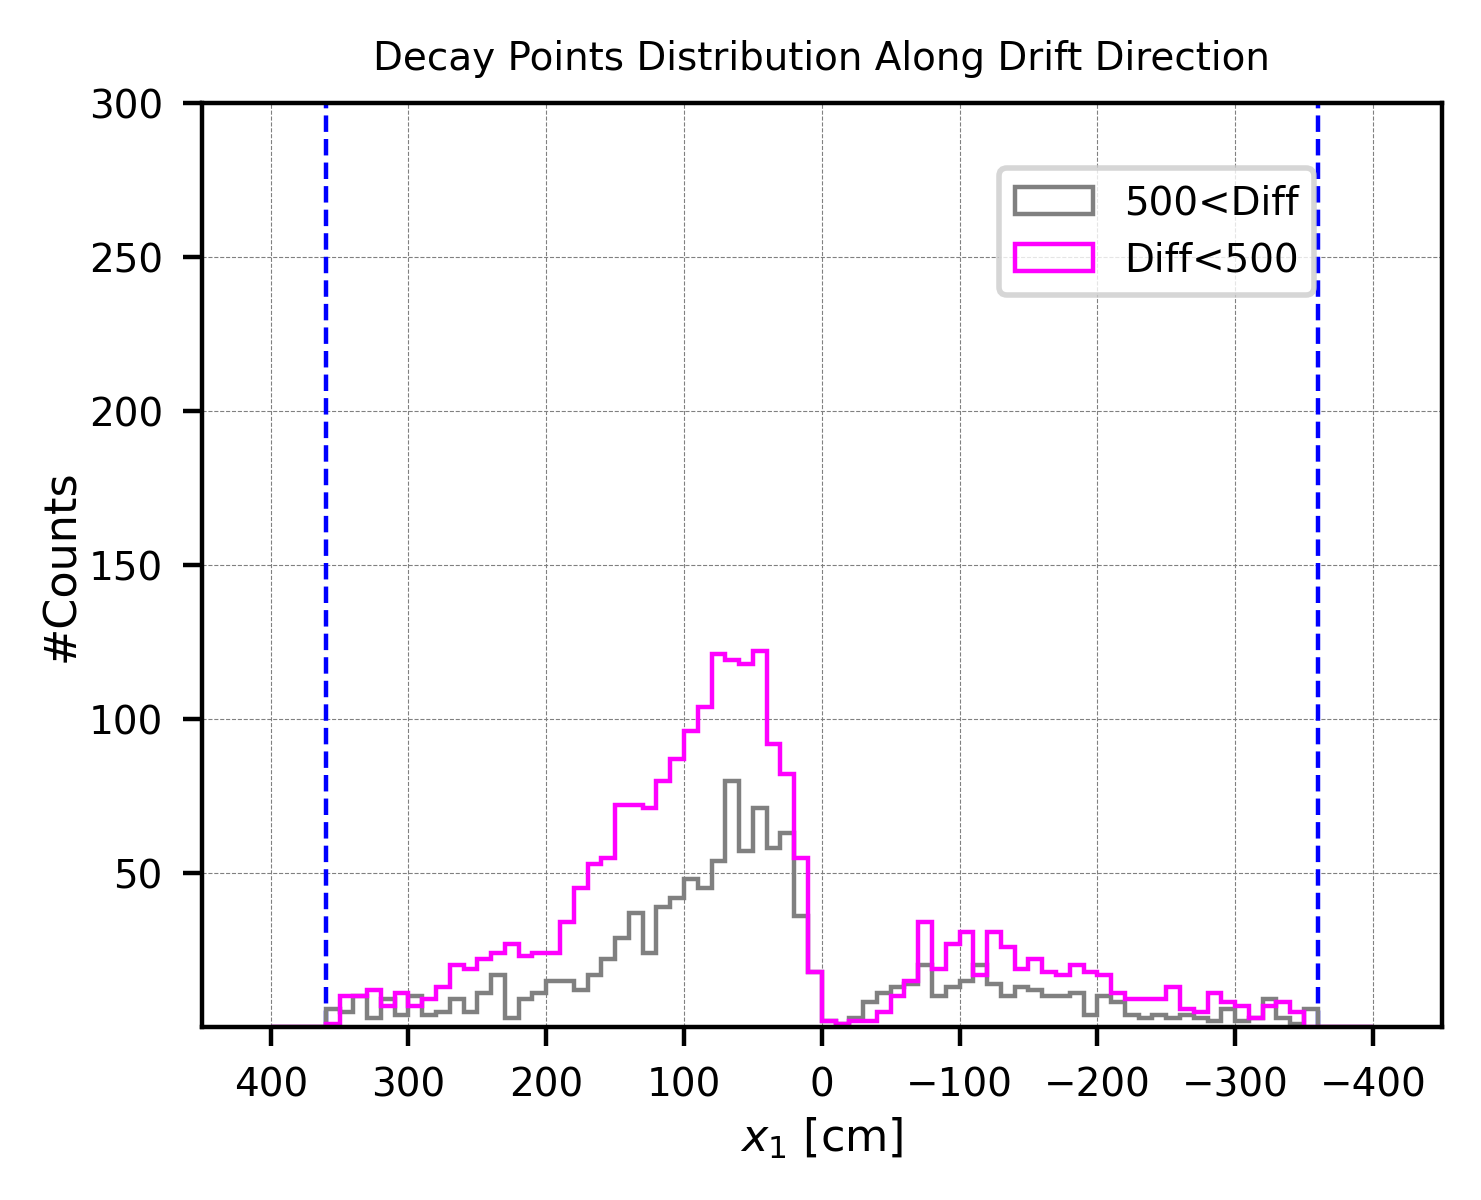

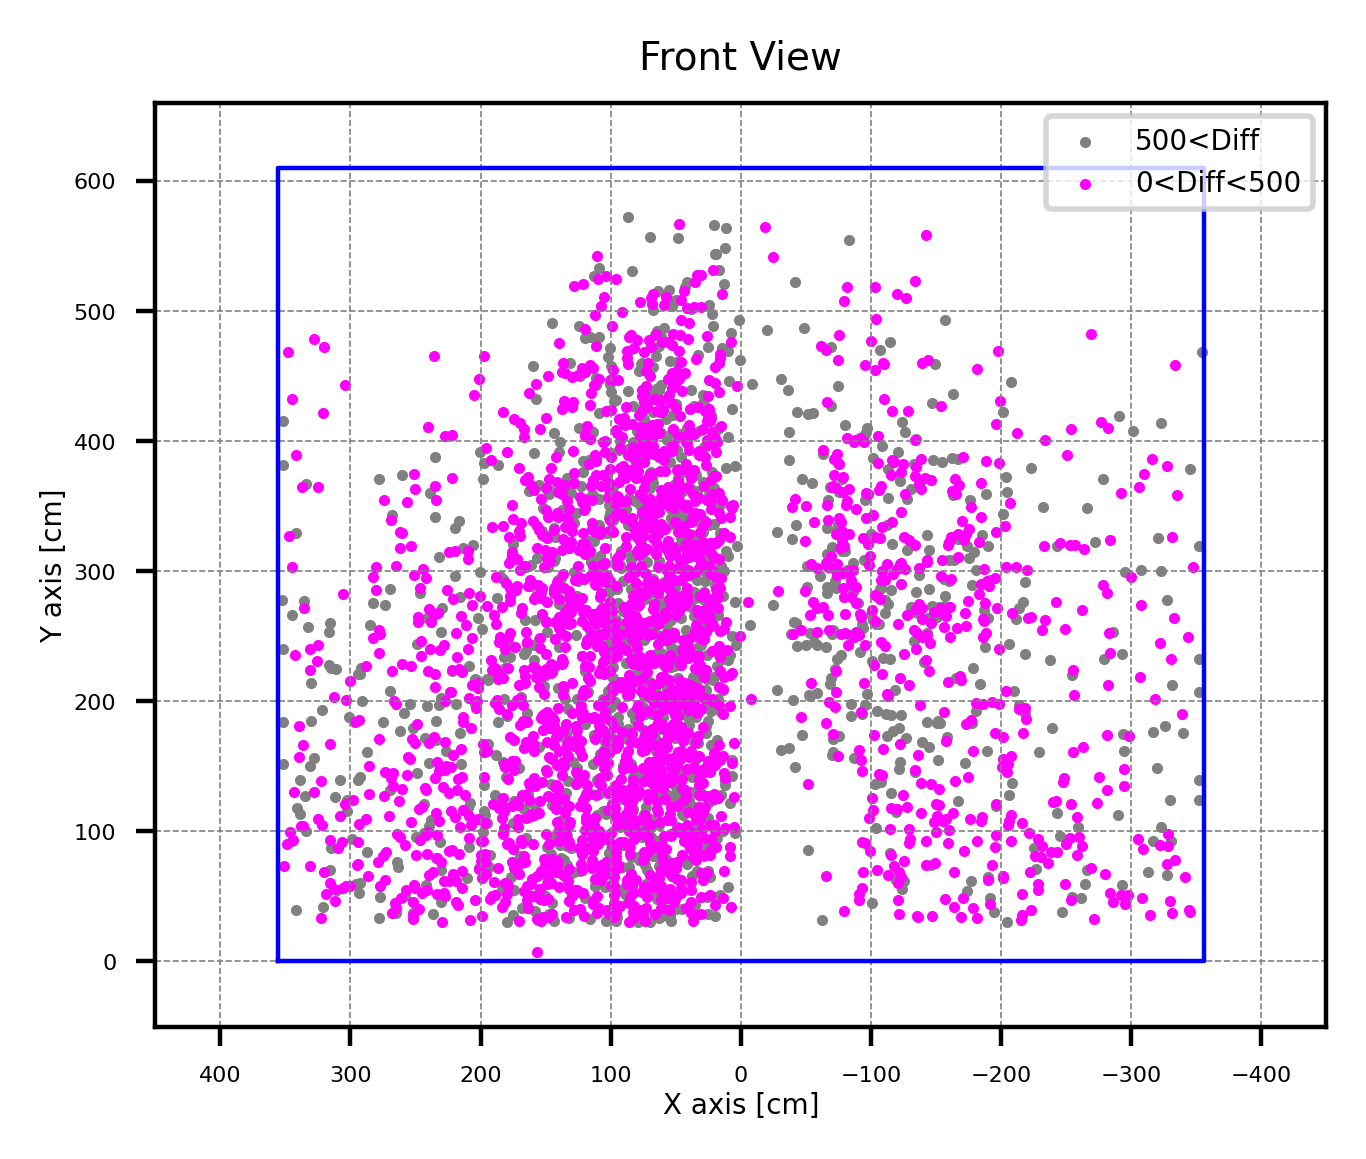

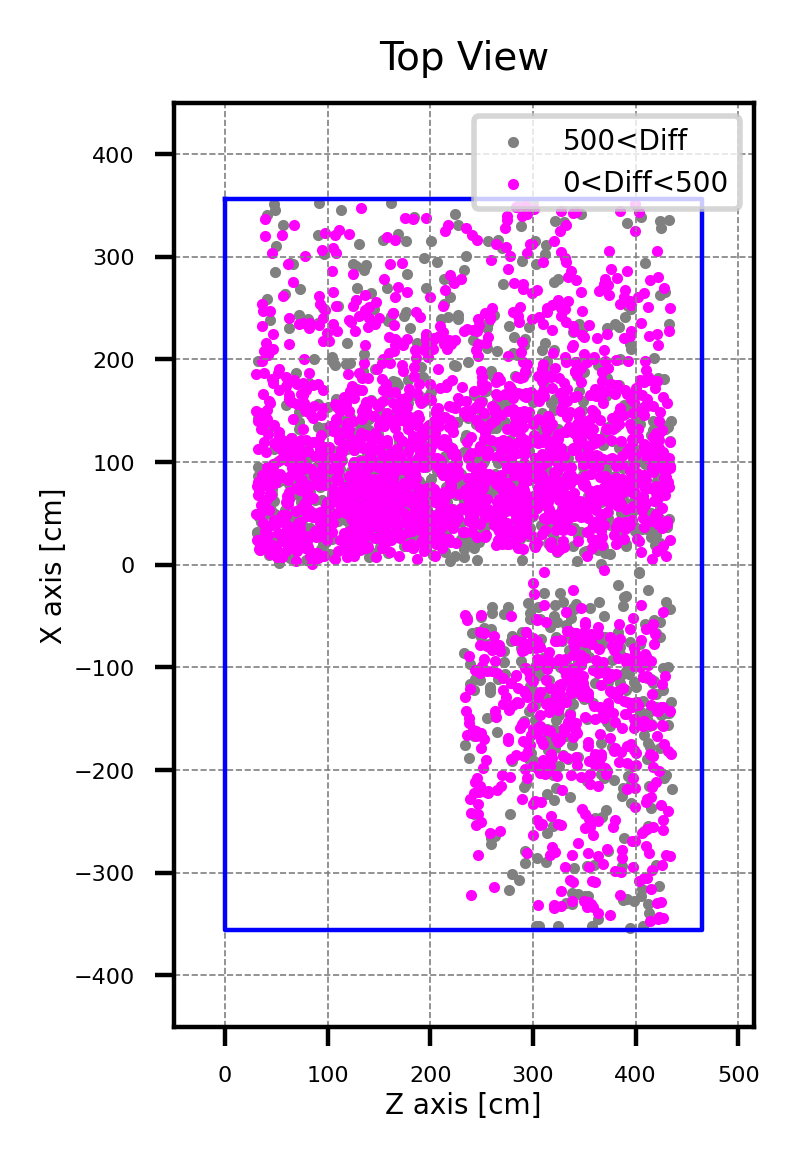

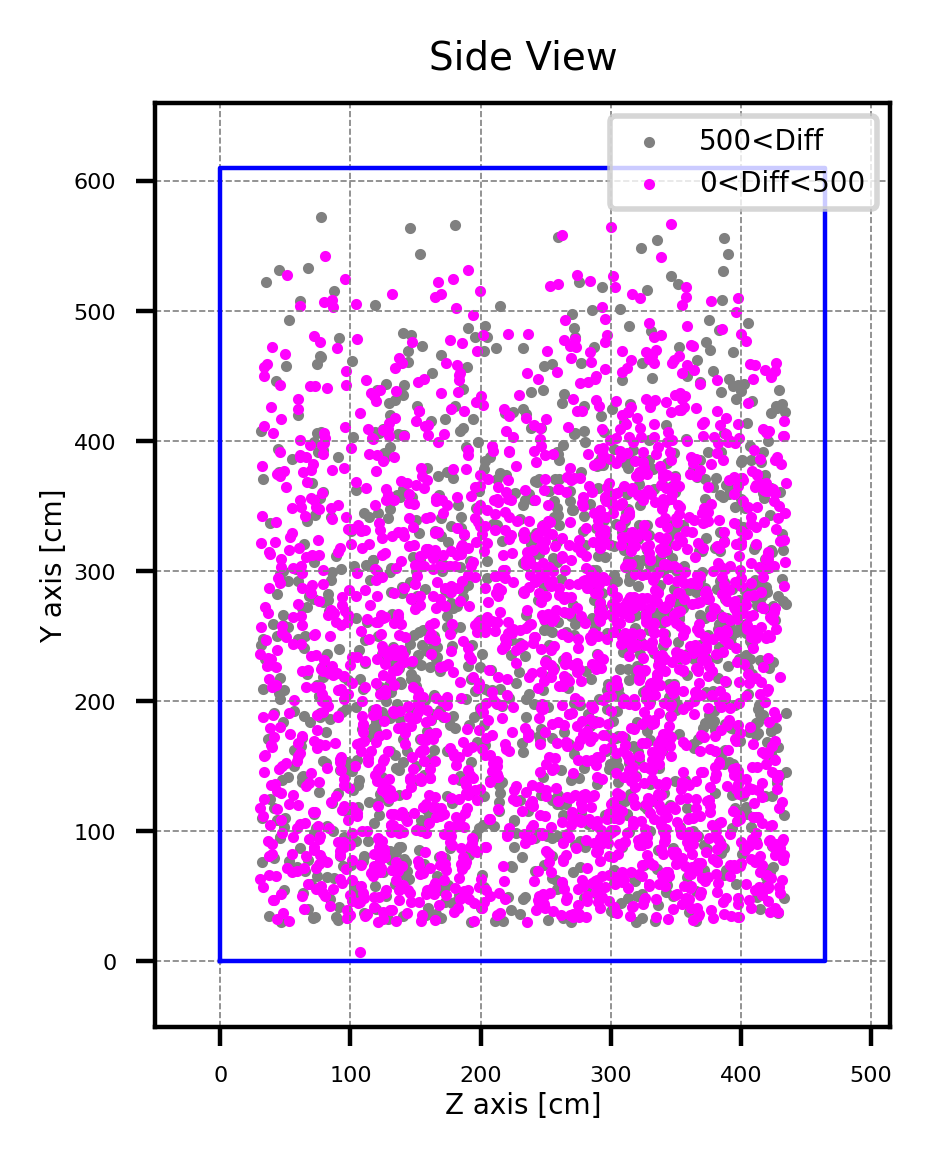

In [12]:
muon_time = [ev.posX for ev in events_reco_initial]

#"Reco" final events---
final_posX = [ev.posX for ev in events_newClass]
final_posY = [ev.posY for ev in events_newClass]
final_posZ = [ev.posZ for ev in events_newClass]

#"True" final events---
true_posX = [ev.posX for ev in true_newClass]


events_true500 = []
events_true0 = []
events_false = []
events_diff500 = []
events_diff0 = [] #events with diff>500
for ev in events_newClass:
    trueL = ev.true_lifetime
    diff = ev.diff_lifetime

    if 500 < trueL:
        events_true500.append(ev)
    elif 0 < trueL <= 500:
        events_true0.append(ev)
    elif trueL <= 0:
        events_false.append(ev)

    if 500 < abs(diff):
        events_diff500.append(ev)
    else: #abs(diff) <= 500:
        events_diff0.append(ev)

posX_true500 = [ev.posX for ev in events_true500]
posY_true500 = [ev.posY for ev in events_true500]
posZ_true500 = [ev.posZ for ev in events_true500]

posX_true0 = [ev.posX for ev in events_true0]
posY_true0 = [ev.posY for ev in events_true0]
posZ_true0 = [ev.posZ for ev in events_true0]

posX_false = [ev.posX for ev in events_false]
posY_false = [ev.posY for ev in events_false]
posZ_false = [ev.posZ for ev in events_false]

posX_diff500 = [ev.posX for ev in events_diff500]
posY_diff500 = [ev.posY for ev in events_diff500]
posZ_diff500 = [ev.posZ for ev in events_diff500]


posX_diff0 = [ev.posX for ev in events_diff0]
posY_diff0 = [ev.posY for ev in events_diff0]
posZ_diff0 = [ev.posZ for ev in events_diff0]



#Decay points distribution:==========================================
print("\nDecay points distribution: ")

decayX_initial = np.array(final_posX)
neg_X = np.sum(decayX_initial < 0)
pos_X = np.sum(decayX_initial >= 0)
print("\n# of X < 0 : ", neg_X, "({:.3f}%)".format(neg_X/len(decayX_initial)*100))
print("# of X >= 0: ", pos_X, "({:.3f}%)".format(pos_X/len(decayX_initial)*100))


# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
# plt.hist(posX_true500, bins=bins, range=(range_min, range_max), edgecolor='red', 
#          histtype='step', linewidth=0.8, label="500<True")
# plt.hist(posX_true0, bins=bins, range=(range_min, range_max), edgecolor='blue', 
#          histtype='step', linewidth=0.8, label="0<True<500")
# plt.hist(posX_false, bins=bins, range=(range_min, range_max), edgecolor='black', 
#          histtype='step', linewidth=0.8, label="True<0 (False)")

plt.hist(posX_diff500, bins=bins, range=(range_min, range_max), edgecolor='grey', 
          histtype='step', linewidth=0.8, label="500<Diff")
plt.hist(posX_diff0, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
          histtype='step', linewidth=0.8, label="Diff<500")
#--------------------------------

plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  







# Set the limits of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

# Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


# ==========================================================
# Y–X plane plotting (Front View)
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Auxiliary line for field cage
aux2 = [0, 610, 610, 0, 0]
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Scatter plot----------
# plt.scatter(posX_true500, posY_true500, s=1, c='red', alpha=1.0, label="500<True")
# plt.scatter(posX_true0, posY_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# plt.scatter(posX_false, posY_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

plt.scatter(posX_diff500, posY_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
plt.scatter(posX_diff0, posY_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
#-----------------------

plt.axis('scaled')
plt.xlim(xmin, xmax)
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(fontsize=5, loc="upper right")
plt.show()


# ==========================================================
# Z–X plane plotting (Top View)
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Auxiliary line
aux1 = [0, 465, 465, 0, 0]
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Scatter plot----------
# plt.scatter(posZ_true500, posX_true500, s=1, c='red', alpha=1.0, label="500<True")
# plt.scatter(posZ_true0, posX_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# plt.scatter(posZ_false, posX_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

plt.scatter(posZ_diff500, posX_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
plt.scatter(posZ_diff0, posX_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
#-----------------------

plt.axis('scaled')
plt.ylim(xmin, xmax)
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(fontsize=5, loc="upper right")
plt.show()


# ==========================================================
# Y–Z plane plotting (Side View)
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Auxiliary line
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY]
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Scatter plot----------
# plt.scatter(posZ_true500, posY_true500, s=1, c='red', alpha=1.0, label="500<True")
# plt.scatter(posZ_true0, posY_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# plt.scatter(posZ_false, posY_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

plt.scatter(posZ_diff500, posY_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
plt.scatter(posZ_diff0, posY_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
#-----------------------

plt.axis('scaled')
plt.xlim(-50, 515)
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(fontsize=5, loc="upper right")
plt.show()


### Lifetime & Energy of True Michels:


Michel e^+:  2564 / 3003 (85.38%)
Michel e^-:  439 / 3003 (14.62%)
#e^+ / #e^-:  2564 / 439 (5.84)


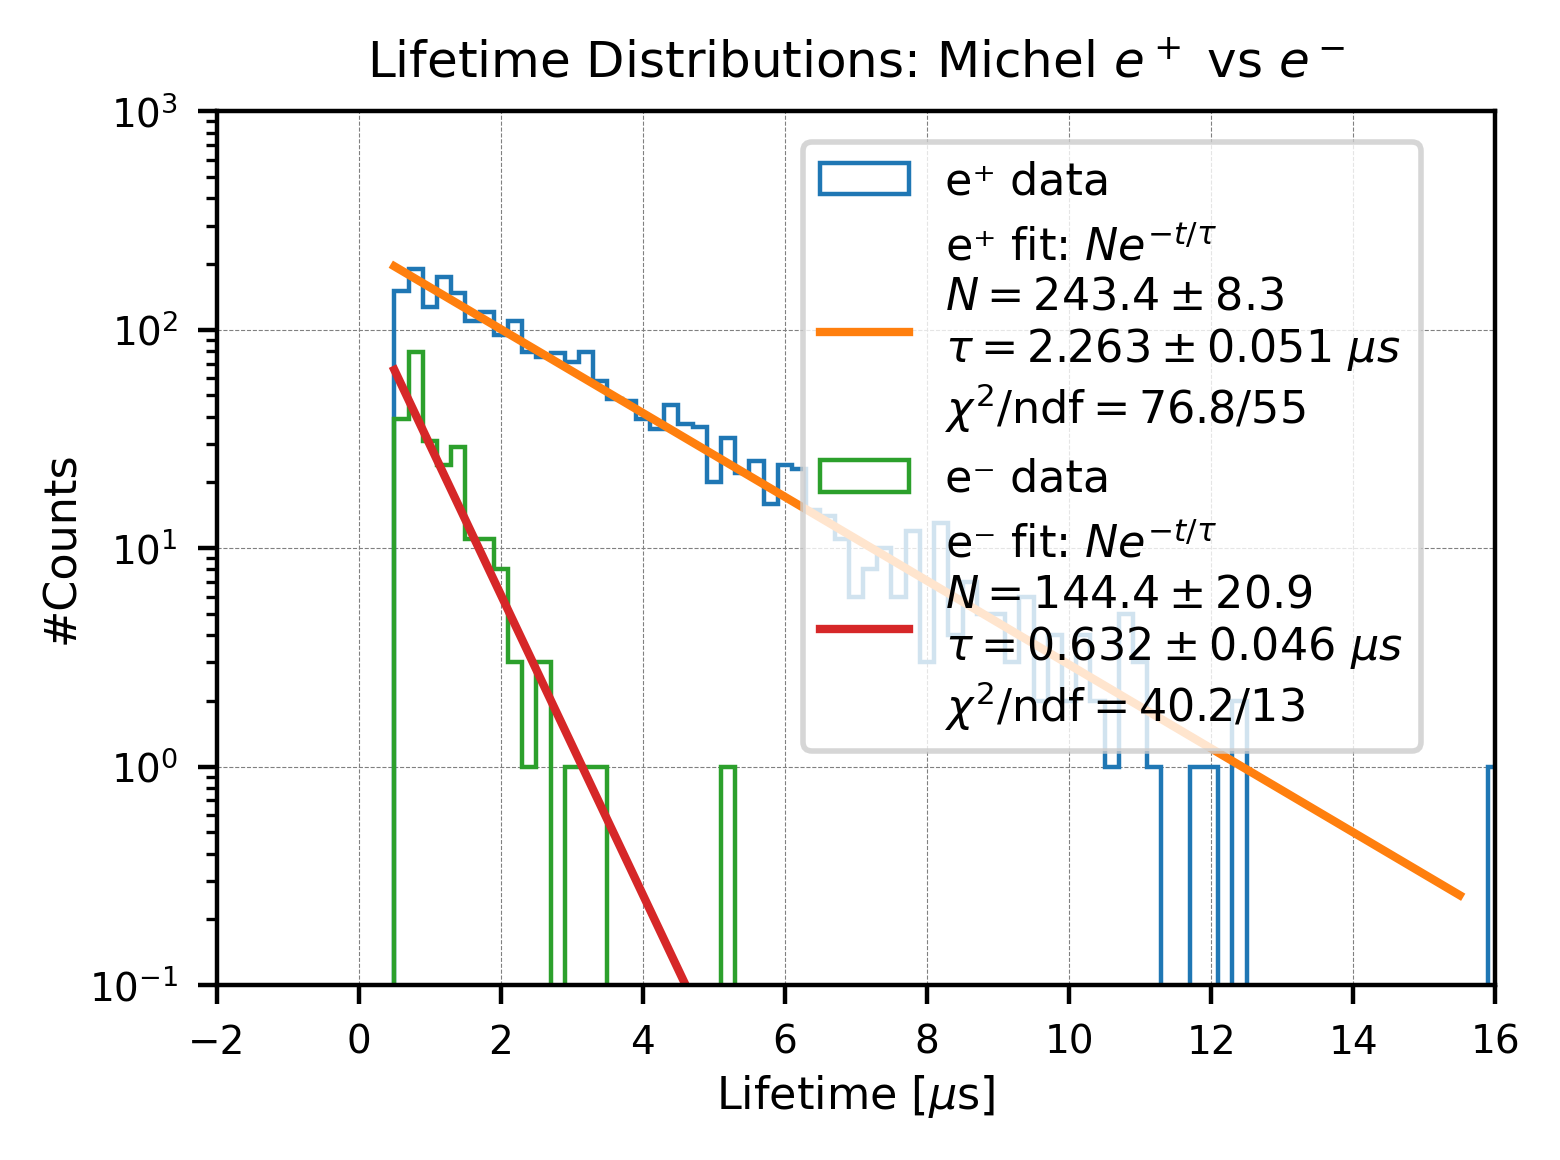

In [25]:

energyDis = [ev.energy for ev in true_newClass]


# Seperate Michel e^- and e^+------------------------------
life_positron = []
life_electron = []

for ev in true_newClass:
    pdg = ev.pdg
    life = ev.true_lifetime / 1000.0 # in unit of us---

    if pdg < 0:
        life_positron.append(life)
    elif pdg > 0:
        life_electron.append(life)

print("\nMichel e^+: ", len(life_positron), "/", len(true_newClass), 
      "({:.2f}%)".format(len(life_positron)/len(true_newClass)*100))
print("Michel e^-: ", len(life_electron), "/", len(true_newClass), 
      "({:.2f}%)".format(len(life_electron)/len(true_newClass)*100))
print("#e^+ / #e^-: ", len(life_positron), "/", len(life_electron),
      "({:.2f})".format(len(life_positron)/len(life_electron)))



#Fitting seperating for Michel e^+ and e^-=============================================================

# --- single exponential ---
def exp1(t, N, tau):
    return N * np.exp(-t / tau)

# --- plotting / binning setup ---
plt.figure(figsize=(4, 3), dpi=400)
bin_width = 0.2
range_min, range_max = 0.5, 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

# --- helper: weighted fit (σ = sqrt(y)), skip zeros, draw ---
def fit_and_draw(sample, label_prefix, fit_range=(0.5, 15.5)):#Fitting range here![us]----
    # histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # choose fit window & drop zero bins
    m = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1])
    x_all = bin_centers[m]
    y_all = counts[m]
    nz = y_all > 0
    x_fit = x_all[nz]
    y_fit = y_all[nz]

    # abort gracefully if too few points
    if len(y_fit) < 3:
        plt.hist(sample, bins=bins, range=(range_min, range_max),
                 histtype='step', linewidth=0.8, label=f"{label_prefix} MC data")
        return (np.nan, np.nan, np.nan, np.nan, np.nan)

    sigma = np.sqrt(y_fit)

    # safe initial guesses & bounds
    N0, tau0 = float(np.max(y_fit)), 2.0
    bounds = ([0.0, 1e-6], [np.inf, np.inf])

    # weighted least squares
    popt, pcov = curve_fit(
        exp1, x_fit, y_fit, p0=[N0, tau0],
        sigma=sigma, absolute_sigma=True,
        bounds=bounds, maxfev=20000
    )
    N_fit, tau_fit = popt
    N_err, tau_err = np.sqrt(np.diag(pcov))

    # chi2/ndf
    y_mod = exp1(x_fit, *popt)
    r = (y_fit - y_mod) / sigma
    chi2 = float(np.sum(r**2))
    ndf = max(len(x_fit) - len(popt), 1)
    chi2_ndf = chi2 / ndf

    # smooth curve
    x_smooth = np.linspace(fit_range[0], fit_range[1], 500)
    y_smooth = exp1(x_smooth, *popt)

    # draw histogram (step)
    plt.hist(sample, bins=bins, range=(range_min, range_max),
             histtype='step', linewidth=0.8, label=f"{label_prefix} data")

    # draw fit
    plt.plot(
        x_smooth, y_smooth,
        label=(fr"{label_prefix} fit: $Ne^{{-t/\tau}}$" + "\n"
               + rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
               + rf"$\tau={tau_fit:.3f}\pm{tau_err:.3f}\ \mu s$" + "\n"
               + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$")
    )

    return (N_fit, tau_fit, N_err, tau_err, chi2_ndf)

# ---- run for both lists ----
N_p, tau_p, dN_p, dtau_p, chi2ndf_p = fit_and_draw(np.asarray(life_positron), "e⁺")
N_n, tau_n, dN_n, dtau_n, chi2ndf_n = fit_and_draw(np.asarray(life_electron), "e⁻")

# --- final plot cosmetics (kept similar to your style) ---
plt.xlim(-2, 16)
plt.ylim(0.1, 1000)
plt.yscale('log')
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distributions: Michel $e^+$ vs $e^-$', fontsize=9)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=9, ncol=1, prop={'size': 8})
plt.tight_layout()
plt.show()












#### Bin-integrated fittings: (Best)

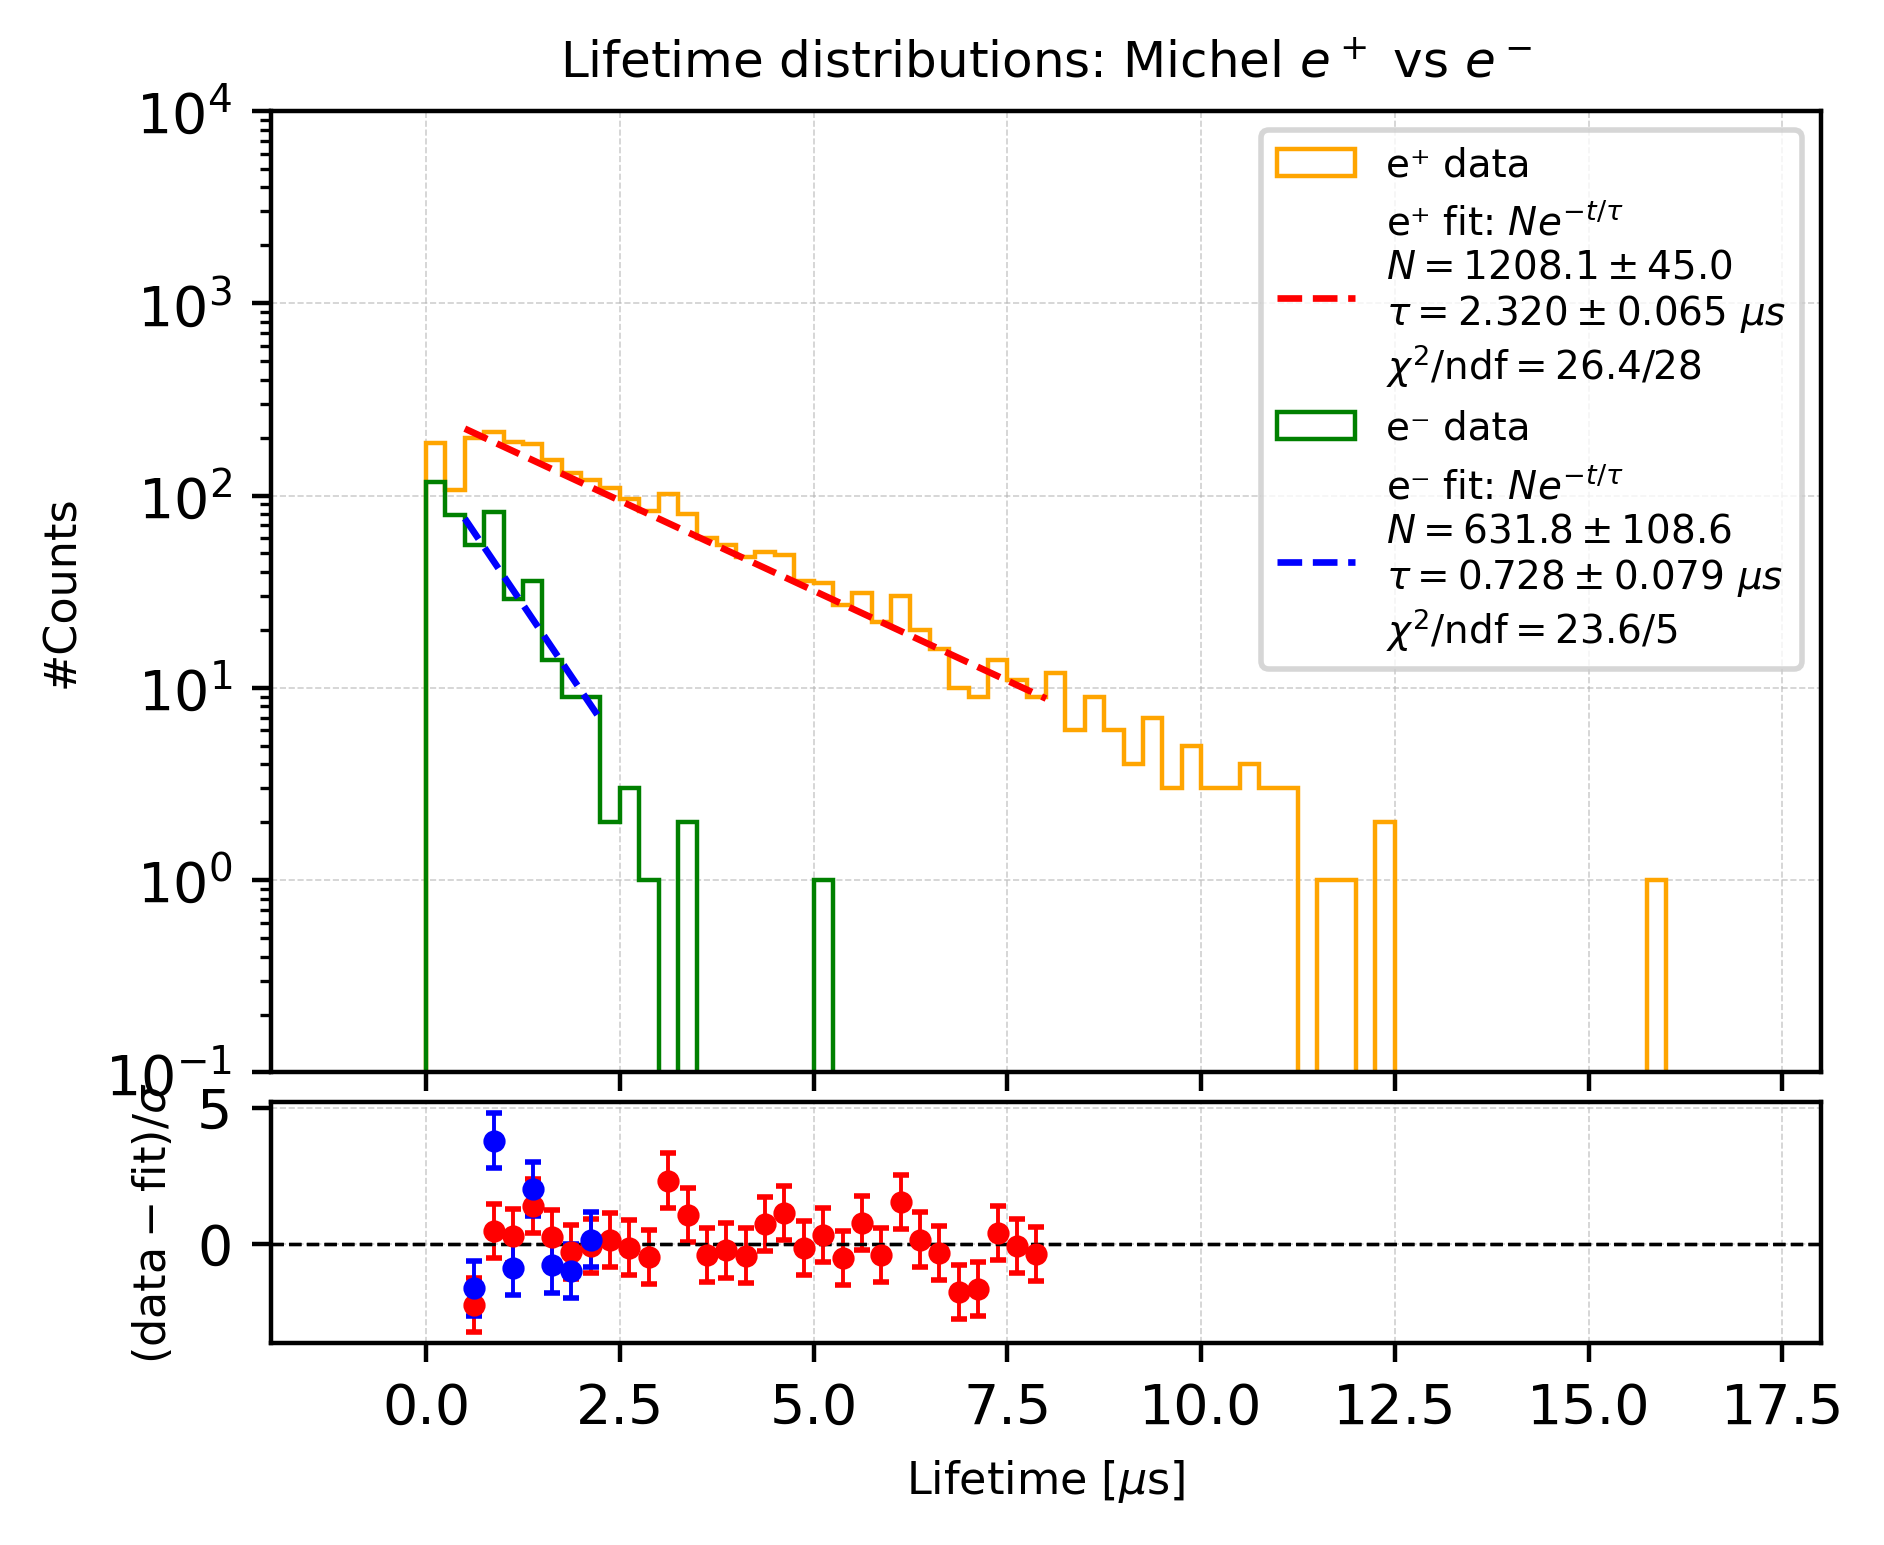


Bin contents for e⁺:
  Bin [0.00, 0.25] (center=0.12): 187
  Bin [0.25, 0.50] (center=0.38): 107
  Bin [0.50, 0.75] (center=0.62): 199
  Bin [0.75, 1.00] (center=0.88): 214
  Bin [1.00, 1.25] (center=1.12): 190
  Bin [1.25, 1.50] (center=1.38): 186
  Bin [1.50, 1.75] (center=1.62): 153
  Bin [1.75, 2.00] (center=1.88): 131
  Bin [2.00, 2.25] (center=2.12): 120
  Bin [2.25, 2.50] (center=2.38): 110
  Bin [2.50, 2.75] (center=2.62): 96
  Bin [2.75, 3.00] (center=2.88): 83
  Bin [3.00, 3.25] (center=3.12): 102
  Bin [3.25, 3.50] (center=3.38): 80
  Bin [3.50, 3.75] (center=3.62): 60
  Bin [3.75, 4.00] (center=3.88): 55
  Bin [4.00, 4.25] (center=4.12): 48
  Bin [4.25, 4.50] (center=4.38): 51
  Bin [4.50, 4.75] (center=4.62): 49
  Bin [4.75, 5.00] (center=4.88): 36
  Bin [5.00, 5.25] (center=5.12): 35
  Bin [5.25, 5.50] (center=5.38): 27
  Bin [5.50, 5.75] (center=5.62): 31
  Bin [5.75, 6.00] (center=5.88): 22
  Bin [6.00, 6.25] (center=6.12): 30
  Bin [6.25, 6.50] (center=6.38): 20
  Bin

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec

# --- bin-integrated exponential model ---
def exp1_integrated(bin_edges, N, tau):
    """
    Predict counts in each bin [a,b] using the integral of N*exp(-t/tau).
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]
    return N * tau * (np.exp(-a/tau) - np.exp(-b/tau))

# --- fitting helper (χ² least squares with bin integration) ---
def fit_and_draw(ax, ax_resid, sample, label_prefix, fit_range=(0.05, 15.5),
                 hist_color="orange", fit_color="red"):
    # histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # fit window mask
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m]
    edges_fit = bin_edges[m.nonzero()[0][0] : m.nonzero()[0][-1] + 2]  # edges covering fit window

    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8,
                label=f"{label_prefix} data", color=hist_color)
        return None

    sigma = np.sqrt(np.maximum(y, 1.0))

    # fit using integrated model
    N0, tau0 = np.sum(y), 2.0
    popt, pcov = curve_fit(
        lambda edges, N, tau: exp1_integrated(edges, N, tau),
        edges_fit, y,
        p0=[N0, tau0], sigma=sigma, absolute_sigma=True,
        bounds=([0, 1e-6], [np.inf, np.inf]), maxfev=20000
    )
    N_fit, tau_fit = popt
    N_err, tau_err = np.sqrt(np.diag(pcov))

    # chi²/ndf
    y_model = exp1_integrated(edges_fit, *popt)
    pulls = (y - y_model) / sigma
    chi2 = np.sum(pulls**2)
    ndf = len(y) - len(popt)

    # smooth fit curve (Option B: scaled PDF)
    N_tot = np.sum(counts)   # total entries in histogram
    x_smooth = np.linspace(fit_range[0], fit_range[1], 400)
    y_smooth = (N_tot/tau_fit) * np.exp(-x_smooth/tau_fit) * bin_width

    # draw histogram
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8,
            label=f"{label_prefix} data", color=hist_color)

    # draw smooth fit curve
    ax.plot(x_smooth, y_smooth,
            label=(fr"{label_prefix} fit: $Ne^{{-t/\tau}}$" + "\n"
                   + rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
                   + rf"$\tau={tau_fit:.3f}\pm{tau_err:.3f}\ \mu s$" + "\n"
                   + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$"),
            color=fit_color, linestyle="--", linewidth=1.2)

    # residuals (pulls)
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    bin_centers_fit = 0.5 * (edges_fit[:-1] + edges_fit[1:])
    ax_resid.errorbar(bin_centers_fit, pulls, yerr=np.ones_like(pulls), fmt='o',
                      color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5)

    return tau_fit, tau_err, chi2, ndf


# ----------------------------------------------------
# Plot with residuals panel
# ----------------------------------------------------
bin_width = 0.25
range_min, range_max = 0.0, 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

# Fit e+ (orange hist, red fit) and e- (green hist, blue fit)
fit_and_draw(ax, ax_resid, np.asarray(life_positron), "e⁺",
             fit_range=(0.5, 8.0), hist_color="orange", fit_color="red")
fit_and_draw(ax, ax_resid, np.asarray(life_electron), "e⁻",
             fit_range=(0.5, 2.25), hist_color="green", fit_color="blue")

# Style top plot
ax.set_ylim(0.1, 10000)
ax.set_yscale("log")
ax.tick_params(labelbottom=False)
ax.set_xlabel("")
ax.set_ylabel("#Counts", fontsize=8)
ax.set_title("Lifetime distributions: Michel $e^+$ vs $e^-$", fontsize=9)
ax.legend(fontsize=7)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

# Style residuals
ax_resid.set_xlim(-2, 18)
ax_resid.set_xlabel("Lifetime [$\mu$s]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data} - \mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()







# ----------------------------------------------------
# Print bin contents for both histograms
# ----------------------------------------------------
def print_bin_contents(sample, label):
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    print(f"\nBin contents for {label}:")
    for c, xlow, xhigh, center in zip(counts, bin_edges[:-1], bin_edges[1:], centers):
        print(f"  Bin [{xlow:.2f}, {xhigh:.2f}] (center={center:.2f}): {c}")

# Call for e+ and e-
print_bin_contents(life_positron, "e⁺")
print_bin_contents(life_electron, "e⁻")


#### Energy distribution:

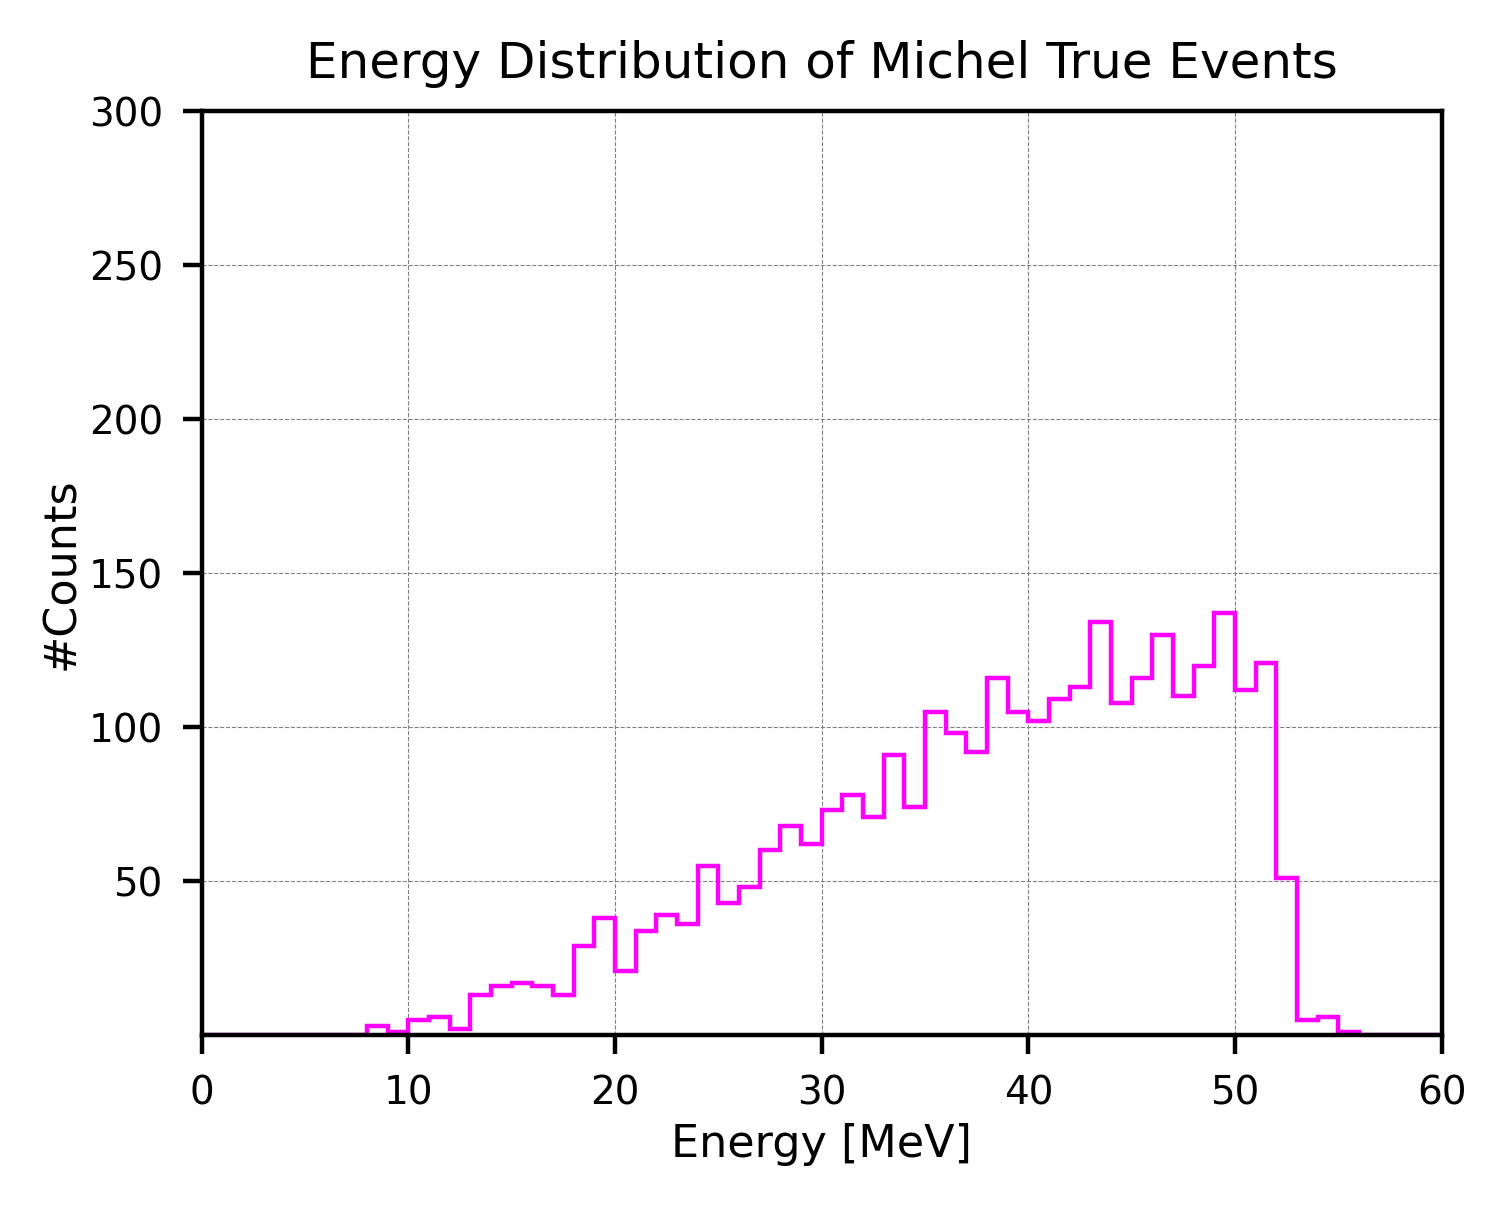

In [24]:
#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 1.0
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

final_trueE = [ev.energy for ev in true_newClass]
plt.hist(final_trueE, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(0, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 300)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  


### lifetime efficiency calculation:
#### The curve of initial fitting (truth of initial MC reco) with the truth of final dataset

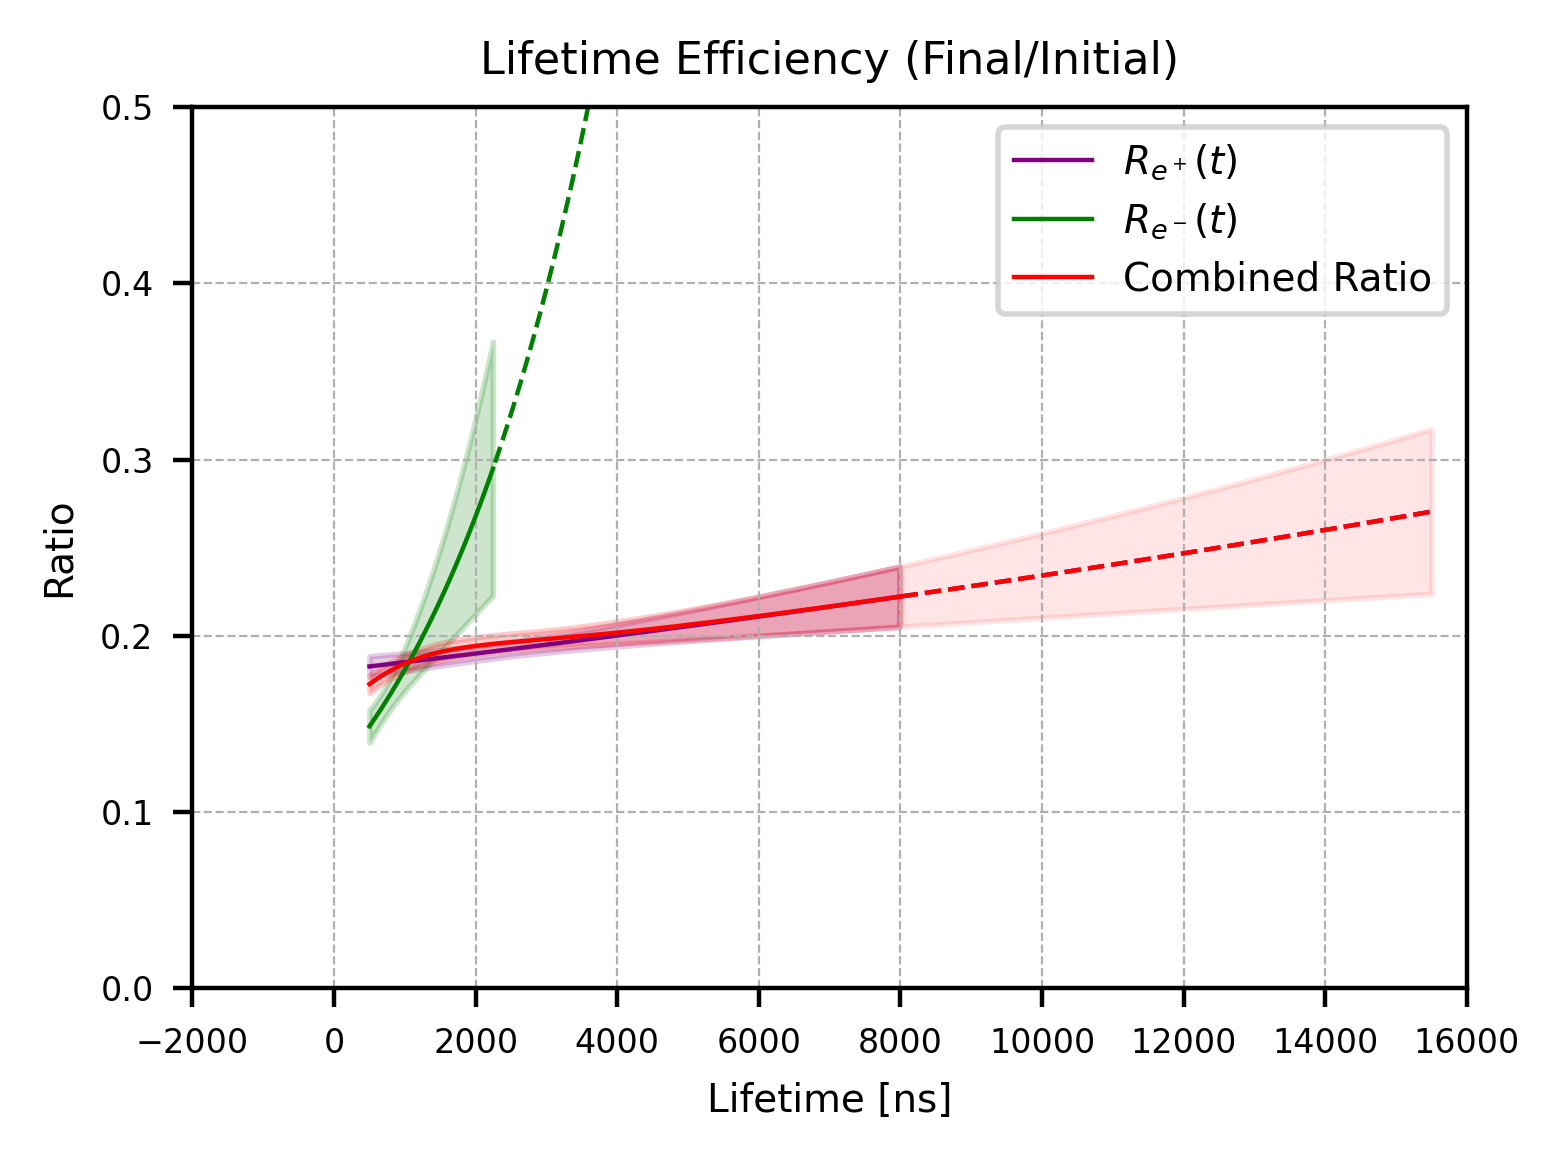

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Normalized exponential pdf
def f(t, tau):
    return (1.0 / tau) * np.exp(-t / tau)

def df_dtau(t, tau):
    ft = f(t, tau)
    return ft * (-1.0/tau + t/(tau**2))

# ========= parameters with uncertainties =========
# e+
tau1_pos, dtau1_pos = 2187.0, 23.0
tau2_pos, dtau2_pos = 2320.0, 65.0
n1_pos, dn1_pos = 13416, np.sqrt(13416)
n2_pos, dn2_pos = 2564, np.sqrt(2564)

# e-
tau1_neg, dtau1_neg = 566.0, 15.0
tau2_neg, dtau2_neg = 728.0, 79.0
n1_neg, dn1_neg = 2797, np.sqrt(2797)
n2_neg, dn2_neg = 439, np.sqrt(439)

# Lifetime range in ns
t = np.linspace(500, 15500, 500)

# ----------- Single-species ratio and uncertainty -----------
def R_ratio(t, n1, n2, tau1, tau2):
    return (n2 / n1) * (tau1 / tau2) * np.exp(-t * (1/tau2 - 1/tau1))

def R_error(t, n1, n2, tau1, tau2, dn1, dn2, dtau1, dtau2):
    R = R_ratio(t, n1, n2, tau1, tau2)
    dR_dn1   = -R / n1
    dR_dn2   =  R / n2
    dR_dtau1 = R * (1.0/tau1 - t/(tau1**2))
    dR_dtau2 = R * (-1.0/tau2 + t/(tau2**2))
    sigma2 = (dR_dn1*dn1)**2 + (dR_dn2*dn2)**2 + (dR_dtau1*dtau1)**2 + (dR_dtau2*dtau2)**2
    return np.sqrt(sigma2)

# e+ and e- ratios + errors
R_pos = R_ratio(t, n1_pos, n2_pos, tau1_pos, tau2_pos)
R_pos_err = R_error(t, n1_pos, n2_pos, tau1_pos, tau2_pos,
                    dn1_pos, dn2_pos, dtau1_pos, dtau2_pos)

R_neg = R_ratio(t, n1_neg, n2_neg, tau1_neg, tau2_neg)
R_neg_err = R_error(t, n1_neg, n2_neg, tau1_neg, tau2_neg,
                    dn1_neg, dn2_neg, dtau1_neg, dtau2_neg)

# ----------- Combined ratio and uncertainty -----------
f1p = f(t, tau1_pos); df1p = df_dtau(t, tau1_pos)
f1n = f(t, tau1_neg); df1n = df_dtau(t, tau1_neg)
f2p = f(t, tau2_pos); df2p = df_dtau(t, tau2_pos)
f2n = f(t, tau2_neg); df2n = df_dtau(t, tau2_neg)

F_init  = n1_pos * f1p + n1_neg * f1n
F_final = n2_pos * f2p + n2_neg * f2n
R_combined = F_final / F_init

invB = 1.0 / F_init
# derivatives wrt parameters
dR_dn2p   = f2p * invB
dR_dn2n   = f2n * invB
dR_dtau2p = (n2_pos * df2p) * invB
dR_dtau2n = (n2_neg * df2n) * invB
dR_dn1p   = -R_combined * f1p * invB
dR_dn1n   = -R_combined * f1n * invB
dR_dtau1p = -R_combined * (n1_pos * df1p) * invB
dR_dtau1n = -R_combined * (n1_neg * df1n) * invB

# error propagation
sigma2_comb = (dR_dn2p*dn2_pos)**2 + (dR_dn2n*dn2_neg)**2 \
            + (dR_dtau2p*dtau2_pos)**2 + (dR_dtau2n*dtau2_neg)**2 \
            + (dR_dn1p*dn1_pos)**2 + (dR_dn1n*dn1_neg)**2 \
            + (dR_dtau1p*dtau1_pos)**2 + (dR_dtau1n*dtau1_neg)**2
R_combined_err = np.sqrt(sigma2_comb)

# ----------- Plot -----------
plt.figure(figsize=(4,3), dpi=400)

# cutoffs
cut_pos = 8000   # ns for e+
cut_neg = 2250   # ns for e-
cut_comb = 8000  # combined trusted range

mask_pos = t <= cut_pos
mask_neg = t <= cut_neg
mask_comb = t <= cut_comb

# e+
plt.plot(t[mask_pos], R_pos[mask_pos], color="purple", lw=0.8, ls="-", label=r"$R_{e^+}(t)$")
plt.fill_between(t[mask_pos], R_pos[mask_pos]-R_pos_err[mask_pos],
                 R_pos[mask_pos]+R_pos_err[mask_pos], color="purple", alpha=0.2)
plt.plot(t[~mask_pos], R_pos[~mask_pos], color="purple", lw=0.8, ls="--")

# e-
plt.plot(t[mask_neg], R_neg[mask_neg], color="green", lw=0.8, ls="-", label=r"$R_{e^-}(t)$")
plt.fill_between(t[mask_neg], R_neg[mask_neg]-R_neg_err[mask_neg],
                 R_neg[mask_neg]+R_neg_err[mask_neg], color="green", alpha=0.2)
plt.plot(t[~mask_neg], R_neg[~mask_neg], color="green", lw=0.8, ls="--")

# combined
plt.plot(t[mask_comb], R_combined[mask_comb], color="red", lw=0.8, ls="-", label="Combined Ratio")
plt.fill_between(t[mask_comb], R_combined[mask_comb]-R_combined_err[mask_comb],
                 R_combined[mask_comb]+R_combined_err[mask_comb],
                 color="red", alpha=0.2)

# dashed extrapolation beyond 8000 ns
plt.plot(t[~mask_comb], R_combined[~mask_comb], color="red", lw=0.8, ls="--")
plt.fill_between(t[~mask_comb], R_combined[~mask_comb]-R_combined_err[~mask_comb],
                 R_combined[~mask_comb]+R_combined_err[~mask_comb],
                 color="red", alpha=0.1)  # weaker shading

# cosmetics
plt.xlabel("Lifetime [ns]", fontsize=7)
plt.ylabel("Ratio", fontsize=7)
plt.tick_params(labelsize=6)
plt.xlim(-2000, 16000)
plt.ylim(0, 0.5)
plt.title("Lifetime Efficiency (Final/Initial)", fontsize=8)
plt.grid(True, linestyle="--", lw=0.4)
plt.legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()


#### Apply efficiency curve

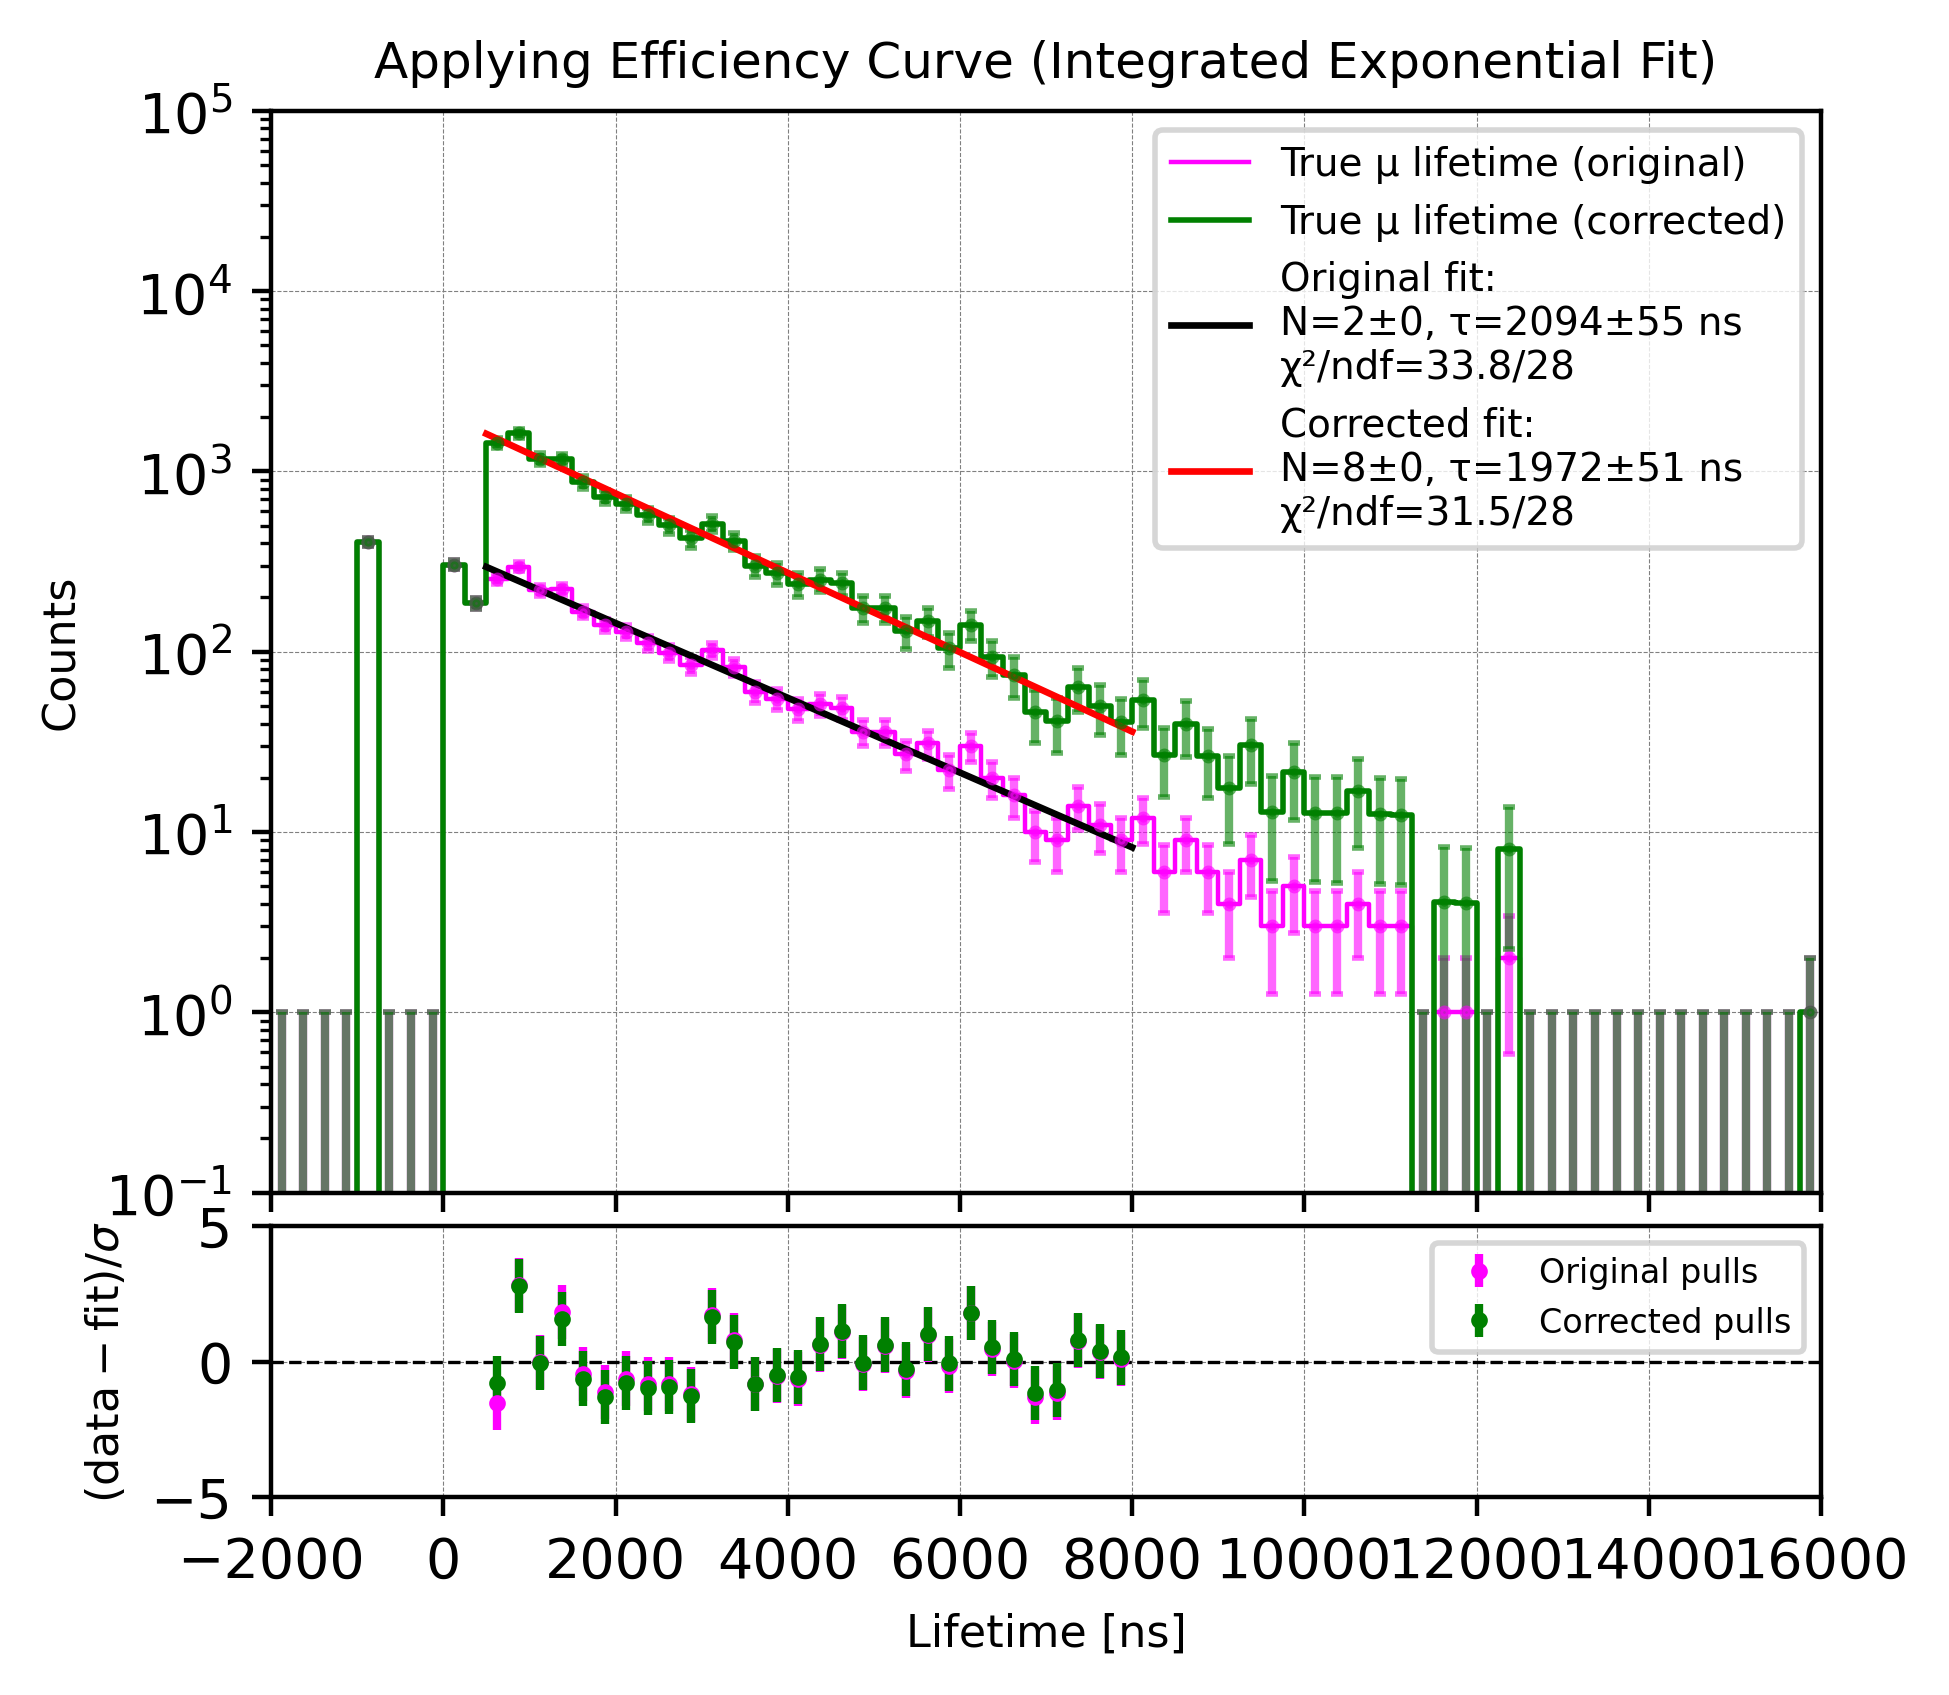

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec

# Histogram parameters
bin_width = 250
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# --- Compute histogram (True μ lifetime, uncorrected) ---
counts, bin_edges = np.histogram(lifetime_update_ns2, bins=bins, range=(range_min, range_max))
counts_initial = counts.copy()
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Interpolate efficiency curve and error onto bin centers
R_interp = np.interp(bin_centers, t, R_combined)
R_err_interp = np.interp(bin_centers, t, R_combined_err)

# Apply correction only in effective range [500, 15500]
mask = (bin_centers >= 500) & (bin_centers <= 15500)
corrected_counts = counts.astype(float)
corrected_counts[mask] = counts[mask] / R_interp[mask]

# --- Uncertainties ---
unc_initial = np.sqrt(counts_initial)

# Corrected uncertainties: Poisson + efficiency error
unc_corrected = np.zeros_like(corrected_counts, dtype=float)
unc_corrected[mask] = np.sqrt(
    (np.sqrt(counts[mask]) / R_interp[mask])**2 +
    ((counts[mask] * R_err_interp[mask]) / (R_interp[mask]**2))**2
)
unc_corrected[~mask] = np.sqrt(counts[~mask])  # outside range, same as original

unc_initial   = np.where(unc_initial == 0, 1.0, unc_initial)
unc_corrected = np.where(unc_corrected == 0, 1.0, unc_corrected)

# ----------- Bin-integrated exponential model -----------
def exp1_integrated(edges, N, tau):
    """Expected counts in bins defined by edges [a,b]."""
    a = edges[:-1]
    b = edges[1:]
    return N * tau * (np.exp(-a/tau) - np.exp(-b/tau))

def fit_histogram(bin_edges, counts, sigma, mask, label, color):
    # restrict to mask (using bin centers for range, but keep edges for integration)
    centers = 0.5*(bin_edges[:-1] + bin_edges[1:])
    m = mask & (counts > 0)
    y = counts[m]
    err = sigma[m]
    edges_fit = np.concatenate([ [bin_edges[np.where(m)[0][0]]],
                                 bin_edges[np.where(m)[0]+1] ])

    # initial guesses
    N0 = np.sum(y)
    tau0 = 2000.0
    p0 = [N0, tau0]

    popt, pcov = curve_fit(
        lambda edges, N, tau: exp1_integrated(edges, N, tau),
        edges_fit, y, p0=p0, sigma=err,
        absolute_sigma=True, maxfev=20000,
        bounds=([0,1e-6],[np.inf,np.inf])
    )
    perr = np.sqrt(np.diag(pcov))

    # model prediction and pulls
    y_fit = exp1_integrated(edges_fit, *popt)
    pulls = (y - y_fit) / err
    chi2 = np.sum(pulls**2)
    ndf = len(y) - len(popt)

    legend_text = (f"{label} fit:\n"
                   f"N={popt[0]:.0f}±{perr[0]:.0f}, "
                   f"τ={popt[1]:.0f}±{perr[1]:.0f} ns\n"
                   f"χ²/ndf={chi2:.1f}/{ndf}")

    # return also bin centers for pulls
    return popt, perr, legend_text, centers[m], pulls

# Effective fit ranges (allow separate ones)
fit_mask_init = (bin_centers >= 500) & (bin_centers <= 8000)
fit_mask_corr = (bin_centers >= 500) & (bin_centers <= 8000)

# Perform fits
popt_init, perr_init, legend_init, x_init, pulls_init = fit_histogram(bin_edges, counts_initial, unc_initial, fit_mask_init, "Original", "magenta")
popt_corr, perr_corr, legend_corr, x_corr, pulls_corr = fit_histogram(bin_edges, corrected_counts, unc_corrected, fit_mask_corr, "Corrected", "green")

# ----------- Plotting with residuals panel -----------
fig = plt.figure(figsize=(5, 4.5), dpi=400)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)

# --- Top panel ---
ax.step(bin_centers, counts_initial, where="mid", color="magenta", linewidth=0.8,
        label="True μ lifetime (original)")
ax.errorbar(bin_centers, counts_initial, yerr=unc_initial, fmt='o', color="magenta",
            markersize=1.5, capsize=1.0, alpha=0.6)

ax.step(bin_centers, corrected_counts, where="mid", color="green", linewidth=1.0,
        label="True μ lifetime (corrected)")
ax.errorbar(bin_centers, corrected_counts, yerr=unc_corrected, fmt='o', color="green",
            markersize=1.5, capsize=1.0, alpha=0.6)

# Plot fits (overlay smooth curve consistent with histogram counts)
fit_x = np.linspace(500, 8000, 400)
ax.plot(fit_x, popt_init[0] * np.exp(-fit_x / popt_init[1]) * bin_width,
        color="black", lw=1.2, label=legend_init)
ax.plot(fit_x, popt_corr[0] * np.exp(-fit_x / popt_corr[1]) * bin_width,
        color="red", lw=1.2, label=legend_corr)


ax.set_ylim(0.1, 100000)
ax.set_yscale('log')
ax.set_ylabel("Counts", fontsize=8)
ax.set_xlim(-2000, 16000)
ax.set_title("Applying Efficiency Curve (Integrated Exponential Fit)", fontsize=9)
ax.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax.legend(fontsize=7, loc="upper right", frameon=True)
ax.tick_params(labelbottom=False)

# --- Bottom panel ---
ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax_resid.errorbar(x_init, pulls_init, yerr=np.ones_like(pulls_init),
                  fmt='o', color="magenta", markersize=2, label="Original pulls")
ax_resid.errorbar(x_corr, pulls_corr, yerr=np.ones_like(pulls_corr),
                  fmt='o', color="green", markersize=2, label="Corrected pulls")

ax_resid.set_xlabel("Lifetime [ns]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data}-\mathrm{fit})/\sigma$", fontsize=8)
ax_resid.set_xlim(-2000, 16000)
ax_resid.set_ylim(-5, 5)
ax_resid.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax_resid.legend(fontsize=6, loc="upper right")

plt.show()



### Lifetime VS energy:

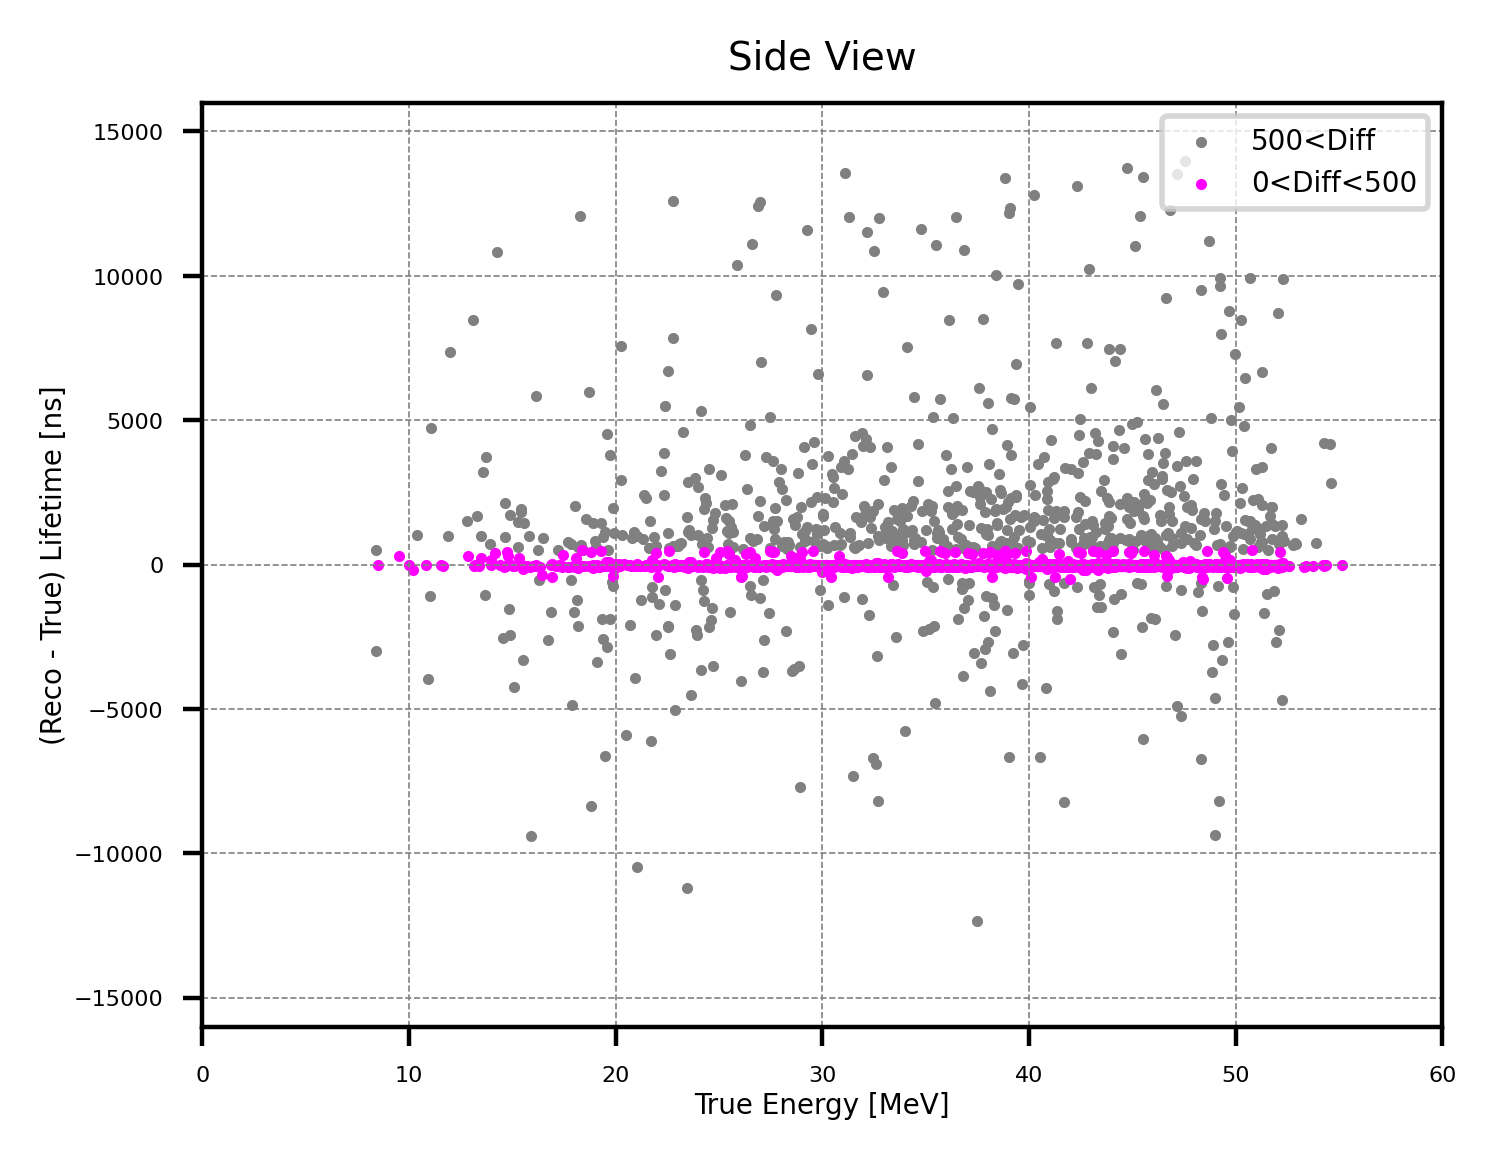

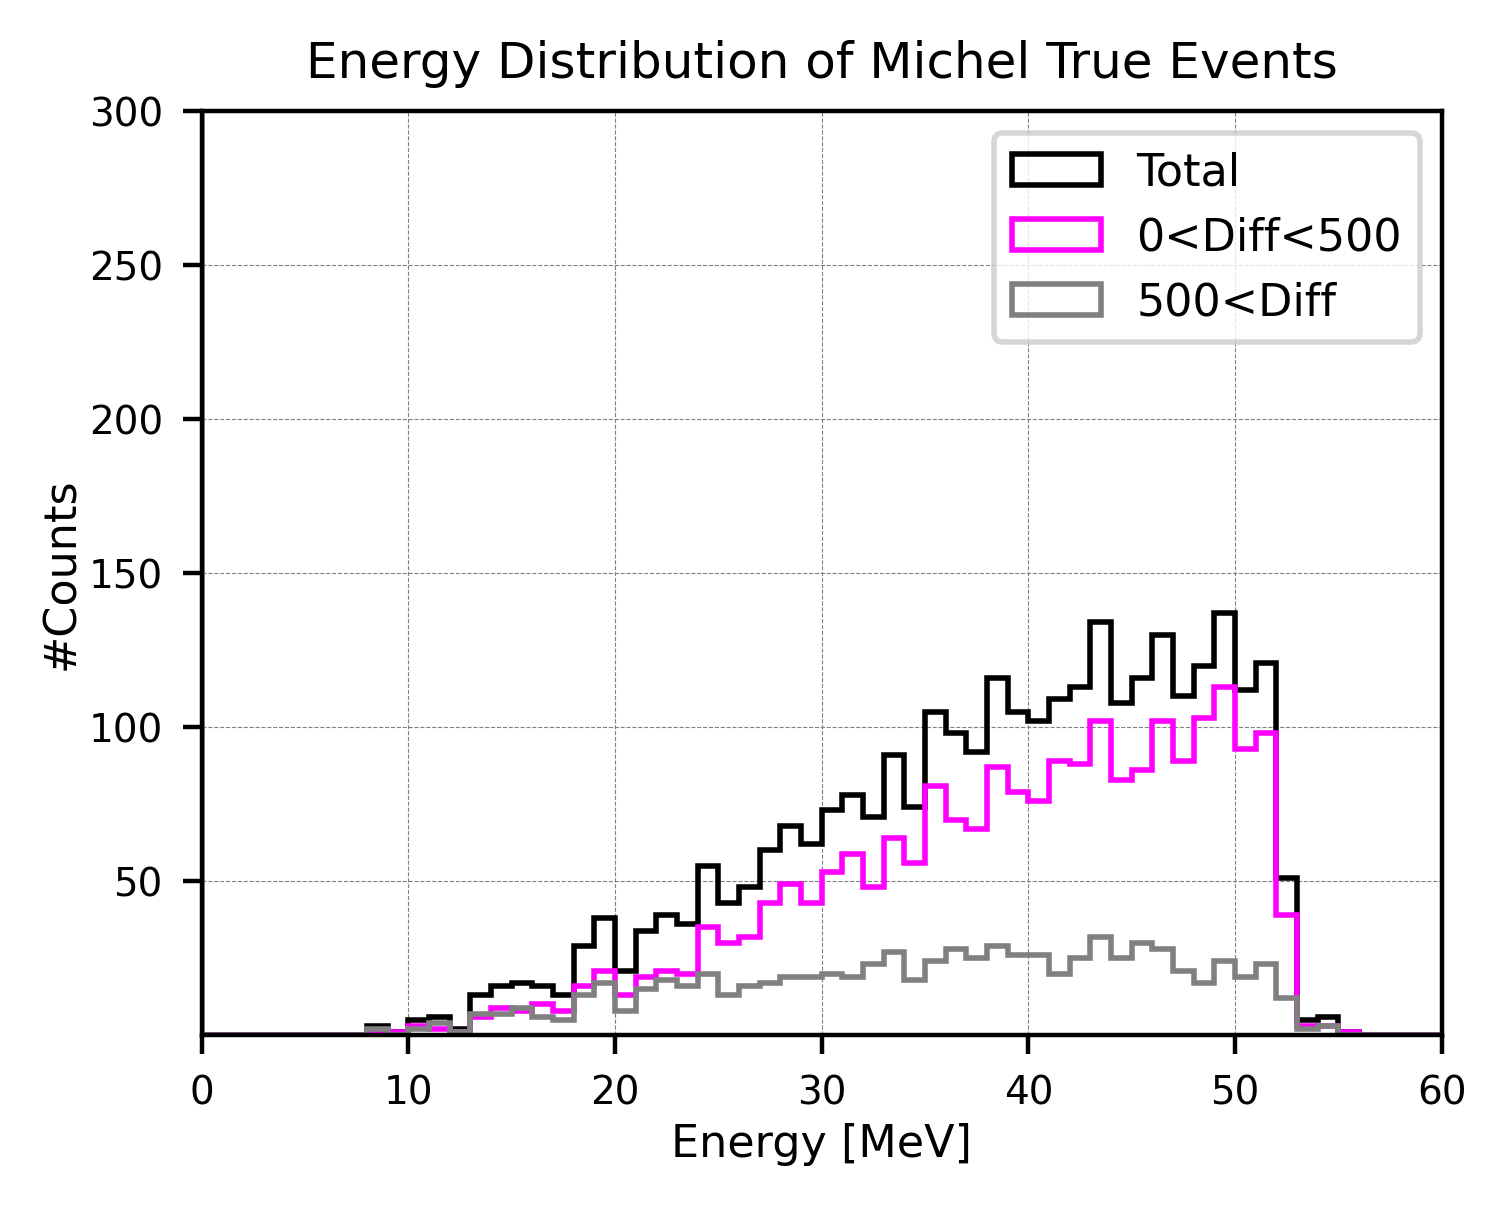

In [16]:

energy_diff500 = [ev.energy for ev in events_diff500]
trueL_diff500 = [ev.true_lifetime for ev in events_diff500]
recoL_diff500 = [ev.reco_lifetime for ev in events_diff500]
diffL_diff500 = [ev.diff_lifetime for ev in events_diff500]

distance_diff500 = [356 - abs(x) for x in posX_diff500]


energy_diff0 = [ev.energy for ev in events_diff0]
trueL_diff0 = [ev.true_lifetime for ev in events_diff0]
recoL_diff0 = [ev.reco_lifetime for ev in events_diff0]
diffL_diff0 = [ev.diff_lifetime for ev in events_diff0]

distance_diff0 = [356 - abs(x) for x in posX_diff0]



# ==========================================================
# Energy VS Lifetime
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)


# Scatter plot----------
plt.scatter(energy_diff500, diffL_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
plt.scatter(energy_diff0, diffL_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
#-----------------------

#plt.axis('scaled')
plt.ylim(-16000, 16000)
plt.xlim(0, 60)
plt.ylabel('(Reco - True) Lifetime [ns]', labelpad=1, fontsize=5)
plt.xlabel('True Energy [MeV]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(fontsize=5, loc="upper right")
plt.show()





#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 1.0
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

final_trueE = [ev.energy for ev in true_newClass]
plt.hist(final_trueE, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=1.0, label="Total")
plt.hist(energy_diff0, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=1.0, label="0<Diff<500")
plt.hist(energy_diff500, bins=bins, range=(range_min, range_max), edgecolor='grey', 
         histtype='step', linewidth=1.0, label="500<Diff")

plt.xlim(0, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 300)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  



#### Single Event Inspection

In [17]:
print("#events with |diff| <= 500: ", len(events_diff0), "/", len(events_newClass),
       "({:.2f}%)".format(len(events_diff0)/len(events_newClass)*100))

print("\n#events with |diff| > 500 : ", len(events_diff500), "/", len(events_newClass),
       "({:.2f}%)".format(len(events_diff500)/len(events_newClass)*100))


# Print the first 10 events
for i, ev in enumerate(events_diff500[:100]):
    print(f"Event {i}: {ev}")


#events with |diff| <= 500:  2223 / 3411 (65.17%)

#events with |diff| > 500 :  1188 / 3411 (34.83%)
Event 0: PdsEventNew(muon_time=126, michel_time=486, muon_intensity=13.0164, michel_intensity=1.85365, posX=76.696, posY=459.051, posZ=74.0443, energy=-1.0, lifetime=-1.0, pdg=0, eventID=10104, trackID=18, date=20250828, reco_lifetime=5760, true_lifetime=-1000.0, diff_lifetime=6760.0, michel_rise=0.1122870588235294, michel_drop=0.12357666666666667)
Event 1: PdsEventNew(muon_time=125, michel_time=342, muon_intensity=12.9291, michel_intensity=0.934101, posX=33.8829, posY=241.002, posZ=64.4633, energy=36.2918, lifetime=1.73362, pdg=-11, eventID=10143, trackID=8, date=20250828, reco_lifetime=3472, true_lifetime=1733.62, diff_lifetime=1738.38, michel_rise=0.04670505, michel_drop=0.06709021428571428)
Event 2: PdsEventNew(muon_time=128, michel_time=654, muon_intensity=15.5115, michel_intensity=8.10843, posX=51.8687, posY=193.018, posZ=349.94, energy=-1.0, lifetime=-1.0, pdg=0, eventID=10198, t

#### More inspections:

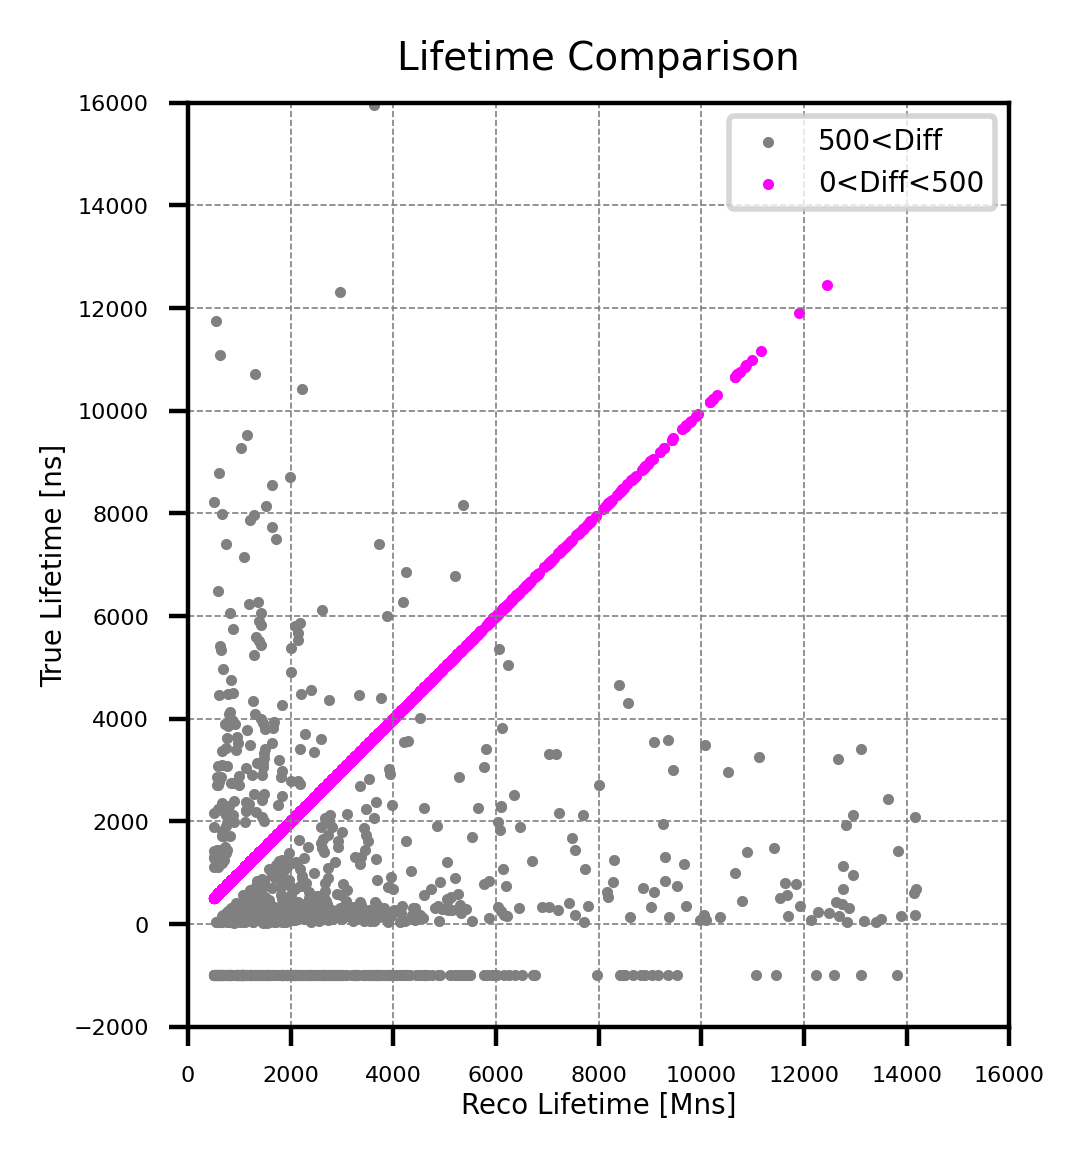

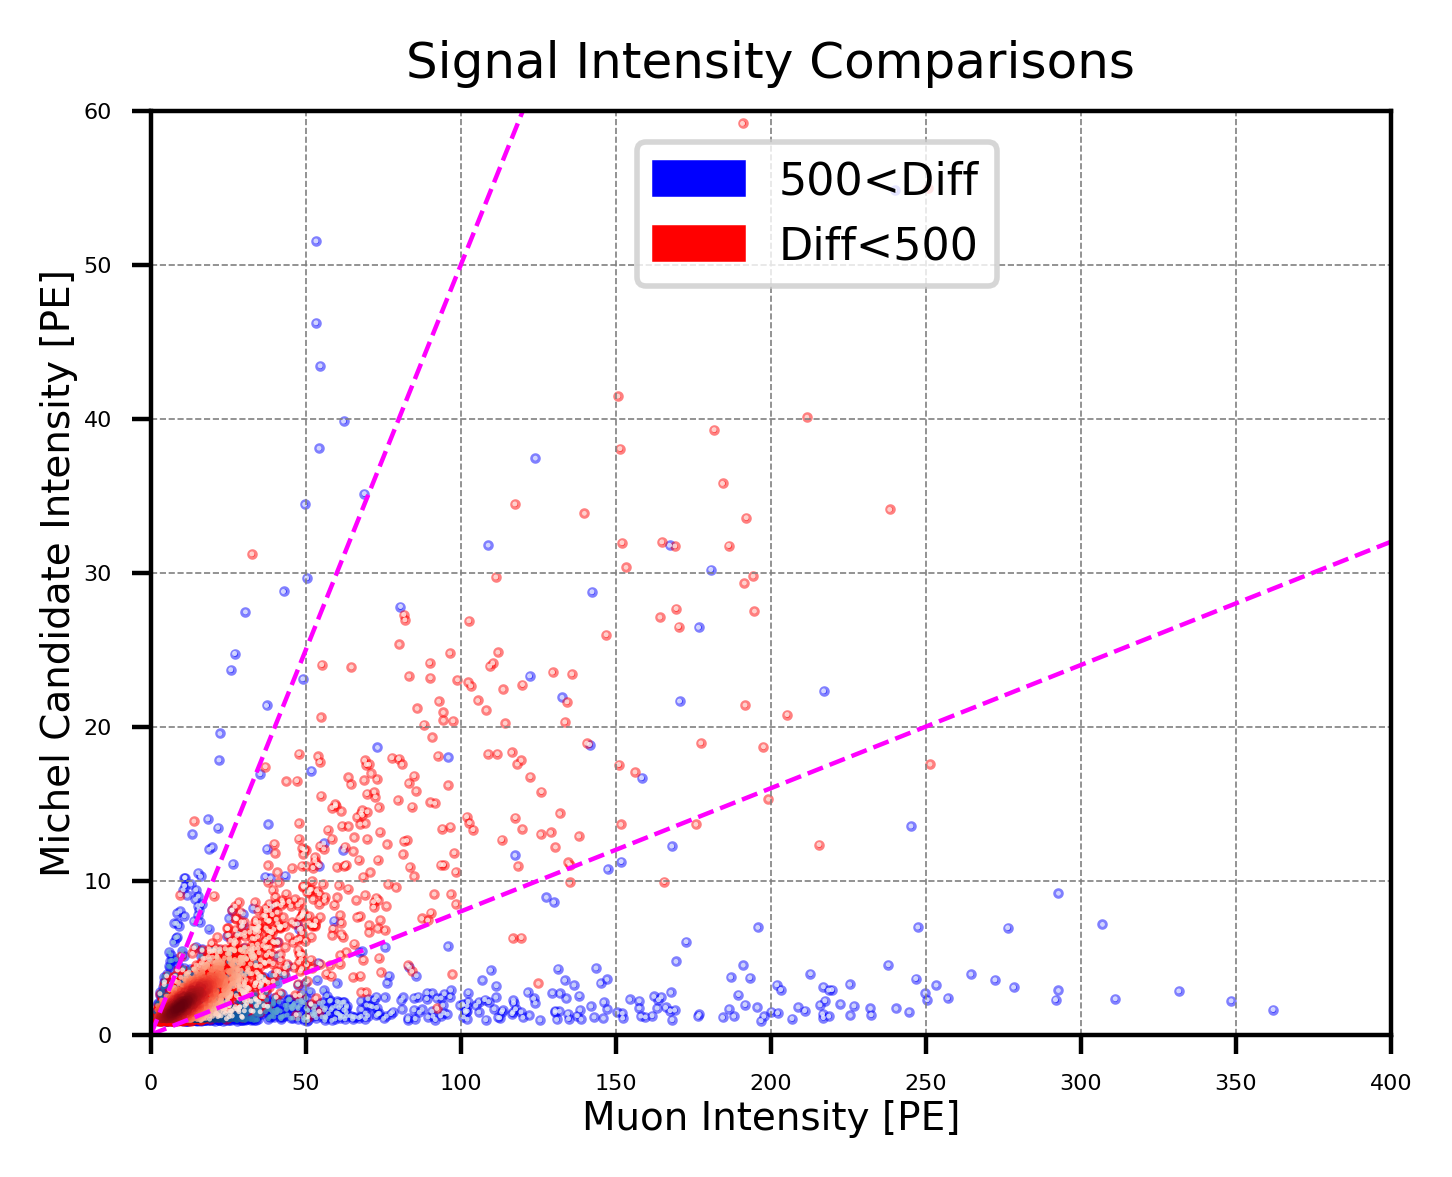


(Diff < 500)   :  2223 / 3411 (65.17%)
(Diff > 500)   :  1188 / 3411 (34.83%)
Diff0 / Diff500:  1188 / 1188 (100.00%)

Applying Cuts:----------
(Diff < 500)   :  2063 / 3411 (60.48%)
(Diff > 500)   :  569 / 3411 (16.68%)
Diff0 / Diff500:  2063 / 569 (362.57%)


In [18]:
from scipy.stats import gaussian_kde
from matplotlib import colors 
import matplotlib.patches as mpatches


trueLife_diff500 = [ev.true_lifetime for ev in events_diff500]
recoLife_diff500 = [ev.reco_lifetime for ev in events_diff500]
muInt_diff500 = [ev.muon_intensity for ev in events_diff500]
miInt_diff500 = [ev.michel_intensity for ev in events_diff500]
X_diff500 = [ev.posX for ev in events_diff500]

trueLife_diff0 = [ev.true_lifetime for ev in events_diff0]
recoLife_diff0 = [ev.reco_lifetime for ev in events_diff0]
muInt_diff0 = [ev.muon_intensity for ev in events_diff0]
miInt_diff0 = [ev.michel_intensity for ev in events_diff0]
X_diff0 = [ev.posX for ev in events_diff0]



# ==========================================================
# TrueLife VS RecoLife
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot----------
plt.scatter(recoLife_diff500, trueLife_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
plt.scatter(recoLife_diff0, recoLife_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
#-----------------------

plt.axis('scaled')
plt.xlim(0, 16000)
plt.ylim(-2000, 16000)
plt.ylabel('True Lifetime [ns]', labelpad=1, fontsize=5)
plt.xlabel('Reco Lifetime [Mns]', labelpad=1, fontsize=5)
plt.title('Lifetime Comparison', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(fontsize=5, loc="upper right")
plt.show()




# ==========================================================
# Mu Intensity VS Michel Intensity
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(muInt_diff500), np.array(miInt_diff500)
x2, y2 = np.array(muInt_diff0), np.array(miInt_diff0)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Density for group 2 (blue, 0<Diff<500) ---
xy2 = np.vstack([x2, y2])
z2 = gaussian_kde(xy2)(xy2)
idx2 = z2.argsort()
x2, y2, z2 = x2[idx2], y2[idx2], z2[idx2]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
plt.scatter(x2, y2, s=0.8, color="red", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="500<Diff")
plt.scatter(x2, y2, c=z2, s=0.8, cmap="Reds", alpha=0.8, edgecolors="none", label="Diff<500")

#---------------------------------

plt.plot([0, 500], [0, 40], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0, 1000], [0, 500], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 400)
plt.ylim(0, 60)
plt.xlabel('Muon Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Michel Candidate Intensity [PE]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="500<Diff")
blue_patch = mpatches.Patch(color="red", label="Diff<500")
plt.legend(handles=[red_patch, blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})


plt.show()


#Cuts explore----------
print("\n(Diff < 500)   : ", len(events_diff0), "/", len(events_newClass),
       "({:.2f}%)".format(len(events_diff0)/len(events_newClass)*100))
print("(Diff > 500)   : ", len(muInt_diff500), "/", len(events_newClass),
       "({:.2f}%)".format(len(muInt_diff500)/len(events_newClass)*100))
print("Diff0 / Diff500: ", len(events_diff500), "/", len(muInt_diff500),
       "({:.2f}%)".format(len(events_diff500)/len(muInt_diff500)*100))


#---Selection-------------------
thre1 = 4.0 / 50
thre2 = 50 / 100

# filter the actual events
events_diff0_purify1 = [
    ev for ev in events_diff0
    if ev.muon_intensity != 0 and thre1 < ev.michel_intensity / ev.muon_intensity < thre2
]
events_diff500_purify1 = [
    ev for ev in events_diff500
    if ev.muon_intensity != 0 and thre1 < ev.michel_intensity / ev.muon_intensity < thre2
]
#-------------------------------

print("\nApplying Cuts:----------")
print("(Diff < 500)   : ", len(events_diff0_purify1), "/", len(events_newClass),
       "({:.2f}%)".format(len(events_diff0_purify1)/len(events_newClass)*100))
print("(Diff > 500)   : ", len(events_diff500_purify1), "/", len(events_newClass),
       "({:.2f}%)".format(len(events_diff500_purify1)/len(events_newClass)*100))
print("Diff0 / Diff500: ", len(events_diff0_purify1), "/", len(events_diff500_purify1),
       "({:.2f}%)".format(len(events_diff0_purify1)/len(events_diff500_purify1)*100))







#### Michel Candidates Intensities:

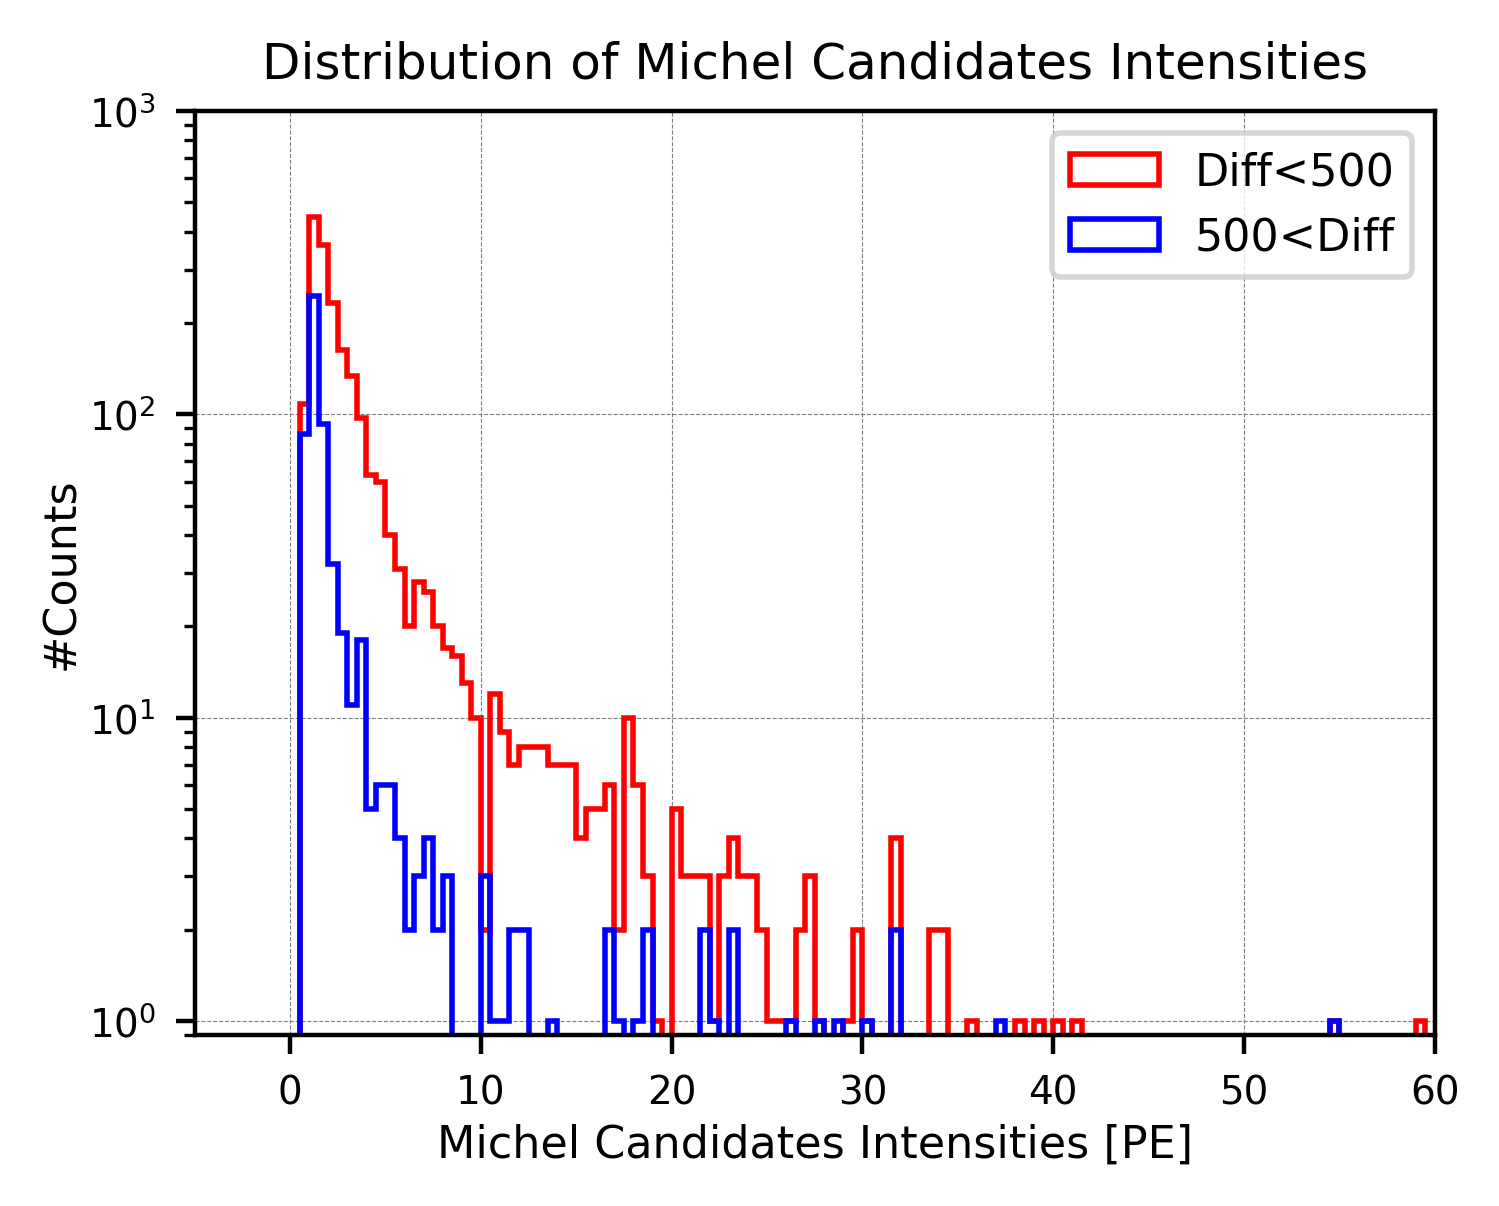

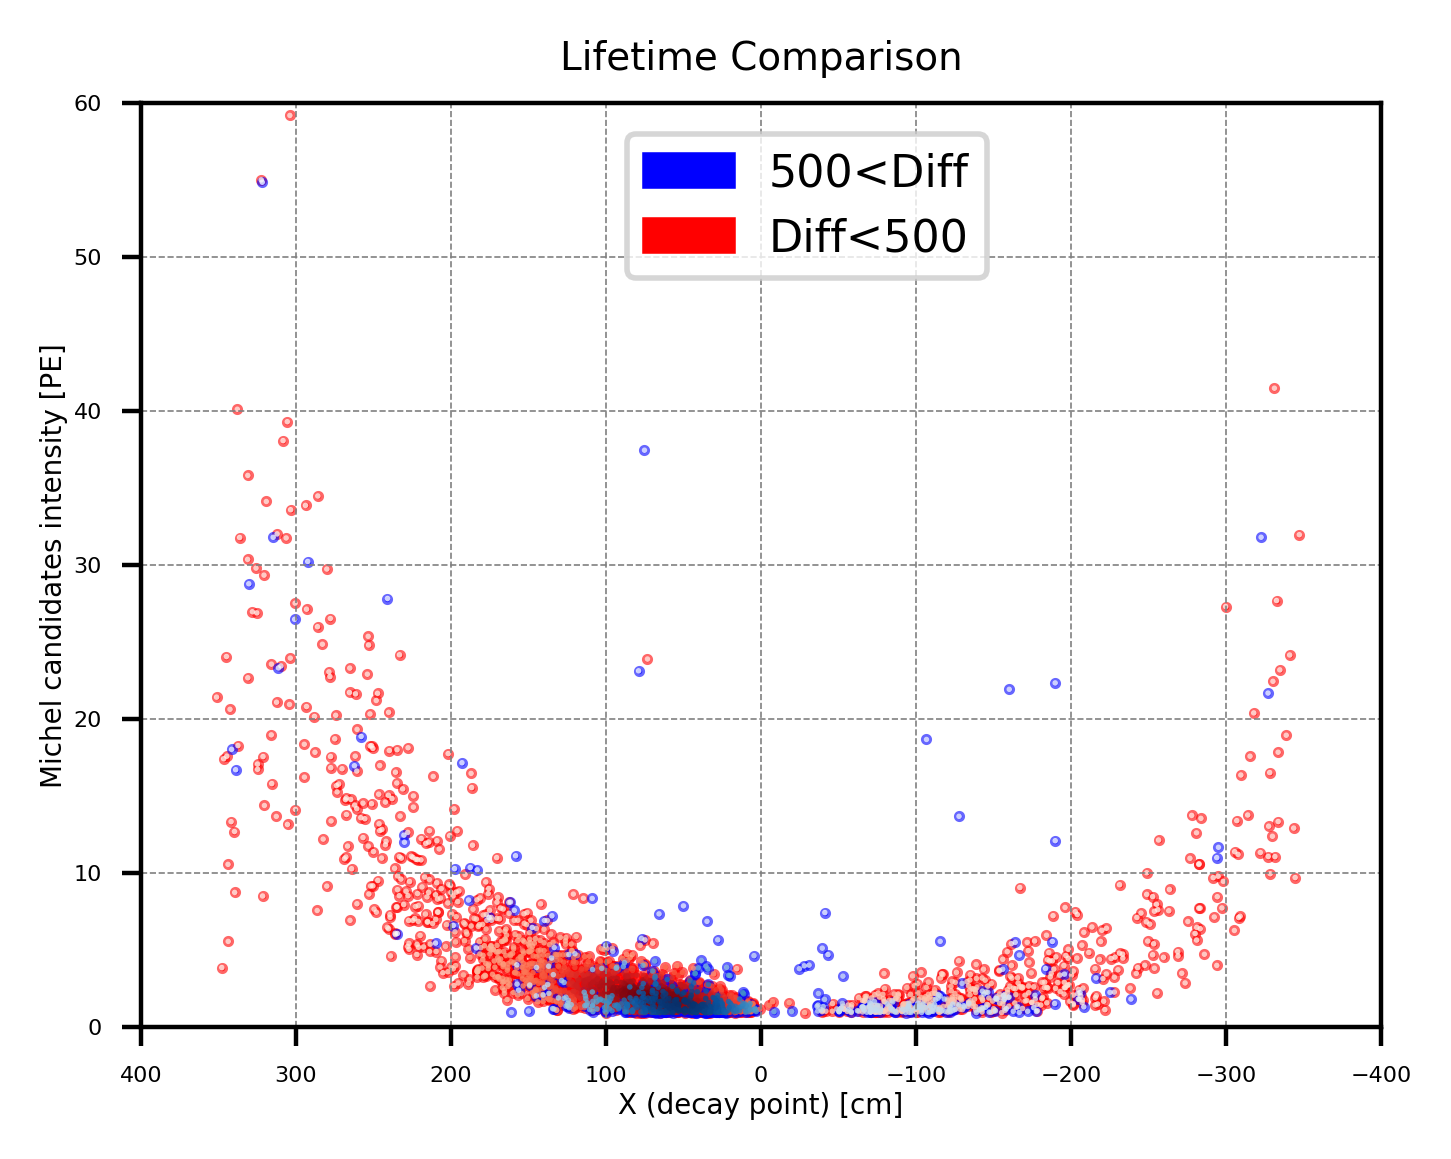

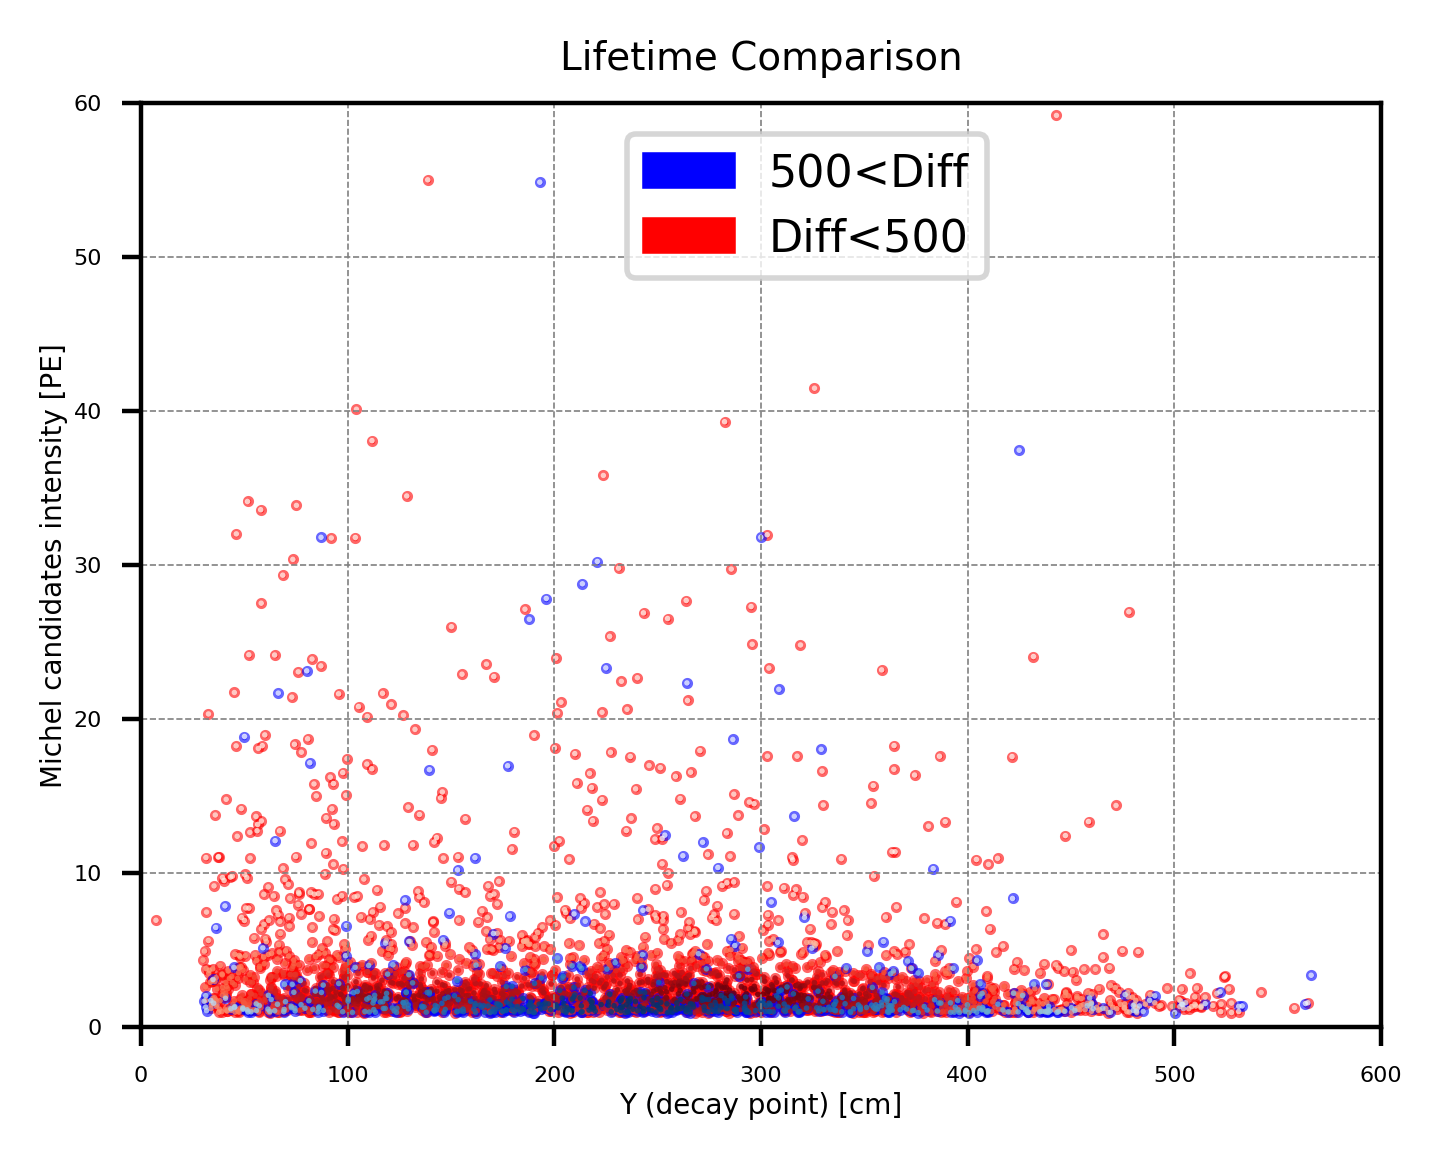

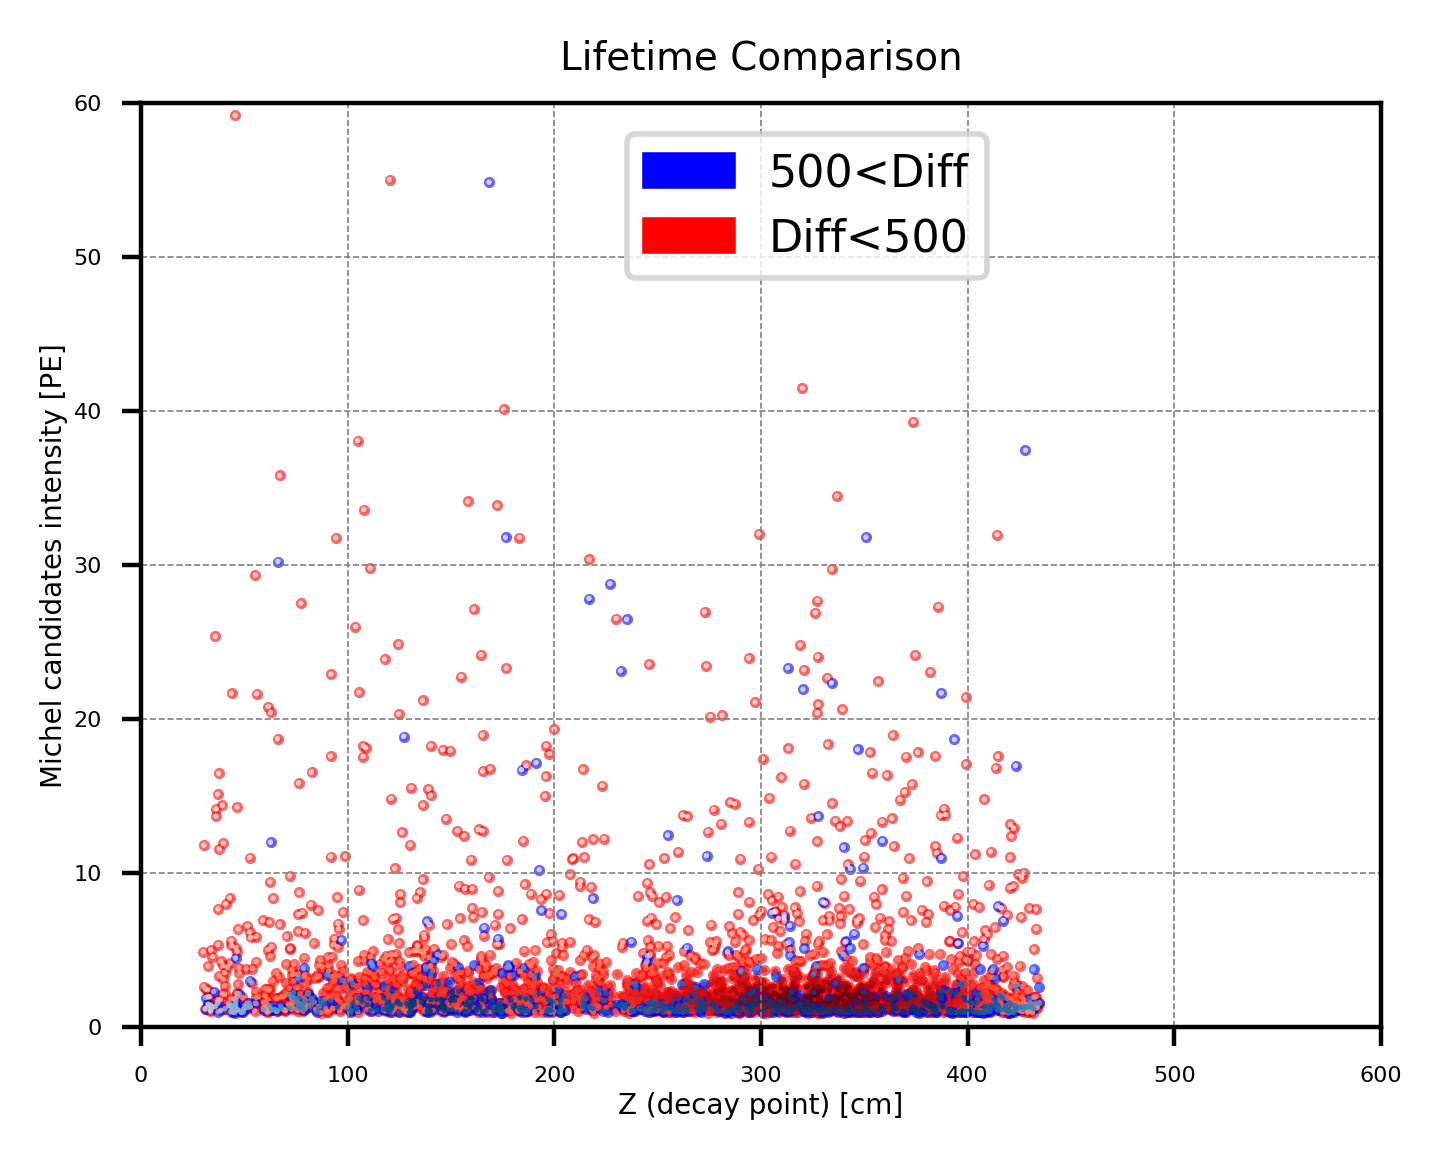

In [19]:
from scipy.stats import gaussian_kde
from matplotlib import colors 
import matplotlib.patches as mpatches



#After "ratio cut"----------------------
miInt_diff0_purity1 = [ev.michel_intensity for ev in events_diff0_purify1]
muInt_diff0_purity1 = [ev.muon_intensity for ev in events_diff0_purify1]
X_diff0_purity1 = [ev.posX for ev in events_diff0_purify1]
Y_diff0_purity1 = [ev.posY for ev in events_diff0_purify1]
Z_diff0_purity1 = [ev.posZ for ev in events_diff0_purify1]

ratios_diff0_purity1 = [mi / mu for mi, mu in 
                        zip(miInt_diff0_purity1, muInt_diff0_purity1) if mu != 0]


miInt_diff500_purity1 = [ev.michel_intensity for ev in events_diff500_purify1]
muInt_diff500_purity1 = [ev.muon_intensity for ev in events_diff500_purify1]
X_diff500_purity1 = [ev.posX for ev in events_diff500_purify1]
Y_diff500_purity1 = [ev.posY for ev in events_diff500_purify1]
Z_diff500_purity1 = [ev.posZ for ev in events_diff500_purify1]

ratios_diff500_purity1 = [mi / mu for mi, mu in 
                          zip(miInt_diff500_purity1, muInt_diff500_purity1) if mu != 0]



#Michel Intensity distribution===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(miInt_diff0_purity1, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label="Diff<500")
plt.hist(miInt_diff500_purity1, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="500<Diff")

plt.xlim(-5, 60)
plt.xlabel('Michel Candidates Intensities [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 1000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Michel Candidates Intensities', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  




#Michel Intensity VS x axis================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot----------
# --- Diff<500 (red group) ---
x0 = np.array(X_diff0_purity1, dtype=float)
y0 = np.array(miInt_diff0_purity1, dtype=float)
xy0 = np.vstack([x0, y0])
z0 = gaussian_kde(xy0)(xy0)

# --- 500<Diff (blue group) ---
x1 = np.array(X_diff500_purity1, dtype=float)
y1 = np.array(miInt_diff500_purity1, dtype=float)
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)

# Base layer (solid color so single points are visible)
plt.scatter(x0, y0, s=1, color="red", alpha=0.6, label="_nolegend_")
plt.scatter(x1, y1, s=1, color="blue", alpha=0.6, label="_nolegend_")
# Density layer (adds shading in dense regions)
plt.scatter(x0, y0, c=z0, s=1, cmap="Reds", alpha=0.8, edgecolors="none", label="Diff<500")
plt.scatter(x1, y1, c=z1, s=1, cmap="Blues", alpha=0.8, edgecolors="none", label="500<Diff")
#-----------------------

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0, 60)
plt.xlabel('X (decay point) [cm]', labelpad=1, fontsize=5)
plt.ylabel('Michel candidates intensity [PE]', labelpad=1, fontsize=5)
plt.title('Lifetime Comparison', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="500<Diff")
blue_patch = mpatches.Patch(color="red", label="Diff<500")
plt.legend(handles=[red_patch, blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()






#Michel Intensity VS y axis================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot----------
# --- Diff<500 (red group) ---
x0 = np.array(Y_diff0_purity1, dtype=float)
y0 = np.array(miInt_diff0_purity1, dtype=float)
xy0 = np.vstack([x0, y0])
z0 = gaussian_kde(xy0)(xy0)

# --- 500<Diff (blue group) ---
x1 = np.array(Y_diff500_purity1, dtype=float)
y1 = np.array(miInt_diff500_purity1, dtype=float)
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)

# Base layer (solid color so single points are visible)
plt.scatter(x0, y0, s=1, color="red", alpha=0.6, label="_nolegend_")
plt.scatter(x1, y1, s=1, color="blue", alpha=0.6, label="_nolegend_")
# Density layer (adds shading in dense regions)
plt.scatter(x0, y0, c=z0, s=1, cmap="Reds", alpha=0.8, edgecolors="none", label="Diff<500")
plt.scatter(x1, y1, c=z1, s=1, cmap="Blues", alpha=0.8, edgecolors="none", label="500<Diff")
#-----------------------

#plt.axis('scaled')
plt.xlim(0, 600)
plt.ylim(0, 60)
plt.xlabel('Y (decay point) [cm]', labelpad=1, fontsize=5)
plt.ylabel('Michel candidates intensity [PE]', labelpad=1, fontsize=5)
plt.title('Lifetime Comparison', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="500<Diff")
blue_patch = mpatches.Patch(color="red", label="Diff<500")
plt.legend(handles=[red_patch, blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()






#Michel Intensity VS z axis================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot----------
# --- Diff<500 (red group) ---
x0 = np.array(Z_diff0_purity1, dtype=float)
y0 = np.array(miInt_diff0_purity1, dtype=float)
xy0 = np.vstack([x0, y0])
z0 = gaussian_kde(xy0)(xy0)

# --- 500<Diff (blue group) ---
x1 = np.array(Z_diff500_purity1, dtype=float)
y1 = np.array(miInt_diff500_purity1, dtype=float)
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)

# Base layer (solid color so single points are visible)
plt.scatter(x0, y0, s=1, color="red", alpha=0.6, label="_nolegend_")
plt.scatter(x1, y1, s=1, color="blue", alpha=0.6, label="_nolegend_")
# Density layer (adds shading in dense regions)
plt.scatter(x0, y0, c=z0, s=1, cmap="Reds", alpha=0.8, edgecolors="none", label="Diff<500")
plt.scatter(x1, y1, c=z1, s=1, cmap="Blues", alpha=0.8, edgecolors="none", label="500<Diff")
#-----------------------

#plt.axis('scaled')
plt.xlim(0, 600)
plt.ylim(0, 60)
plt.xlabel('Z (decay point) [cm]', labelpad=1, fontsize=5)
plt.ylabel('Michel candidates intensity [PE]', labelpad=1, fontsize=5)
plt.title('Lifetime Comparison', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="500<Diff")
blue_patch = mpatches.Patch(color="red", label="Diff<500")
plt.legend(handles=[red_patch, blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()



#### Explore Michel Signal Rise Shape:

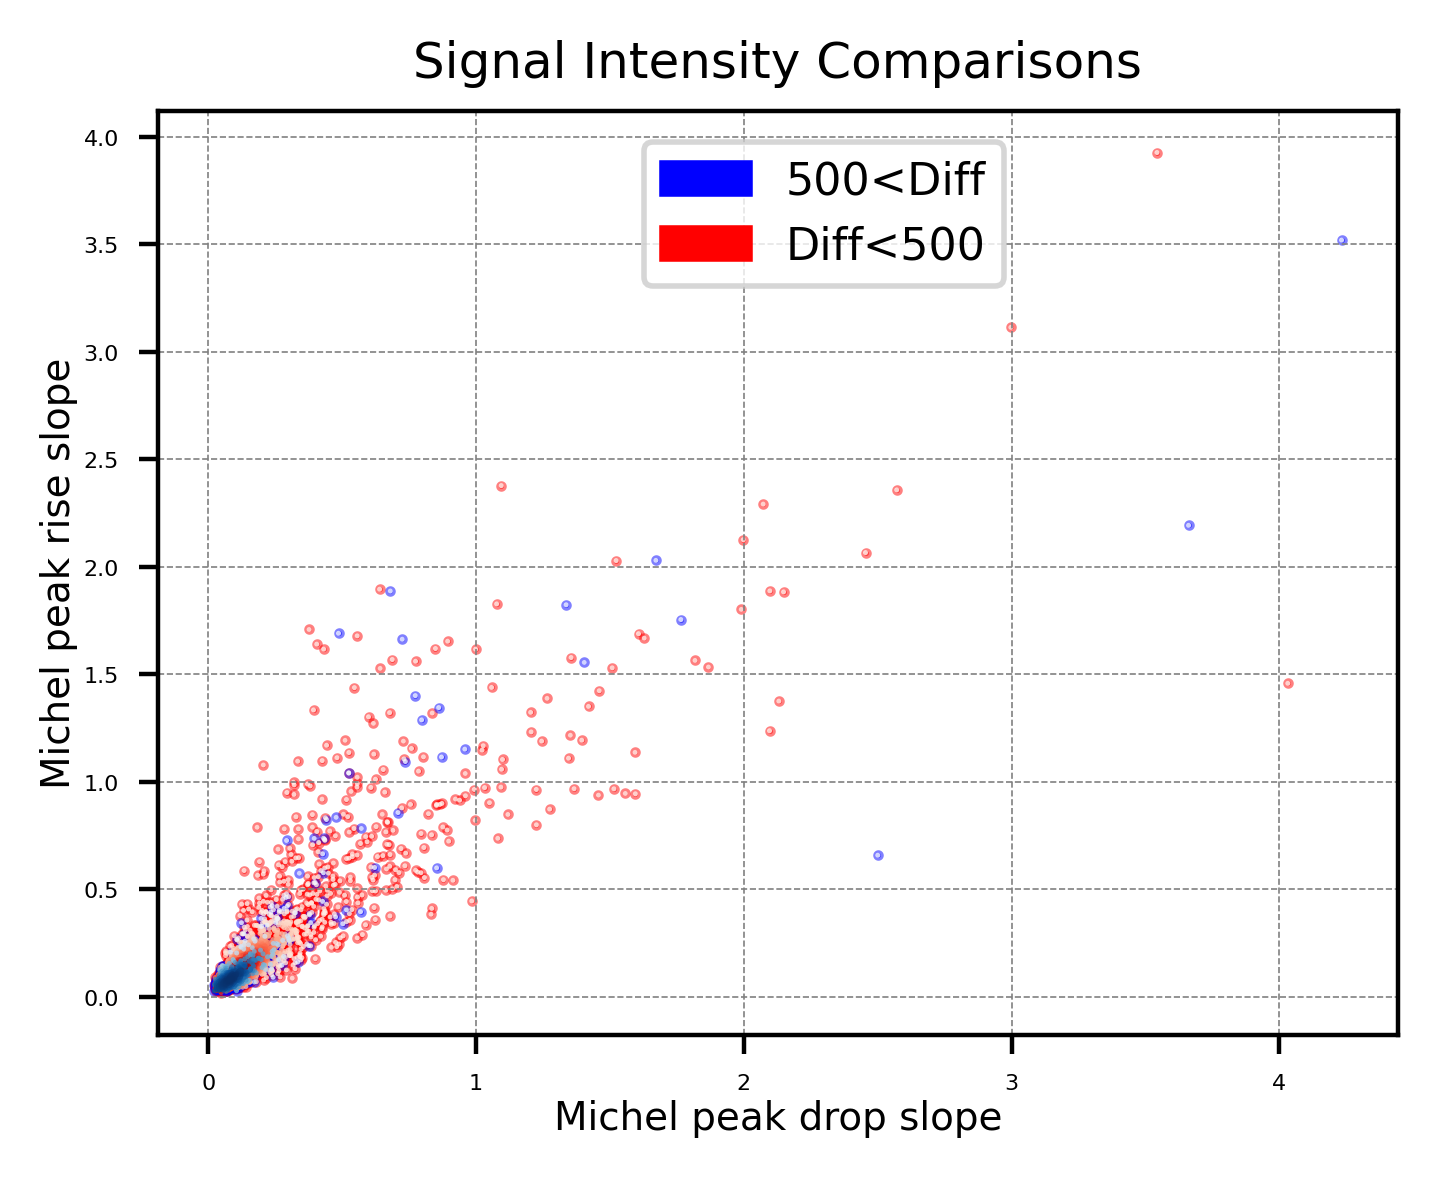

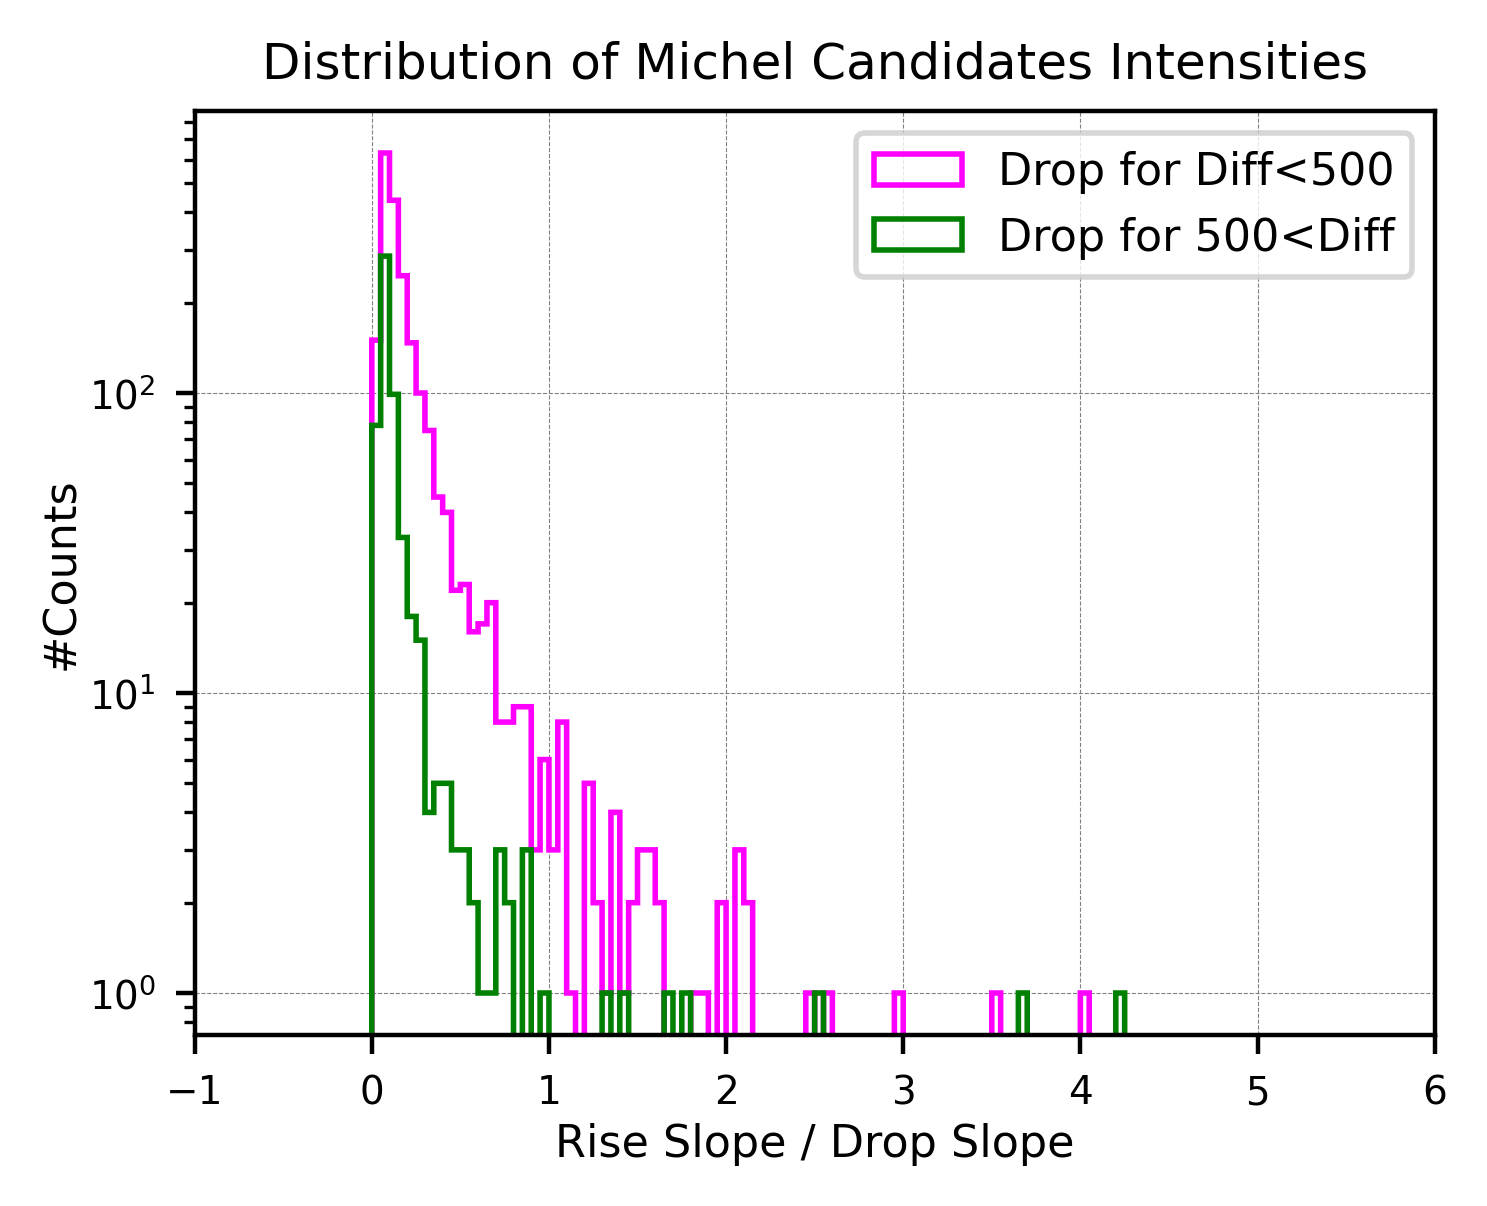

In [20]:

rise_diff0_purity1 = [ev.michel_rise for ev in events_diff0_purify1]
drop_diff0_purity1 = [ev.michel_drop for ev in events_diff0_purify1]

ratios_diff0_purity1 = [
    r / d if d not in (0, None) else None
    for r, d in zip(rise_diff0_purity1, drop_diff0_purity1)
]


rise_diff500_purity1 = [ev.michel_rise for ev in events_diff500_purify1]
drop_diff500_purity1 = [ev.michel_drop for ev in events_diff500_purify1]

ratios_diff500_purity1 = [
    r / d if d not in (0, None) else None
    for r, d in zip(rise_diff500_purity1, drop_diff500_purity1)
]



# ==========================================================
# Michel Rise VS Michel Drop
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(drop_diff500_purity1), np.array(rise_diff500_purity1)
x2, y2 = np.array(drop_diff0_purity1), np.array(rise_diff0_purity1)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Density for group 2 (blue, 0<Diff<500) ---
xy2 = np.vstack([x2, y2])
z2 = gaussian_kde(xy2)(xy2)
idx2 = z2.argsort()
x2, y2, z2 = x2[idx2], y2[idx2], z2[idx2]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x2, y2, s=0.8, color="red", alpha=0.5, label="_nolegend_")
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x2, y2, c=z2, s=0.8, cmap="Reds", alpha=0.8, edgecolors="none", label="Diff<500")
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="500<Diff")


#---------------------------------

#plt.plot([0, 500], [0, 40], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([0, 1000], [0, 500], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
#plt.xlim(0, 400)
#plt.ylim(0, 60)
plt.xlabel('Michel peak drop slope', labelpad=1, fontsize=7)
plt.ylabel('Michel peak rise slope', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="500<Diff")
blue_patch = mpatches.Patch(color="red", label="Diff<500")
plt.legend(handles=[red_patch, blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()





#Michel Rise & Drop Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

#plt.hist(rise_diff0_purity1, bins=bins, range=(range_min, range_max), edgecolor='red', 
#         histtype='step', linewidth=1.0, label="Rise for Diff<500")
#plt.hist(rise_diff500_purity1, bins=bins, range=(range_min, range_max), edgecolor='blue', 
#         histtype='step', linewidth=1.0, label="Rise for 500<Diff")
plt.hist(drop_diff0_purity1, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=1.0, label="Drop for Diff<500")
plt.hist(drop_diff500_purity1, bins=bins, range=(range_min, range_max), edgecolor='green', 
         histtype='step', linewidth=1.0, label="Drop for 500<Diff")
#plt.hist(ratios_diff0_purity1, bins=bins, range=(range_min, range_max), edgecolor='red', 
#         histtype='step', linewidth=1.0, label="Rise/Drop for Diff<500")
#plt.hist(ratios_diff500_purity1, bins=bins, range=(range_min, range_max), edgecolor='blue', 
#         histtype='step', linewidth=1.0, label="Rise/Drop for 500<Diff")


plt.xlim(-1, 6)
plt.xlabel('Rise Slope / Drop Slope', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.9, 1000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Michel Candidates Intensities', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  

